https://github.com/aashutosh-raut/Carprediction

In [193]:
import mlflow

mlflow.set_tracking_uri("http://localhost:9000") 
mlflow.set_experiment(experiment_name="experimentdoing74")

<Experiment: artifact_location='mlflow-artifacts:/787377846228956947', creation_time=1757759638111, experiment_id='787377846228956947', last_update_time=1757759638111, lifecycle_stage='active', name='experimentdoing74', tags={}>

In [194]:
import numpy as np #importing the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


In [195]:
import pickle
import warnings
warnings.filterwarnings('ignore')

In [196]:
import matplotlib
np.__version__, pd.__version__, sns.__version__, matplotlib.__version__

('2.1.3', '2.2.3', '0.13.2', '3.10.0')

In [197]:
df = pd.read_csv('Cars.csv') #importing/loading the data set

In [198]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [199]:
df.shape # Checking the number of data and columns

(8128, 13)

In [200]:
df.describe() # here we describe the data, see what the rows and columns have

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [201]:
df.info

<bound method DataFrame.info of                               name  year  selling_price  km_driven    fuel  \
0           Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1     Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2         Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3        Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4           Maruti Swift VXI BSIII  2007         130000     120000  Petrol   
...                            ...   ...            ...        ...     ...   
8123             Hyundai i20 Magna  2013         320000     110000  Petrol   
8124         Hyundai Verna CRDi SX  2007         135000     119000  Diesel   
8125        Maruti Swift Dzire ZDi  2009         382000     120000  Diesel   
8126               Tata Indigo CR4  2013         290000      25000  Diesel   
8127               Tata Indigo CR4  2013         290000      25000  Diesel   

     seller_type transmission  

In [202]:
df.columns # here we see what are the columns (features we will later take to train test the model. some of them we will use some we will drop.) now we will rename the columns below. 

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [203]:
df.rename(columns = {'name': 'brand', 'year': 'year', 'selling_price': 'selling_price', 'km_driven': 'km_driven', 'fuel': 'fuel', 'seller_type': 'seller_type', 'transmission': 'transmission', 'owner': 'owner', 'mileage': 'milage',  'engine': 'engine', 'max_power': 'max_power', 'torque': 'torque', 'seats': 'seats'}, inplace = True)
# The above is the renaming process of the Exploratory (EDA)

In [204]:
df.columns # checking the updated columns names

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'milage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [205]:
df['owner'].unique() # checking the data in the owner column

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [206]:
df['owner'] = df['owner'].replace({
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}) # changing the string into numeric values

In [207]:
df['owner'].unique() # checking the updated data 

array([1, 2, 3, 4, 5])

In [208]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,1,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,2,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,3,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,1,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,1,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,1,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,4,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,1,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,1,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [209]:
df['fuel'].unique() # checking the data in the fuel column 

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [210]:
df = df[df['fuel'] != 'LPG']
df['fuel'] #droping LPG from the data

0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8090, dtype: object

In [211]:
df['fuel'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [212]:
df = df[df['fuel'] != 'CNG']
df['fuel'] #dropping CNG from the data

0       Diesel
1       Diesel
2       Petrol
3       Diesel
4       Petrol
         ...  
8123    Petrol
8124    Diesel
8125    Diesel
8126    Diesel
8127    Diesel
Name: fuel, Length: 8033, dtype: object

In [213]:
df['fuel'].unique() # checking if LPG and CNG have been dropped from the data

array(['Diesel', 'Petrol'], dtype=object)

In [214]:
df['milage'].unique()

array(['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl',
       '20.14 kmpl', '23.59 kmpl', '20.0 kmpl', '19.01 kmpl', '17.3 kmpl',
       '19.3 kmpl', nan, '18.9 kmpl', '18.15 kmpl', '24.52 kmpl',
       '19.7 kmpl', '22.54 kmpl', '21.0 kmpl', '25.5 kmpl', '26.59 kmpl',
       '21.5 kmpl', '20.3 kmpl', '21.4 kmpl', '24.7 kmpl', '18.2 kmpl',
       '16.8 kmpl', '24.3 kmpl', '14.0 kmpl', '18.6 kmpl', '23.95 kmpl',
       '17.0 kmpl', '20.63 kmpl', '13.93 kmpl', '16.0 kmpl', '17.8 kmpl',
       '18.5 kmpl', '12.55 kmpl', '12.99 kmpl', '14.8 kmpl', '13.5 kmpl',
       '26.0 kmpl', '20.65 kmpl', '27.3 kmpl', '11.36 kmpl', '17.68 kmpl',
       '14.28 kmpl', '18.53 kmpl', '14.84 kmpl', '21.12 kmpl',
       '20.36 kmpl', '21.27 kmpl', '18.16 kmpl', '22.0 kmpl', '25.1 kmpl',
       '20.51 kmpl', '21.66 kmpl', '25.2 kmpl', '22.9 kmpl', '16.02 kmpl',
       '20.54 kmpl', '22.77 kmpl', '15.71 kmpl', '23.1 kmpl',
       '19.02 kmpl', '19.81 kmpl', '16.47 kmpl', '15.04 kmpl',
      

In [215]:
df['milage'] = df['milage'].str.split(' ').str[0]
df['milage']

0        23.4
1       21.14
2        17.7
3        23.0
4        16.1
        ...  
8123     18.5
8124     16.8
8125     19.3
8126    23.57
8127    23.57
Name: milage, Length: 8033, dtype: object

In [216]:
df['milage'].dtype

dtype('O')

In [217]:
df['milage'] = df['milage'].astype(float)
df['milage'].dtype

dtype('float64')

In [218]:
df['engine'].unique()

array(['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC',
       '796 CC', '1364 CC', '1399 CC', '1461 CC', '993 CC', nan,
       '1061 CC', '1198 CC', '1199 CC', '998 CC', '1591 CC', '2179 CC',
       '1368 CC', '2982 CC', '2494 CC', '2143 CC', '2477 CC', '1462 CC',
       '2755 CC', '1968 CC', '1798 CC', '1196 CC', '1373 CC', '1598 CC',
       '1998 CC', '1086 CC', '1194 CC', '1172 CC', '1405 CC', '1582 CC',
       '999 CC', '2487 CC', '1999 CC', '3604 CC', '2987 CC', '1995 CC',
       '1451 CC', '1969 CC', '2967 CC', '2497 CC', '1797 CC', '1991 CC',
       '2362 CC', '1493 CC', '1599 CC', '1341 CC', '1794 CC', '799 CC',
       '1193 CC', '2696 CC', '1495 CC', '1186 CC', '1047 CC', '2498 CC',
       '2956 CC', '2523 CC', '1120 CC', '624 CC', '1496 CC', '1984 CC',
       '2354 CC', '814 CC', '793 CC', '1799 CC', '936 CC', '1956 CC',
       '1997 CC', '1499 CC', '1948 CC', '2997 CC', '2489 CC', '2499 CC',
       '2609 CC', '2953 CC', '1150 CC', '1994 CC', '1388 CC', '152

In [219]:
df['engine'] = df['engine'].str.split(' ').str[0]
df['engine']

0       1248
1       1498
2       1497
3       1396
4       1298
        ... 
8123    1197
8124    1493
8125    1248
8126    1396
8127    1396
Name: engine, Length: 8033, dtype: object

In [220]:
df['engine'] = df['engine'].astype(float)
df['engine'].dtype

dtype('float64')

In [221]:
df['max_power']

0           74 bhp
1       103.52 bhp
2           78 bhp
3           90 bhp
4         88.2 bhp
           ...    
8123     82.85 bhp
8124       110 bhp
8125      73.9 bhp
8126        70 bhp
8127        70 bhp
Name: max_power, Length: 8033, dtype: object

In [222]:
df['max_power'] = df['max_power'].str.split(' ').str[0]
df['max_power']

0           74
1       103.52
2           78
3           90
4         88.2
         ...  
8123     82.85
8124       110
8125      73.9
8126        70
8127        70
Name: max_power, Length: 8033, dtype: object

In [223]:
df['max_power'] = df['max_power'].astype(float)
df['max_power'].dtype

dtype('float64')

In [224]:
df['brand']

0             Maruti Swift Dzire VDI
1       Skoda Rapid 1.5 TDI Ambition
2           Honda City 2017-2020 EXi
3          Hyundai i20 Sportz Diesel
4             Maruti Swift VXI BSIII
                    ...             
8123               Hyundai i20 Magna
8124           Hyundai Verna CRDi SX
8125          Maruti Swift Dzire ZDi
8126                 Tata Indigo CR4
8127                 Tata Indigo CR4
Name: brand, Length: 8033, dtype: object

In [225]:
df['brand'] = df['brand'].str.split(' ').str[0]
df['brand']

0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8123    Hyundai
8124    Hyundai
8125     Maruti
8126       Tata
8127       Tata
Name: brand, Length: 8033, dtype: object

In [226]:
df.drop(columns={'torque'}, inplace=True) #Dropping torque 

In [227]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0
8125,Maruti,2009,382000,120000,Diesel,Individual,Manual,1,19.30,1248.0,73.90,5.0
8126,Tata,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0


In [228]:
df['owner'].unique()

array([1, 2, 3, 4, 5])

In [229]:
df['owner'].dtype

dtype('int64')

In [230]:
df = df[df['owner'] !=5] # Removing test drive cars
df['owner'].unique()

array([1, 2, 3, 4])

In [231]:
df['selling_price']

0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8123    320000
8124    135000
8125    382000
8126    290000
8127    290000
Name: selling_price, Length: 8028, dtype: int64

In [232]:
y = np.log(df['selling_price']) #Transforming y ie selling price using log

y

0       13.017003
1       12.821258
2       11.970350
3       12.323856
4       11.775290
          ...    
8123    12.676076
8124    11.813030
8125    12.853176
8126    12.577636
8127    12.577636
Name: selling_price, Length: 8028, dtype: float64

In [233]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


<Axes: xlabel='owner', ylabel='count'>

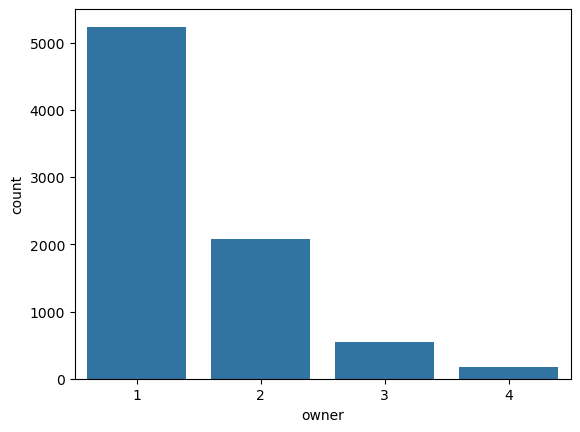

In [234]:
sns.countplot(data = df, x = 'owner') # Univariate analysis. Countplot.

<Axes: xlabel='fuel', ylabel='count'>

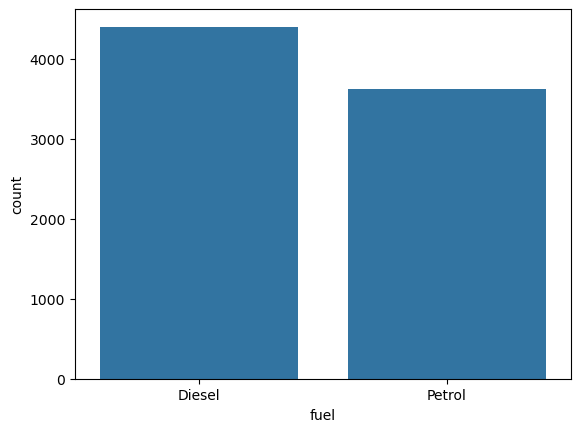

In [235]:
sns.countplot(data = df, x = 'fuel')

<Axes: xlabel='transmission', ylabel='count'>

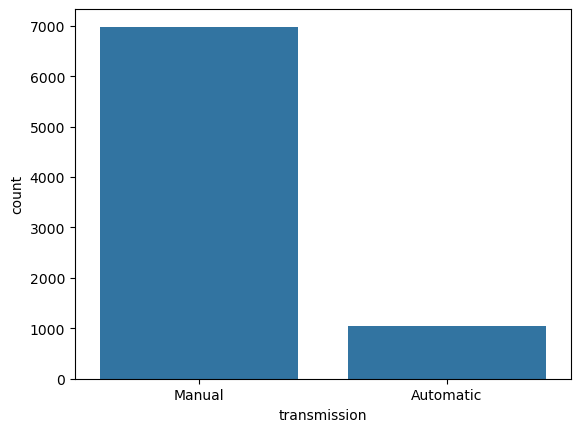

In [236]:
sns.countplot(data = df, x = 'transmission')

<Axes: xlabel='seats', ylabel='count'>

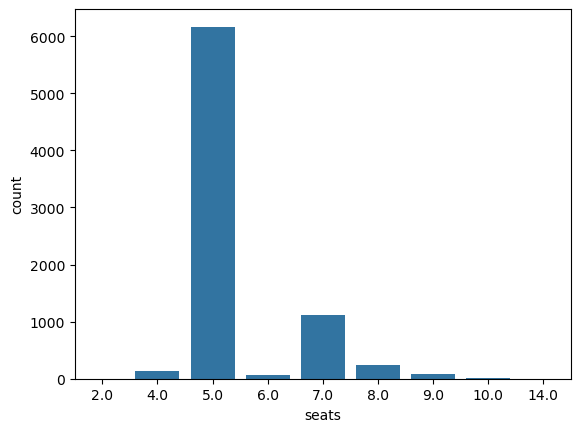

In [237]:
sns.countplot(data = df, x = 'seats')

Text(0.5, 0, 'engine')

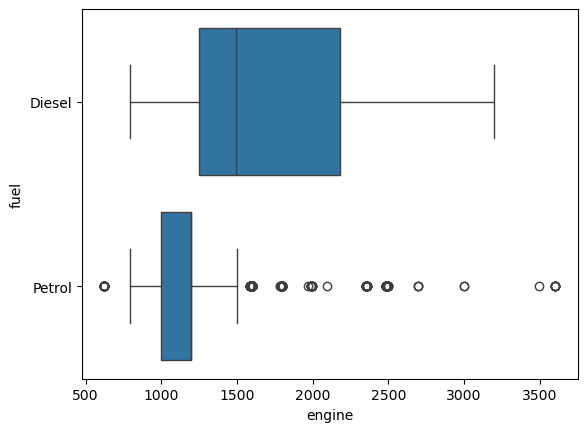

In [238]:
sns.boxplot(x = df["engine"], y = df["fuel"]); #Boxplot
plt.ylabel("fuel")
plt.xlabel("engine")

<Axes: xlabel='milage', ylabel='engine'>

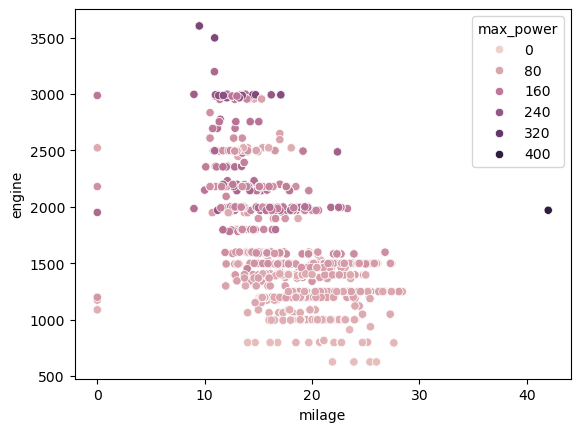

In [239]:

sns.scatterplot(x = df['milage'], y = df['engine'], hue=df['max_power']) #scatterplot

<Axes: xlabel='milage', ylabel='year'>

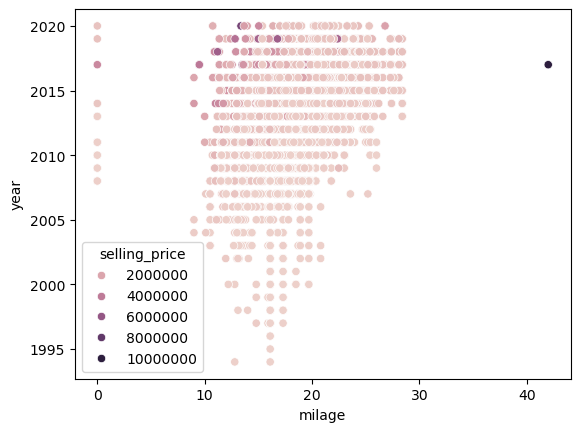

In [240]:

sns.scatterplot(x = df['milage'], y = df['year'], hue=df['selling_price'])

In [241]:
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,milage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0
8124,Hyundai,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0
8125,Maruti,2009,382000,120000,Diesel,Individual,Manual,1,19.30,1248.0,73.90,5.0
8126,Tata,2013,290000,25000,Diesel,Individual,Manual,1,23.57,1396.0,70.00,5.0


In [242]:
print(df['fuel'].unique())
print(df['brand'].unique())
print(df['transmission'].unique())



['Diesel' 'Petrol']
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']
['Manual' 'Automatic']


In [243]:
df.dtypes #checking datatypes

brand             object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner              int64
milage           float64
engine           float64
max_power        float64
seats            float64
dtype: object

In [244]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["fuel"] = le.fit_transform(df["fuel"])

df["fuel"].unique()
 # 0 = diesel and 1 = petrol 
 # transforming object 

array([0, 1])

In [245]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["seller_type"] = le.fit_transform(df["seller_type"])

df["seller_type"].unique() #using fit transform to change object into 1, 0, 2 ie the individual, dealer and trademark dealer

array([1, 0, 2])

In [246]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["transmission"] = le.fit_transform(df["transmission"])

df["transmission"].unique() 

array([1, 0])

In [247]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["brand"] = le.fit_transform(df["brand"])

df["brand"].unique() #assigning brand names of cars with numeric values

array([20, 27, 10, 11, 29,  9, 26, 19, 28,  4,  7,  6, 14, 21, 22,  2, 30,
        3, 23, 17, 13, 16, 18, 31,  5, 15,  8,  0,  1, 12, 24, 25])

<Axes: >

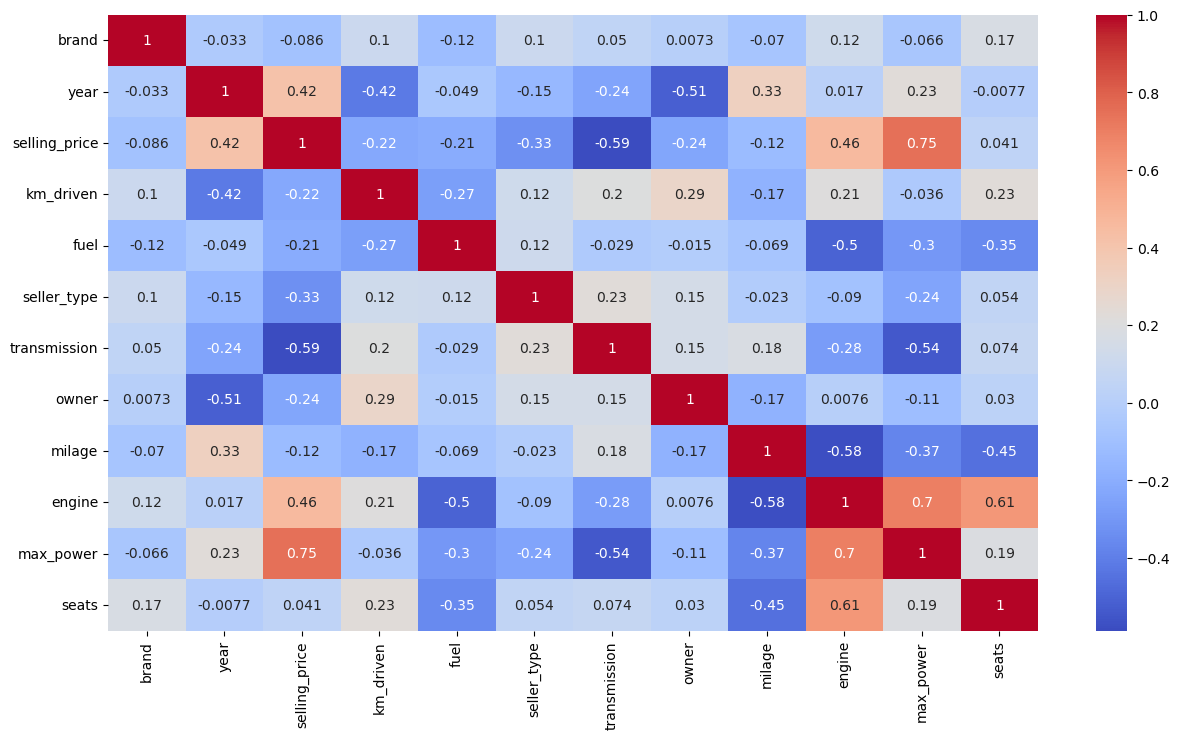

In [248]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm") # plotting the corelation matrix 

In [249]:
df = df.drop(columns=['year', 'transmission', 'owner'])
df # dropping the columns year, transmission and owners

,brand,selling_price,km_driven,fuel,seller_type,milage,engine,max_power,seats
0,20,450000,145500,0,1,23.40,1248.0,74.00,5.0
1,27,370000,120000,0,1,21.14,1498.0,103.52,5.0
2,10,158000,140000,1,1,17.70,1497.0,78.00,5.0
3,11,225000,127000,0,1,23.00,1396.0,90.00,5.0
4,20,130000,120000,1,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...
8123,11,320000,110000,1,1,18.50,1197.0,82.85,5.0
8124,11,135000,119000,0,1,16.80,1493.0,110.00,5.0
8125,20,382000,120000,0,1,19.30,1248.0,73.90,5.0
8126,28,290000,25000,0,1,23.57,1396.0,70.00,5.0


<Axes: >

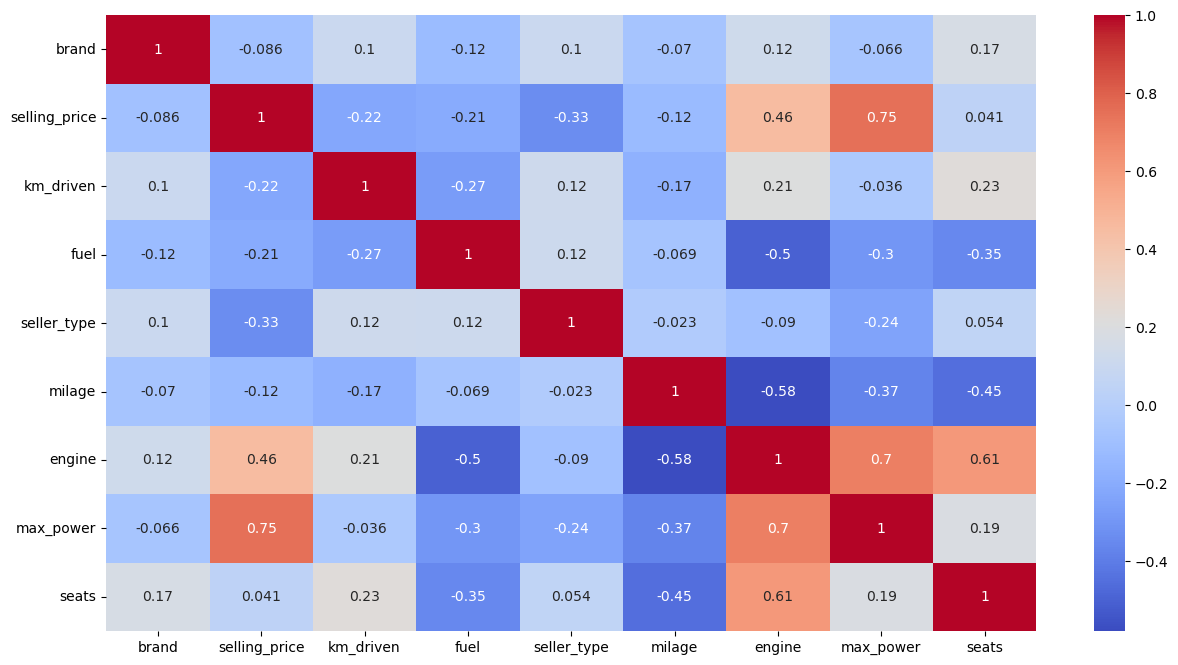

In [250]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm") # corelation matrix of the features we will take for the model (x and y )

In [251]:
X = df[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']]
y = df['selling_price'] #feature engineering the data x are the features we use to get the y where y is the selling price of cars

In [252]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42) # Splitting the data into train set and test set

In [253]:
X_train[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # finding the null values in x

brand            0
km_driven        0
fuel             0
seller_type      0
milage         154
engine         154
max_power      149
seats          154
dtype: int64

In [254]:
y_train.isna().sum() #finding the null values in y

np.int64(0)

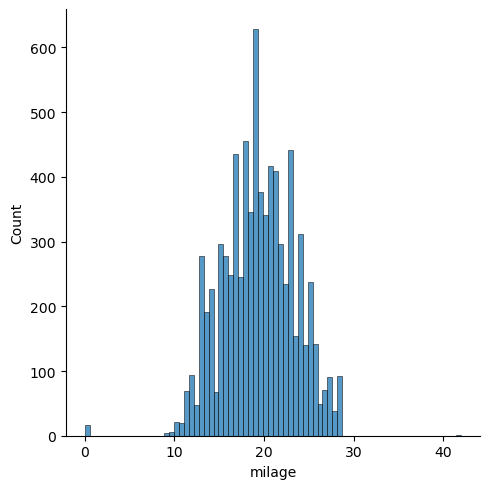

In [255]:
sns.displot(data=df, x='milage') # plotting the data

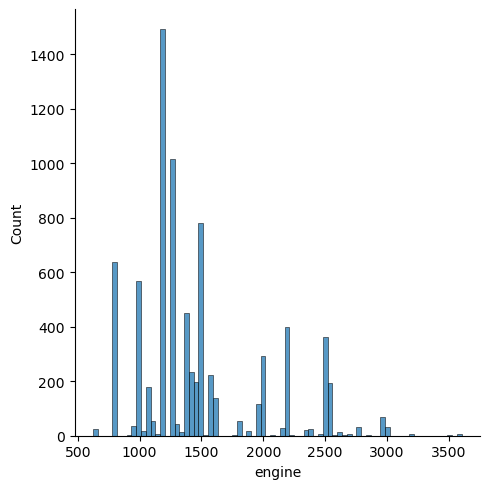

In [256]:
sns.displot(data=df, x='engine')

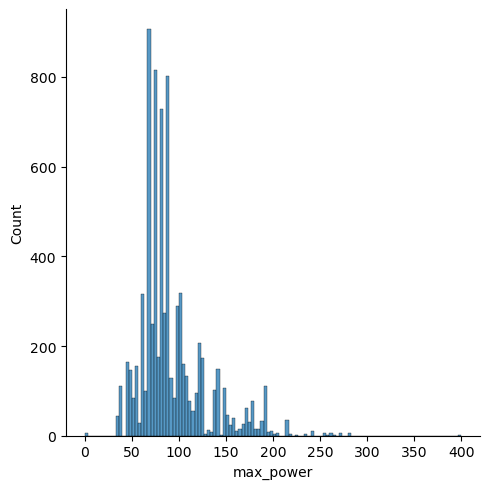

In [257]:
sns.displot(data=df, x='max_power')

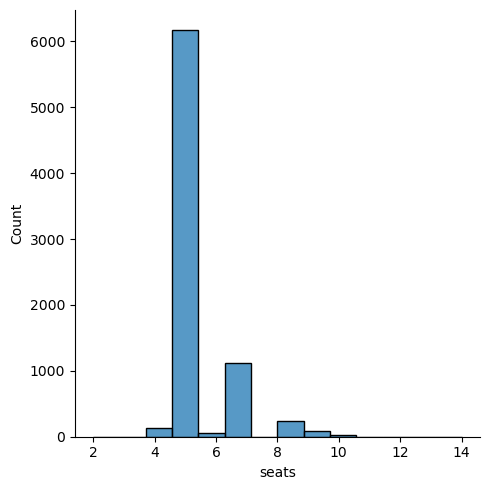

In [258]:
sns.displot(data=df, x='seats')

In [259]:
X_train['milage'].fillna(X_train['milage'].median(), inplace=True)
X_train['engine'].fillna(X_train['engine'].median(), inplace=True)
X_train['seats'].fillna(X_train['seats'].median(), inplace=True)
X_train['max_power'].fillna(X_train['max_power'].median(), inplace=True) # filling the null data in the x of the trainset with the median

In [260]:
X_train['seats'].isna().sum()

np.int64(0)

In [261]:
X_train[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # checking if the x train dataset has any null values. it does not. the values have been imputed.

brand          0
km_driven      0
fuel           0
seller_type    0
milage         0
engine         0
max_power      0
seats          0
dtype: int64

In [262]:
X_test['milage'].fillna(X_test['milage'].median(), inplace=True)
X_test['engine'].fillna(X_test['engine'].median(), inplace=True)
X_test['seats'].fillna(X_test['seats'].median(), inplace=True)
X_test['max_power'].fillna(X_test['max_power'].median(), inplace=True) 

# filling data in test set

In [263]:
X_test[['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']].isna().sum() # checking if the test set has null values.

brand          0
km_driven      0
fuel           0
seller_type    0
milage         0
engine         0
max_power      0
seats          0
dtype: int64

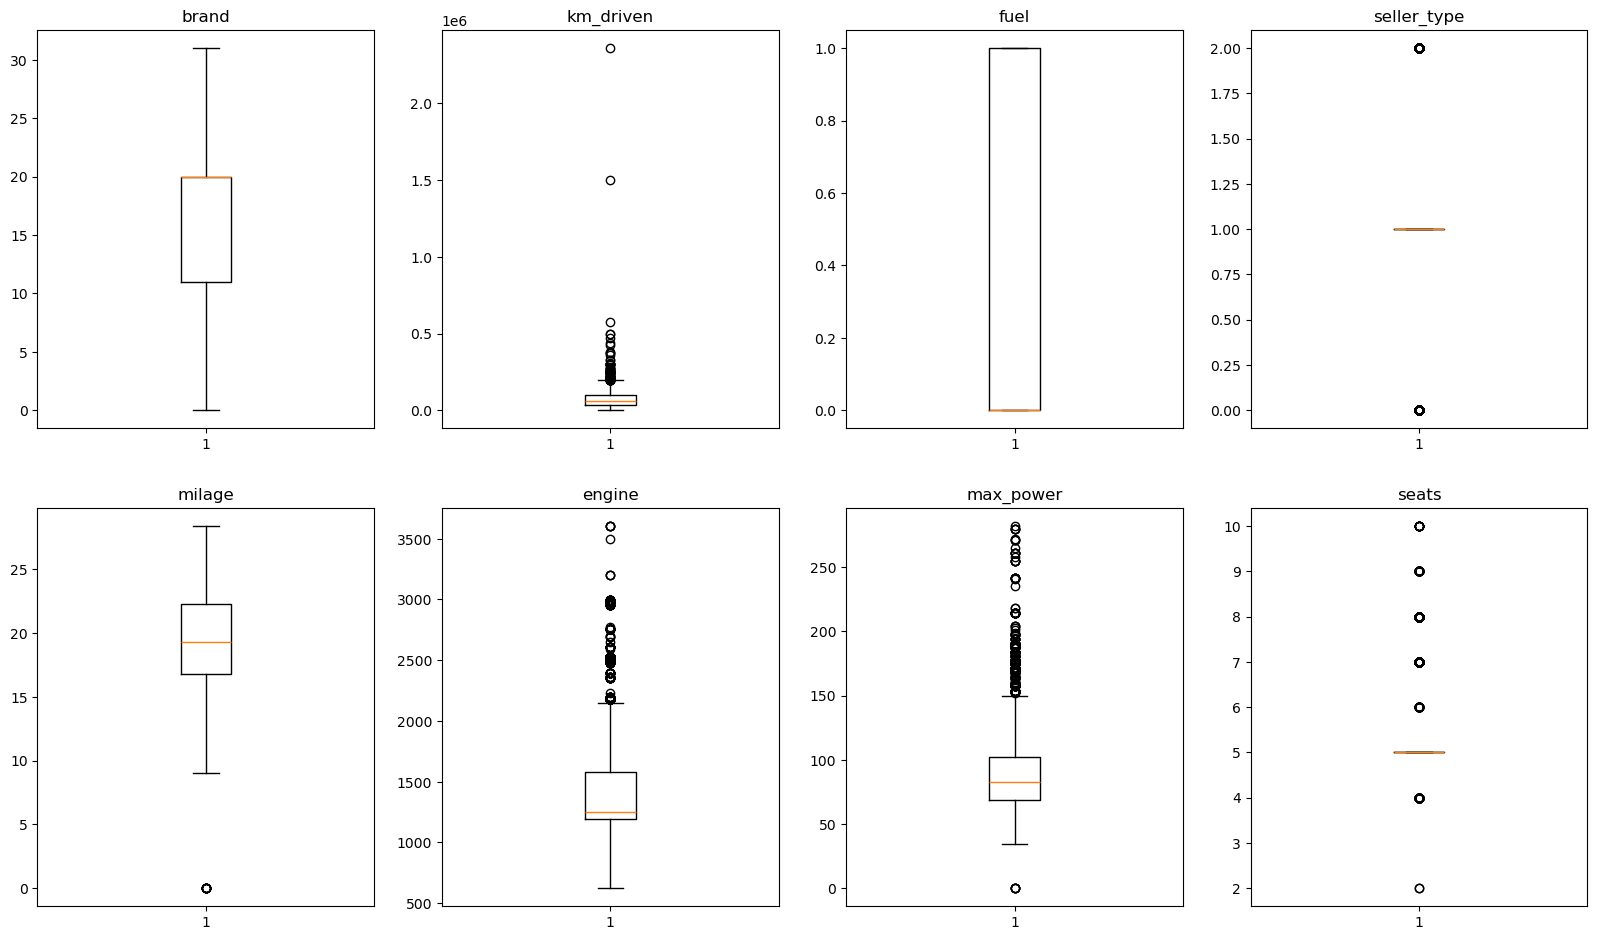

In [264]:
col_dict = {'brand':1,'km_driven':2, 'fuel':3, 'seller_type':4, 'milage':5, 'engine':6, 'max_power':7, 'seats':8}

# Detect outliers in each variable using box plots.
plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(X_train[variable])
                     plt.title(variable)

plt.show()

In [265]:
def outlier_count(col, data = X_train):
    
    # calculating the 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate the inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # counting the number of outliers, which are the data that are less than min_val or more than max_val which was calculated above.
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculating the percentage of the outliers.
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [266]:
for col in X_train.columns: #lets check the percentage of outliers in each columns.
    outlier_count(col)


---------------km_driven---------------

Number of outliers: 102
Percent of data that is outlier: 1.82%

---------------seller_type---------------

Number of outliers: 944
Percent of data that is outlier: 16.8%

---------------milage---------------

Number of outliers: 14
Percent of data that is outlier: 0.25%

---------------engine---------------

Number of outliers: 836
Percent of data that is outlier: 14.88%

---------------max_power---------------

Number of outliers: 409
Percent of data that is outlier: 7.28%

---------------seats---------------

Number of outliers: 1158
Percent of data that is outlier: 20.61%


In [267]:
# from sklearn.preprocessing import StandardScaler

# # feature scaling the data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

In [268]:
from sklearn.preprocessing import MinMaxScaler

# Scale X
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Scale y
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train.to_numpy().reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test.to_numpy().reshape(-1,1)).flatten()

In [269]:
print("Shape of x_train: ", X_train.shape) #printing after scaling
print("Shape of x_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (5619, 8)
Shape of x_test:  (2409, 8)
Shape of y_train:  (5619,)
Shape of y_test:  (2409,)


In [270]:
# from sklearn.linear_model import LinearRegression  #calculating the MSE and r2 using the linear regression model
# from sklearn.metrics import mean_squared_error, r2_score

# lr = LinearRegression()
# lr.fit(x_train, y_train)
# yhat = lr.predict(x_test)

# print("MSE: ", mean_squared_error(y_test, yhat))
# print("r2: ", r2_score(y_test, yhat))

In [271]:
#!pip install mlflow

In [272]:
# import numpy as np
# from sklearn.model_selection import KFold
# import matplotlib.pyplot as plt

# class LinearRegression:
    
#     # Default K-Fold Cross Validation
#     kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#     def __init__(self, regularization=None, lr=0.001, method='batch', num_epochs=500, 
#                  bs=50, cv=kfold, init="zero", momentum=0.0, feature_names=None):
#         """
#         Custom Linear Regression constructor.

#         Parameters:
#         - regularization: Regularization object (Lasso, Ridge, or ElasticNet)
#         - lr: Learning rate
#         - method: 'batch', 'mini', or 'stochastic'
#         - num_epochs: Number of training epochs
#         - bs: Batch size (for mini-batch)
#         - cv: Cross-validation strategy
#         - init: 'zero' or 'xavier' weight initialization
#         - momentum: momentum factor (0 = no momentum)
#         - feature_names: optional, names of features for plotting importance
#         """
#         self.lr = lr
#         self.num_epochs = num_epochs
#         self.bs = bs
#         self.method = method
#         self.cv = cv
#         self.regularization = regularization
#         self.init = init
#         self.momentum = momentum
#         self.feature_names = feature_names

#     # --------------------
#     # Mean Squared Error
#     # --------------------
#     def mse(self, y_true, y_pred):
#         return np.mean((y_pred - y_true) ** 2)

#     # --------------------
#     # R2 Score
#     # --------------------
#     def r2_score(self, y_true, y_pred):
#         ss_res = np.sum((y_true - y_pred) ** 2)
#         ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#         return 1 - (ss_res / ss_tot)

#     # --------------------
#     # Xavier Initialization
#     # --------------------
#     def _initialize_theta(self, n_features):
#         if self.init == "zero":
#             return np.zeros(n_features)
#         elif self.init == "xavier":
#             limit = 1 / np.sqrt(n_features)
#             return np.random.uniform(-limit, limit, n_features)
#         else:
#             raise ValueError("init must be 'zero' or 'xavier'")

#     # --------------------
#     # Add bias column
#     # --------------------
#     def _add_bias_column(self, X):
#         return np.c_[np.ones((X.shape[0], 1)), X]

#     # --------------------
#     # Training Function
#     # --------------------
    
    
#     def fit(self, X_train, y_train):
#         self.kfold_scores = []
#         self.kfold_r2_scores = []

#         X_train = self._add_bias_column(X_train)

        
#         for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
#             X_cross_train = X_train[train_idx]
#             X_cross_val   = X_train[val_idx]

#              # Handle pandas Series vs numpy arrays
#             if hasattr(y_train, "iloc"):  # pandas Series
#                y_cross_train = y_train.iloc[train_idx]
#                y_cross_val   = y_train.iloc[val_idx]
#             else:  # numpy array
#                y_cross_train = y_train[train_idx]
#                y_cross_val   = y_train[val_idx]

#         # for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
#         #     X_cross_train, y_cross_train = X_train[train_idx], y_train[train_idx]
#         #     X_cross_val, y_cross_val = X_train[val_idx], y_train[val_idx]

#             # Initialize weights
#             self.theta = self._initialize_theta(X_cross_train.shape[1])
#             velocity = np.zeros_like(self.theta)  # for momentum

#             # Training loop
#             for epoch in range(self.num_epochs):
#                 if self.method == "batch":
#                     X_batch, y_batch = X_cross_train, y_cross_train
#                 elif self.method == "stochastic":
#                     rand_idx = np.random.randint(len(X_cross_train))
#                     X_batch, y_batch = X_cross_train[rand_idx:rand_idx+1], y_cross_train[rand_idx:rand_idx+1]
#                 elif self.method == "mini":
#                     indices = np.random.randint(len(X_cross_train), size=self.bs)
#                     X_batch, y_batch = X_cross_train[indices], y_cross_train[indices]
#                 else:
#                     raise ValueError("method must be 'batch', 'mini', or 'stochastic'")
        
#                 # Prediction and gradient
#                 y_pred = X_batch.dot(self.theta)
#                 error = y_pred - y_batch
#                 grad = X_batch.T.dot(error) / len(y_batch)

#                 # Add regularization gradient
#                 if self.regularization:
#                     grad += self.regularization.derivation(self.theta)

#                 # Momentum update
#                 velocity = self.momentum * velocity - self.lr * grad
#                 self.theta += velocity

#             # Validation
#             y_val_pred = X_cross_val.dot(self.theta)
#             mse = self.mse(y_cross_val, y_val_pred)
#             r2 = self.r2_score(y_cross_val, y_val_pred)

#             self.kfold_scores.append(mse)
#             self.kfold_r2_scores.append(r2)

#         return self

#     # --------------------
#     # Prediction
#     # --------------------
#     def predict(self, X):
#         X = self._add_bias_column(X)
#         return X.dot(self.theta)

#     # --------------------
#     # Feature Importance Plot
#     # --------------------
#     def plot_feature_importance(self):
#         if self.theta is None:
#             raise ValueError("Model has not been trained yet.")

#         # Exclude bias term
#         coeffs = self.theta[1:]
#         features = self.feature_names if self.feature_names is not None else [f"X{i}" for i in range(len(coeffs))]

#         plt.figure(figsize=(10,5))
#         plt.bar(features, coeffs)
#         plt.xticks(rotation=45)
#         plt.title("Feature Importance (Coefficient Magnitudes)")
#         plt.xlabel("Features")
#         plt.ylabel("Coefficient Value")
#         plt.show()


# # # --------------------
# # # Regularization classes
# # # --------------------
# # class Lasso:
# #     def __init__(self, l): self.l = l
# #     def __call__(self, theta): return self.l * np.sum(np.abs(theta))
# #     def derivation(self, theta): return self.l * np.sign(theta)

# # class Ridge:
# #     def __init__(self, l): self.l = l
# #     def __call__(self, theta): return self.l * np.sum(np.square(theta))
# #     def derivation(self, theta): return 2 * self.l * theta

# # class Elastic:
# #     def __init__(self, l, l_ratio): 
# #         self.l = l; self.l_ratio = l_ratio
# #     def __call__(self, theta):
# #         l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
# #         l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta)) 
# #         return l1 + l2
# #     def derivation(self, theta):
# #         l1 = self.l * self.l_ratio * np.sign(theta)
# #         l2 = 2 * self.l * (1 - self.l_ratio) * theta
# #         return l1 + l2

# # # --------------------
# # # Inherited models
# # # --------------------
# # class LassoRegression(LinearRegression):
# #     def __init__(self, method, lr, l, **kwargs):
# #         self.regularization = Lasso(l)
# #         super().__init__(self.regularization, lr, method, **kwargs)

# # class RidgeRegression(LinearRegression):
# #     def __init__(self, method, lr, l, **kwargs):
# #         self.regularization = Ridge(l)
# #         super().__init__(self.regularization, lr, method, **kwargs)

# # class ElasticRegression(LinearRegression):
# #     def __init__(self, method, lr, l, l_ratio=0.5, **kwargs):
# #         self.regularization = Elastic(l, l_ratio)
# #         super().__init__(self.regularization, lr, method, **kwargs)


In [273]:
# import numpy as np
# from sklearn.model_selection import KFold
# import matplotlib.pyplot as plt

# class LinearRegression:
    
#     # Default K-Fold Cross Validation
#     kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#     def __init__(self, regularization=None, lr=0.001, method='batch', num_epochs=500, 
#                  bs=50, cv=kfold, init="zero", momentum=0.0, feature_names=None):
#         """
#         Custom Linear Regression constructor.

#         Parameters:
#         - regularization: Regularization object (Lasso, Ridge, or ElasticNet)
#         - lr: Learning rate
#         - method: 'batch', 'mini', or 'stochastic'
#         - num_epochs: Number of training epochs
#         - bs: Batch size (for mini-batch)
#         - cv: Cross-validation strategy
#         - init: 'zero' or 'xavier' weight initialization
#         - momentum: momentum factor (0 = no momentum)
#         - feature_names: optional, names of features for plotting importance
#         """
#         self.lr = lr
#         self.num_epochs = num_epochs
#         self.bs = bs
#         self.method = method
#         self.cv = cv
#         self.regularization = regularization
#         self.init = init
#         self.momentum = momentum
#         self.feature_names = feature_names

#     # --------------------
#     # Mean Squared Error
#     # --------------------
#     def mse(self, y_true, y_pred):
#         return np.mean((y_pred - y_true) ** 2)

#     # --------------------
#     # R2 Score
#     # --------------------
#     def r2_score(self, y_true, y_pred):
#         ss_res = np.sum((y_true - y_pred) ** 2)
#         ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#         return 1 - (ss_res / ss_tot)

#     # --------------------
#     # Xavier Initialization
#     # --------------------
#     def _initialize_theta(self, n_features):
#         if self.init == "zero":
#             return np.zeros(n_features)
#         elif self.init == "xavier":
#             limit = 1 / np.sqrt(n_features)
#             return np.random.uniform(-limit, limit, n_features)
#         else:
#             raise ValueError("init must be 'zero' or 'xavier'")

#     # --------------------
#     # Add bias column
#     # --------------------
#     def _add_bias_column(self, X):
#         return np.c_[np.ones((X.shape[0], 1)), X]

#     # --------------------
#     # Training Function
#     # --------------------
#     def fit(self, X_train, y_train):
#         self.kfold_scores = []
#         self.kfold_r2_scores = []

#         X_train = self._add_bias_column(X_train)

#         for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
#             X_cross_train = X_train[train_idx]
#             X_cross_val = X_train[val_idx]

#             # Handle pandas Series vs numpy arrays
#             if hasattr(y_train, "iloc"):  # pandas Series
#                 y_cross_train = y_train.iloc[train_idx]
#                 y_cross_val = y_train.iloc[val_idx]
#             else:  # numpy array
#                 y_cross_train = y_train[train_idx]
#                 y_cross_val = y_train[val_idx]

#             # Initialize weights for this fold
#             self.theta = self._initialize_theta(X_cross_train.shape[1])
#             velocity = np.zeros_like(self.theta)  # for momentum

#             # Training loop for this fold
#             for epoch in range(self.num_epochs):
#                 if self.method == "batch":
#                     X_batch, y_batch = X_cross_train, y_cross_train
#                 elif self.method == "stochastic":
#                     rand_idx = np.random.randint(len(X_cross_train))
#                     X_batch, y_batch = X_cross_train[rand_idx:rand_idx+1], y_cross_train[rand_idx:rand_idx+1]
#                 elif self.method == "mini":
#                     indices = np.random.randint(len(X_cross_train), size=self.bs)
#                     X_batch, y_batch = X_cross_train[indices], y_cross_train[indices]
#                 else:
#                     raise ValueError("method must be 'batch', 'mini', or 'stochastic'")

#                 # Prediction and gradient
#                 y_pred = X_batch.dot(self.theta)
#                 error = y_pred - y_batch
#                 grad = X_batch.T.dot(error) / len(y_batch)

#                 # Add regularization gradient
#                 if self.regularization:
#                     grad += self.regularization.derivation(self.theta)

#                 # Momentum update
#                 velocity = self.momentum * velocity - self.lr * grad
#                 self.theta += velocity

#             # Validation on this fold
#             y_val_pred = X_cross_val.dot(self.theta)
#             mse = self.mse(y_cross_val, y_val_pred)
#             r2 = self.r2_score(y_cross_val, y_val_pred)

#             self.kfold_scores.append(mse)
#             self.kfold_r2_scores.append(r2)

#         return self  # <-- This was incorrectly indented before!

#     # --------------------
#     # Prediction
#     # --------------------
#     def predict(self, X):
#         X = self._add_bias_column(X)
#         return X.dot(self.theta)

#     # --------------------
#     # Feature Importance Plot
#     # --------------------
#     def plot_feature_importance(self):
#         if self.theta is None:
#             raise ValueError("Model has not been trained yet.")

#         # Exclude bias term
#         coeffs = self.theta[1:]
#         features = self.feature_names if self.feature_names is not None else [f"X{i}" for i in range(len(coeffs))]

#         plt.figure(figsize=(10,5))
#         plt.bar(features, coeffs)
#         plt.xticks(rotation=45)
#         plt.title("Feature Importance (Coefficient Magnitudes)")
#         plt.xlabel("Features")
#         plt.ylabel("Coefficient Value")
#         plt.show()



In [274]:
#second use
# from sklearn.preprocessing import PolynomialFeatures
# import mlflow.sklearn
# from itertools import combinations_with_replacement

# # === Custom Linear Regression Class ===
# class LinearRegression:
    
#     # Default K-Fold Cross Validation
#     kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#     def __init__(self, regularization=None, lr=0.001, method='batch', num_epochs=500, 
#                  bs=50, cv=kfold, init="zero", momentum=0.0, feature_names=None):
#         """
#         Custom Linear Regression constructor.

#         Parameters:
#         - regularization: Regularization object (Lasso, Ridge, or ElasticNet)
#         - lr: Learning rate
#         - method: 'batch', 'mini', or 'stochastic'
#         - num_epochs: Number of training epochs
#         - bs: Batch size (for mini-batch)
#         - cv: Cross-validation strategy
#         - init: 'zero' or 'xavier' weight initialization
#         - momentum: momentum factor (0 = no momentum)
#         - feature_names: optional, names of features for plotting importance
#         """
#         self.lr = lr
#         self.num_epochs = num_epochs
#         self.bs = bs
#         self.method = method
#         self.cv = cv
#         self.regularization = regularization
#         self.init = init
#         self.momentum = momentum
#         self.feature_names = feature_names

#     # --------------------
#     # Mean Squared Error
#     # --------------------
#     def mse(self, y_true, y_pred):
#         return np.mean((y_pred - y_true) ** 2)

#     # --------------------
#     # R2 Score
#     # --------------------
#     def r2_score(self, y_true, y_pred):
#         ss_res = np.sum((y_true - y_pred) ** 2)
#         ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#         return 1 - (ss_res / ss_tot)

#     # --------------------
#     # Xavier Initialization
#     # --------------------
#     def _initialize_theta(self, n_features):
#         if self.init == "zero":
#             return np.zeros(n_features)
#         elif self.init == "xavier":
#             limit = 1 / np.sqrt(n_features)
#             return np.random.uniform(-limit, limit, n_features)
#         else:
#             raise ValueError("init must be 'zero' or 'xavier'")

#     # --------------------
#     # Add bias column
#     # --------------------
#     def _add_bias_column(self, X):
#         return np.c_[np.ones((X.shape[0], 1)), X]

#     # --------------------
#     # Training Function
#     # --------------------
#     def fit(self, X_train, y_train):
#         self.kfold_scores = []
#         self.kfold_r2_scores = []

#         X_train = self._add_bias_column(X_train)

#         for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
#             X_cross_train = X_train[train_idx]
#             X_cross_val = X_train[val_idx]

#             # Handle pandas Series vs numpy arrays
#             if hasattr(y_train, "iloc"):  # pandas Series
#                 y_cross_train = y_train.iloc[train_idx]
#                 y_cross_val = y_train.iloc[val_idx]
#             else:  # numpy array
#                 y_cross_train = y_train[train_idx]
#                 y_cross_val = y_train[val_idx]

#             # Initialize weights for this fold
#             self.theta = self._initialize_theta(X_cross_train.shape[1])
#             velocity = np.zeros_like(self.theta)  # for momentum

#             # Training loop for this fold
#             for epoch in range(self.num_epochs):
#                 if self.method == "batch":
#                     X_batch, y_batch = X_cross_train, y_cross_train
#                 elif self.method == "stochastic":
#                     rand_idx = np.random.randint(len(X_cross_train))
#                     X_batch, y_batch = X_cross_train[rand_idx:rand_idx+1], y_cross_train[rand_idx:rand_idx+1]
#                 elif self.method == "mini":
#                     indices = np.random.randint(len(X_cross_train), size=self.bs)
#                     X_batch, y_batch = X_cross_train[indices], y_cross_train[indices]
#                 else:
#                     raise ValueError("method must be 'batch', 'mini', or 'stochastic'")

#                 # Prediction and gradient
#                 y_pred = X_batch.dot(self.theta)
#                 error = y_pred - y_batch
#                 grad = X_batch.T.dot(error) / len(y_batch)

#                 # Add regularization gradient
#                 if self.regularization:
#                     grad += self.regularization.derivation(self.theta)

#                 # Momentum update
#                 velocity = self.momentum * velocity - self.lr * grad
#                 self.theta += velocity

#             # Validation on this fold
#             y_val_pred = X_cross_val.dot(self.theta)
#             mse = self.mse(y_cross_val, y_val_pred)
#             r2 = self.r2_score(y_cross_val, y_val_pred)

#             self.kfold_scores.append(mse)
#             self.kfold_r2_scores.append(r2)

#         return self  # <-- Fixed indentation!

#     # --------------------
#     # Prediction
#     # --------------------
#     def predict(self, X):
#         X = self._add_bias_column(X)
#         return X.dot(self.theta)

#     # --------------------
#     # Feature Importance Plot
#     # --------------------
#     def plot_feature_importance(self):
#         if self.theta is None:
#             raise ValueError("Model has not been trained yet.")

#         # Exclude bias term
#         coeffs = self.theta[1:]
#         features = self.feature_names if self.feature_names is not None else [f"X{i}" for i in range(len(coeffs))]

#         plt.figure(figsize=(10,5))
#         plt.bar(features, coeffs)
#         plt.xticks(rotation=45)
#         plt.title("Feature Importance (Coefficient Magnitudes)")
#         plt.xlabel("Features")
#         plt.ylabel("Coefficient Value")
#         plt.show()

In [275]:
# def run_experiment(model_class, model_name, X, y, params, poly_degree=None, feature_names=None):
#     """
#     Train and evaluate a model with cross-validation, log results to MLflow.
    
#     Parameters:
#     - model_class: The class (e.g., LinearRegression, LassoRegression)
#     - model_name: Name for MLflow run
#     - X: Feature matrix (numpy array or pandas DataFrame)
#     - y: Target vector
#     - params: Dict of parameters to pass to model constructor
#     - poly_degree: Degree of polynomial features (None = no polynomial)
#     - feature_names: List of feature names (for plotting importance)
#     """
#     if poly_degree:
#         poly = PolynomialFeatures(degree=poly_degree)
#         X = poly.fit_transform(X)
        
#         # Update feature names if polynomial expansion is used
#         if feature_names and poly_degree > 1:
#             names = list(feature_names)
#             new_names = names.copy()
#             for i in range(2, poly_degree + 1):
#                 for combo in combinations_with_replacement(names, i):
#                     new_names.append("*".join(combo))
#             feature_names = new_names

#     # Instantiate model with provided parameters
#     model = model_class(**params, feature_names=feature_names)
#     model.fit(X, y)  

#     # Extract cross-validation scores
#     mse_scores = model.kfold_scores
#     r2_scores = model.kfold_r2_scores
    
#     with mlflow.start_run(run_name=model_name):
#         mlflow.log_params(params)
#         mlflow.log_metric("mean_mse", np.mean(mse_scores))
#         mlflow.log_metric("mean_r2", np.mean(r2_scores))
        
#         # Log per-fold metrics
#         for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
#             mlflow.log_metric(f"fold{i+1}_mse", mse)
#             mlflow.log_metric(f"fold{i+1}_r2", r2)

#         # Save model
#         mlflow.sklearn.log_model(model, model_name)

#         # Optional: Plot and log feature importance
#         if feature_names is not None:
#             model.plot_feature_importance()
#             plt.title(f"Feature Importance: {model_name}")
#             plt.tight_layout()
#             plt.savefig(f"{model_name}_importance.png")
#             mlflow.log_artifact(f"{model_name}_importance.png")
#             plt.close()

#     return np.mean(mse_scores), np.mean(r2_scores)

In [279]:
# === CUSTOM LINEAR REGRESSION CLASS ===
class LinearRegression:
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    def __init__(self, regularization=None, lr=0.001, method='batch', num_epochs=500, 
                 bs=50, cv=kfold, init="zero", momentum=0.0, feature_names=None):
        self.lr = lr
        self.num_epochs = num_epochs
        self.bs = bs
        self.method = method
        self.cv = cv
        self.regularization = regularization
        self.init = init
        self.momentum = momentum
        self.feature_names = feature_names

    def mse(self, y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)

    def r2_score(self, y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot)

    def _initialize_theta(self, n_features):
        if self.init == "zero":
            return np.zeros(n_features)
        elif self.init == "xavier":
            limit = 1 / np.sqrt(n_features)
            return np.random.uniform(-limit, limit, n_features)
        else:
            raise ValueError("init must be 'zero' or 'xavier'")

    def _add_bias_column(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X_train, y_train):
        self.kfold_scores = []
        self.kfold_r2_scores = []

        X_train = self._add_bias_column(X_train)

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            X_cross_train = X_train[train_idx]
            X_cross_val = X_train[val_idx]

            if hasattr(y_train, "iloc"):
                y_cross_train = y_train.iloc[train_idx]
                y_cross_val = y_train.iloc[val_idx]
            else:
                y_cross_train = y_train[train_idx]
                y_cross_val = y_train[val_idx]

            self.theta = self._initialize_theta(X_cross_train.shape[1])
            velocity = np.zeros_like(self.theta)

            for epoch in range(self.num_epochs):
                if self.method == "batch":
                    X_batch, y_batch = X_cross_train, y_cross_train
                elif self.method == "stochastic":
                    rand_idx = np.random.randint(len(X_cross_train))
                    X_batch, y_batch = X_cross_train[rand_idx:rand_idx+1], y_cross_train[rand_idx:rand_idx+1]
                elif self.method == "mini":
                    indices = np.random.randint(len(X_cross_train), size=self.bs)
                    X_batch, y_batch = X_cross_train[indices], y_cross_train[indices]
                else:
                    raise ValueError("method must be 'batch', 'mini', or 'stochastic'")

                y_pred = X_batch.dot(self.theta)
                error = y_pred - y_batch
                grad = X_batch.T.dot(error) / len(y_batch)

                if self.regularization:
                    grad += self.regularization.derivation(self.theta)

                velocity = self.momentum * velocity - self.lr * grad
                self.theta += velocity

            y_val_pred = X_cross_val.dot(self.theta)
            mse = self.mse(y_cross_val, y_val_pred)
            r2 = self.r2_score(y_cross_val, y_val_pred)

            self.kfold_scores.append(mse)
            self.kfold_r2_scores.append(r2)

        return self

    def predict(self, X):
        X = self._add_bias_column(X)
        return X.dot(self.theta)

    def plot_feature_importance(self):
        if self.theta is None:
            raise ValueError("Model has not been trained yet.")
        coeffs = self.theta[1:]
        features = self.feature_names if self.feature_names is not None else [f"X{i}" for i in range(len(coeffs))]
        plt.figure(figsize=(10,5))
        plt.bar(features, coeffs)
        plt.xticks(rotation=45)
        plt.title("Feature Importance (Coefficient Magnitudes)")
        plt.xlabel("Features")
        plt.ylabel("Coefficient Value")
        plt.show()



In [280]:
# === REGULARIZATION CLASSES ===
class Lasso:
    def __init__(self, l): self.l = l
    def __call__(self, theta): return self.l * np.sum(np.abs(theta))
    def derivation(self, theta): return self.l * np.sign(theta)

class Ridge:
    def __init__(self, l): self.l = l
    def __call__(self, theta): return self.l * np.sum(np.square(theta))
    def derivation(self, theta): return 2 * self.l * theta

class Elastic:
    def __init__(self, l, l_ratio): 
        self.l, self.l_ratio = l, l_ratio
    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta))
        return l1 + l2
    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return l1 + l2


# === INHERITED MODELS ===
class LassoRegression(LinearRegression):
    def __init__(self, method, lr, l):
        self.regularization = Lasso(l)
        super().__init__(self.regularization, lr, method)

class RidgeRegression(LinearRegression):
    def __init__(self, method, lr, l):
        self.regularization = Ridge(l)
        super().__init__(self.regularization, lr, method)

class ElasticRegression(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5):
        self.regularization = Elastic(l, l_ratio)
        super().__init__(self.regularization, lr, method)






In [276]:
#Lasso
class Lasso:
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
    
    def derivation(self, theta):
        return self.l * np.sign(theta)
#Ridge
class Ridge:
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
    
    def derivation(self, theta):
        return self.l * 2 * theta
#Elastic
class Elastic:
    def __init__(self, l, l_ratio):
        self.l = l
        self.l_ratio = l_ratio
        
    def __call__(self, theta): #__call__ allows us to call class as method
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta)) 
        return (l1 + l2)
    
    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return (l1 + l2)
#inherits LinearRegression and has separate classes for each of this regularization algorithm

class LassoRegression(LinearRegression):
    def __init__(self, method, lr, l):
        self.regularization = Lasso(l)
        super().__init__(self.regularization, lr, method)
class RidgeRegression(LinearRegression):
    def __init__(self, method, lr, l):
        self.regularization = Ridge(l)
        super().__init__(self.regularization, lr, method)
class ElasticRegression(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5):
        self.regularization = Elastic(l, l_ratio)
        super().__init__(self.regularization, lr, method)

In [281]:
# === HELPER FUNCTION: RUN EXPERIMENT WITH MLFLOW ===
def run_experiment(model_class, model_name, X, y, params, poly_degree=None, feature_names=None):
    """
    Train and evaluate a model with cross-validation, log results to MLflow.
    """
    if poly_degree:
        poly = PolynomialFeatures(degree=poly_degree)
        X = poly.fit_transform(X)
        
        if feature_names and poly_degree > 1:
            names = list(feature_names)
            new_names = names.copy()
            for i in range(2, poly_degree + 1):
                for combo in combinations_with_replacement(names, i):
                    new_names.append("*".join(combo))
            feature_names = new_names

    model = model_class(**params, feature_names=feature_names)
    model.fit(X, y)

    mse_scores = model.kfold_scores
    r2_scores = model.kfold_r2_scores
    
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        mlflow.log_metric("mean_mse", np.mean(mse_scores))
        mlflow.log_metric("mean_r2", np.mean(r2_scores))
        
        for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
            mlflow.log_metric(f"fold{i+1}_mse", mse)
            mlflow.log_metric(f"fold{i+1}_r2", r2)

        mlflow.sklearn.log_model(model, model_name)

        if feature_names is not None:
            model.plot_feature_importance()
            plt.title(f"Feature Importance: {model_name}")
            plt.tight_layout()
            plt.savefig(f"{model_name}_importance.png")
            mlflow.log_artifact(f"{model_name}_importance.png")
            plt.close()

    return np.mean(mse_scores), np.mean(r2_scores)

In [282]:
# import mlflow
# import mlflow.sklearn
# from sklearn.preprocessing import PolynomialFeatures

# # # Experiment setup
# # mlflow.set_experiment("CarPrice_Experiments")

# # Helper: train and evaluate model with CV, log results
# def run_experiment(model_class, model_name, X, y, params, poly_degree=None):
#     if poly_degree:
#         poly = PolynomialFeatures(degree=poly_degree)
#         X = poly.fit_transform(X)

#     model = model_class(**params)
#     model.fit(X, y)  

#     # Cross-val scores already stored in model
#     mse_scores = model.kfold_scores
#     r2_scores = model.kfold_r2_scores
    
#     with mlflow.start_run(run_name=model_name):
#         mlflow.log_params(params)
#         mlflow.log_metric("mean_mse", np.mean(mse_scores))
#         mlflow.log_metric("mean_r2", np.mean(r2_scores))
        
#         # Log per-fold metrics too
#         for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
#             mlflow.log_metric(f"fold{i+1}_mse", mse)
#             mlflow.log_metric(f"fold{i+1}_r2", r2)

#         # Save model
#         mlflow.sklearn.log_model(model, model_name)

#     return np.mean(mse_scores), np.mean(r2_scores)

# # Define parameter grids
# learning_rates = [0.01, 0.001, 0.0001]
# inits = ["zero", "xavier"]
# methods = ["batch", "mini", "stochastic"]
# momentums = [0, 0.9]  # 0 = no momentum
# poly_degrees = [None, 2]  # None = normal linear, 2 = polynomial


# def run_experiment(model_class, model_name, X, y, params, poly_degree=None, feature_names=None):
#     """
#     Train and evaluate a model with cross-validation, log results to MLflow.
    
#     Parameters:
#     - model_class: The class (e.g., LinearRegression, LassoRegression)
#     - model_name: Name for MLflow run
#     - X: Feature matrix (numpy array or pandas DataFrame)
#     - y: Target vector
#     - params: Dict of parameters to pass to model constructor
#     - poly_degree: Degree of polynomial features (None = no polynomial)
#     - feature_names: List of feature names (for plotting importance)
#     """
#     if poly_degree:
#         poly = PolynomialFeatures(degree=poly_degree)
#         X = poly.fit_transform(X)
        
#         # Update feature names if polynomial expansion is used
#         if feature_names and poly_degree > 1:
#             from itertools import combinations_with_replacement
#             names = list(feature_names)
#             new_names = names.copy()
#             for i in range(2, poly_degree + 1):
#                 for combo in combinations_with_replacement(names, i):
#                     new_names.append("*".join(combo))
#             feature_names = new_names

#     # Instantiate model with provided parameters
#     model = model_class(**params, feature_names=feature_names)
#     model.fit(X, y)  

#     # Extract cross-validation scores
#     mse_scores = model.kfold_scores
#     r2_scores = model.kfold_r2_scores
    
#     with mlflow.start_run(run_name=model_name):
#         mlflow.log_params(params)
#         mlflow.log_metric("mean_mse", np.mean(mse_scores))
#         mlflow.log_metric("mean_r2", np.mean(r2_scores))
        
#         # Log per-fold metrics
#         for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
#             mlflow.log_metric(f"fold{i+1}_mse", mse)
#             mlflow.log_metric(f"fold{i+1}_r2", r2)

#         # Save model
#         mlflow.sklearn.log_model(model, model_name)

#         # Optional: Plot and log feature importance
#         if feature_names is not None:
#             model.plot_feature_importance()
#             plt.title(f"Feature Importance: {model_name}")
#             plt.tight_layout()
#             plt.savefig(f"{model_name}_importance.png")
#             mlflow.log_artifact(f"{model_name}_importance.png")
#             plt.close()

#     return np.mean(mse_scores), np.mean(r2_scores)





2025/09/13 18:36:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:36:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


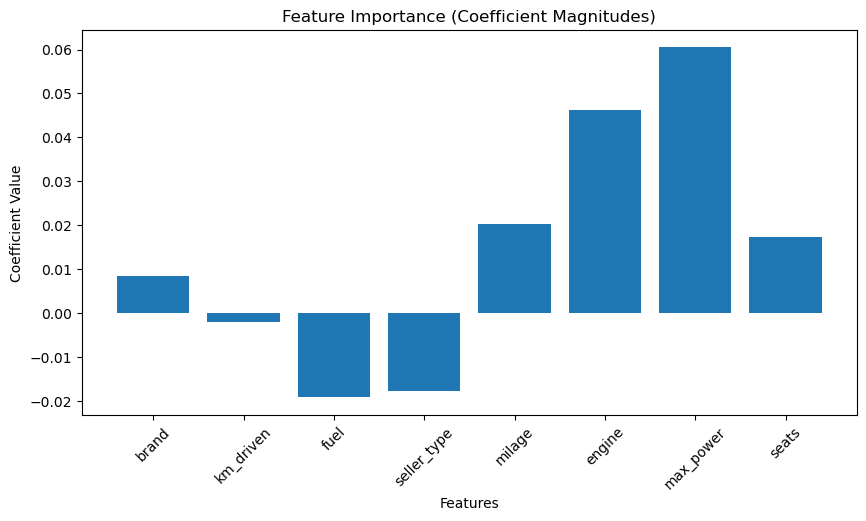

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/5236d0ce4ec746f495a7c677ee41b2b1
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=batch | Mom=0 | MSE=0.0101 | R2=0.1780
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:36:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:36:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/bd388afbe4fa489b9647104f18e5ddd0
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:36:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


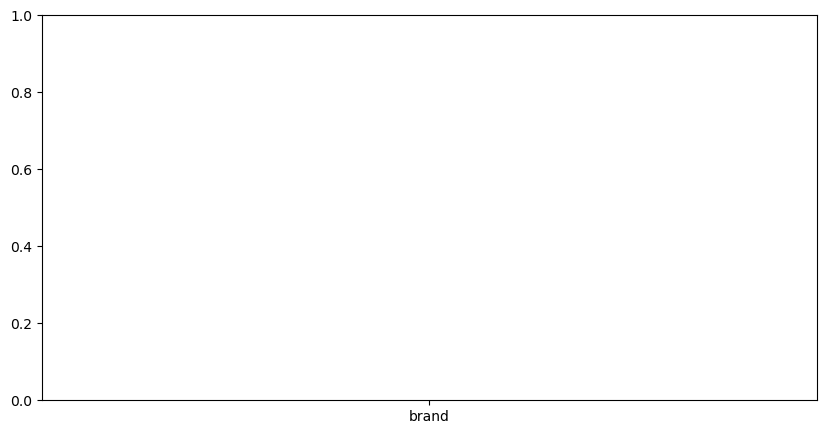

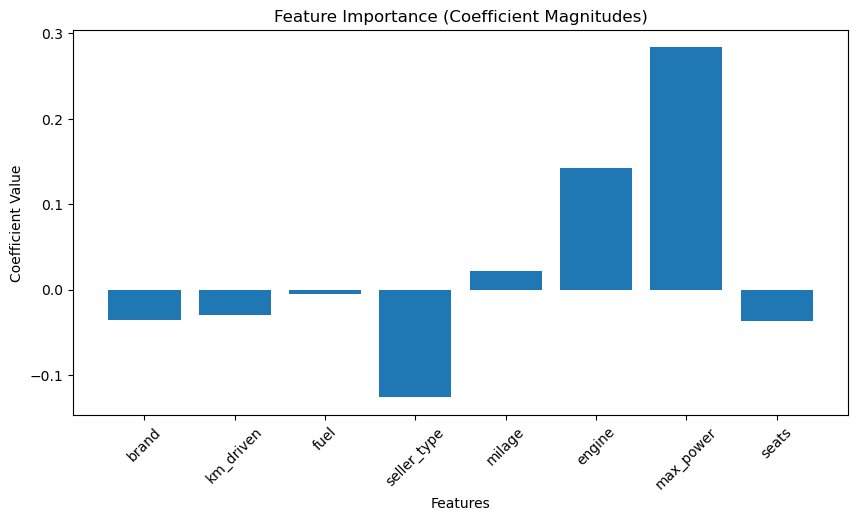

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/b0164d4db2a1459e8e75ff3585508fde
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=batch | Mom=0.9 | MSE=0.0061 | R2=0.5056
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/dea8351c46fe47c49e4a05ad872fa198
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


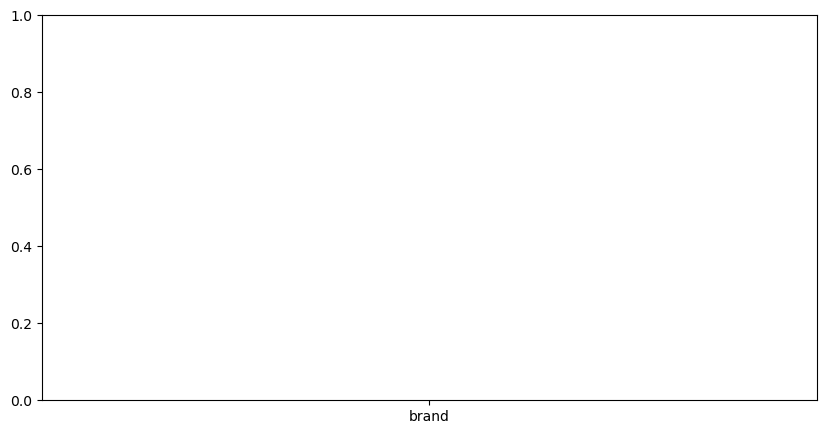

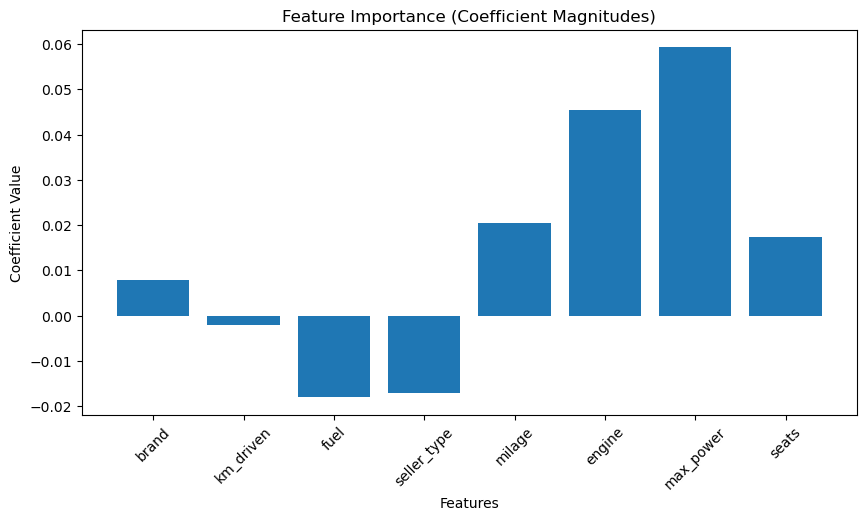

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/7629ebf8d2e24698addc412cc554026e
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=mini | Mom=0 | MSE=0.0102 | R2=0.1769
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/4457611e45764e05b6daa40041283ee3
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


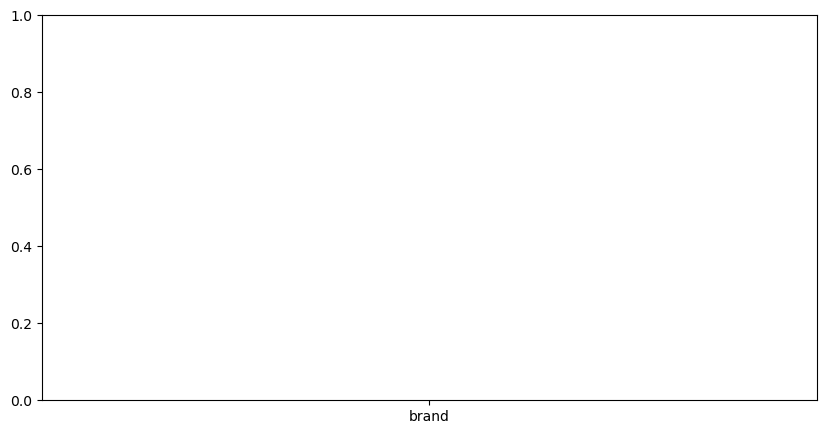

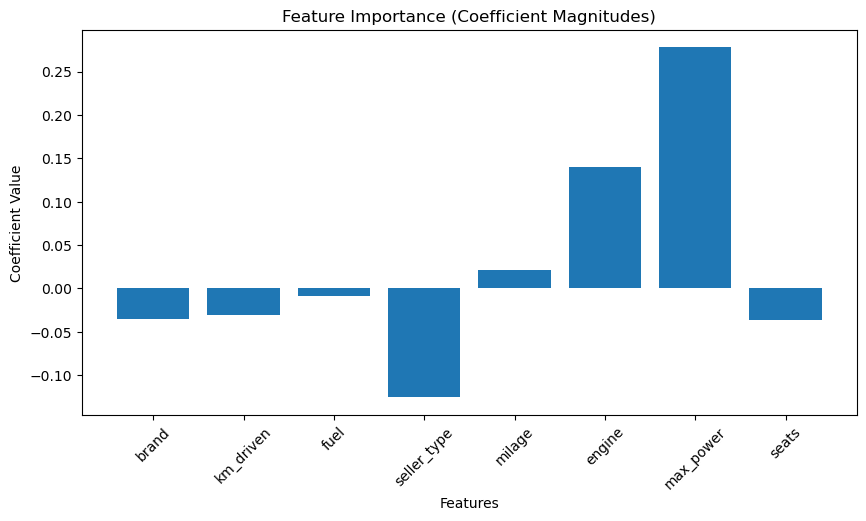

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/28cdeaae14ee46dfb420b44f25553edc
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=mini | Mom=0.9 | MSE=0.0061 | R2=0.5030
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:37:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/4605753281254b39872708cd6748d5a3
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:37:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:38:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


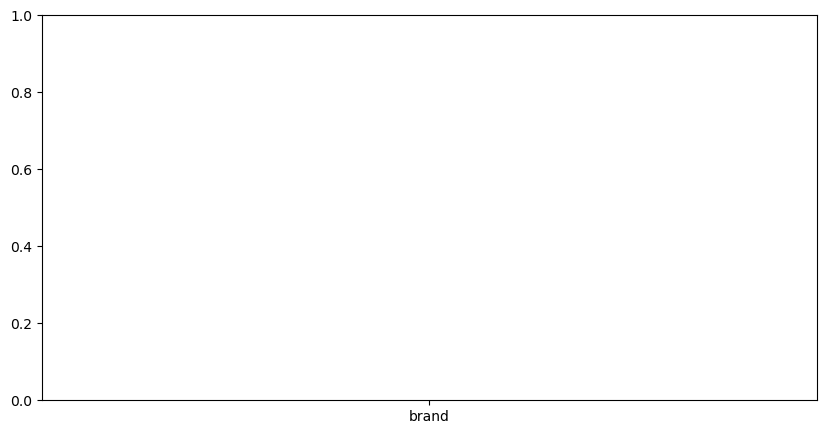

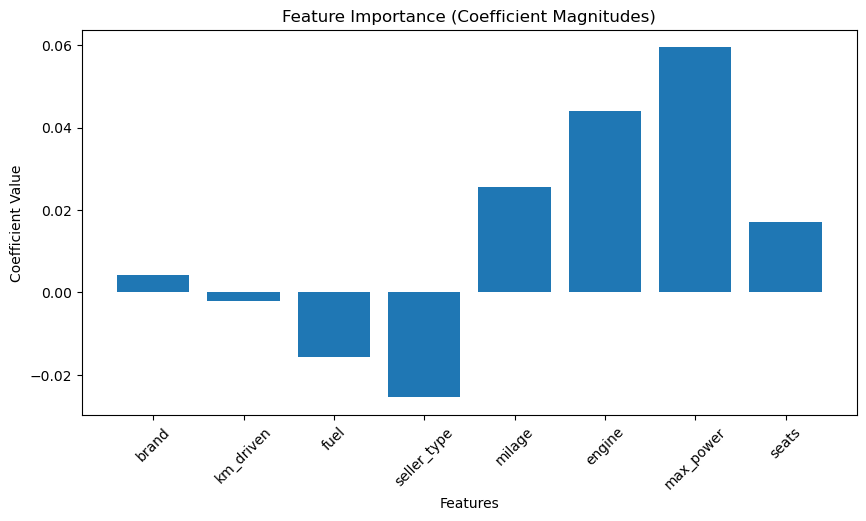

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/f7844ed4a79b40fc8a42fee515914b04
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=stochastic | Mom=0 | MSE=0.0102 | R2=0.1745
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:38:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:38:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/69be8d90545e4590982df601bdcaebd1
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:38:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:38:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


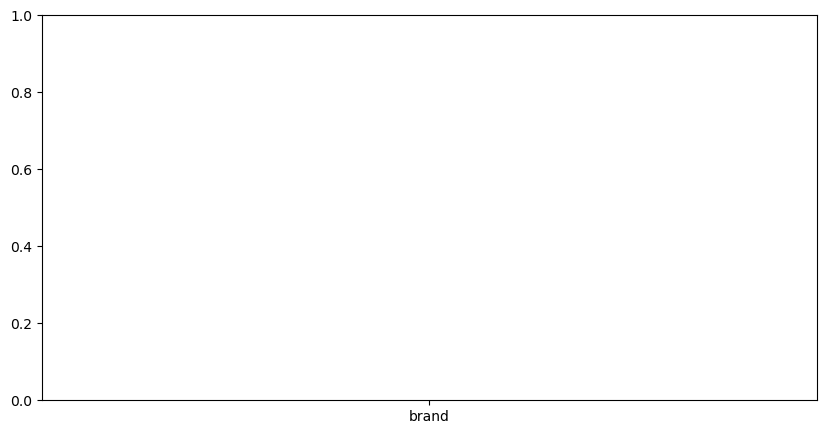

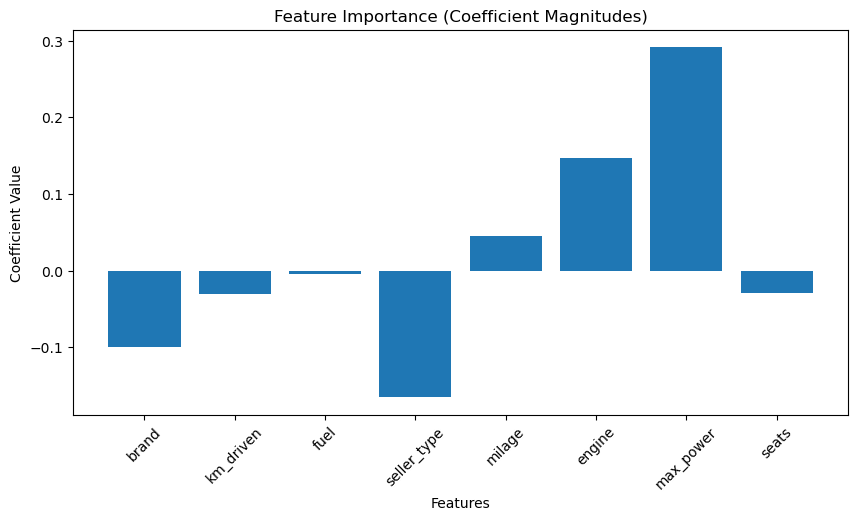

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/c6c9e3fd41c44f37b1556ef80cb13c88
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=zero | Method=stochastic | Mom=0.9 | MSE=0.0069 | R2=0.4353
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:38:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:38:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/2ddfd903632443a18be83383a4271fe9
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:38:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:39:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


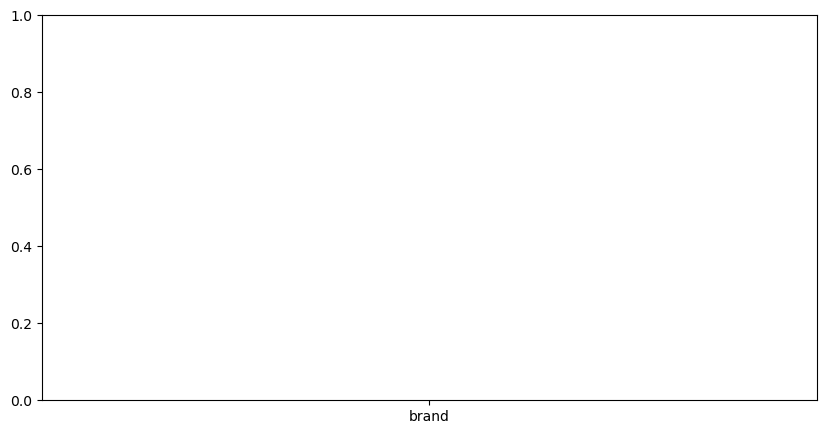

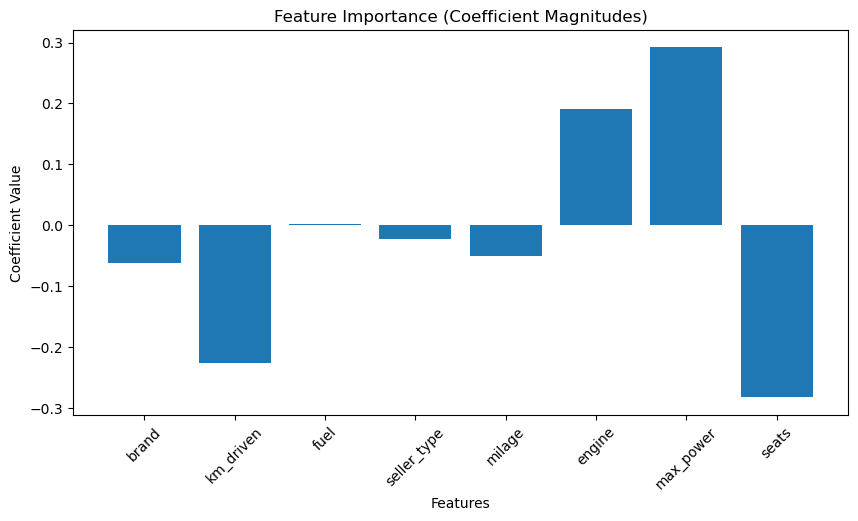

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/26eec8579a544a5e908bb21de47312e2
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=batch | Mom=0 | MSE=0.0106 | R2=0.1495
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:39:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:39:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/4850c01fe271445eba112dc55f4d650f
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:39:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:39:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


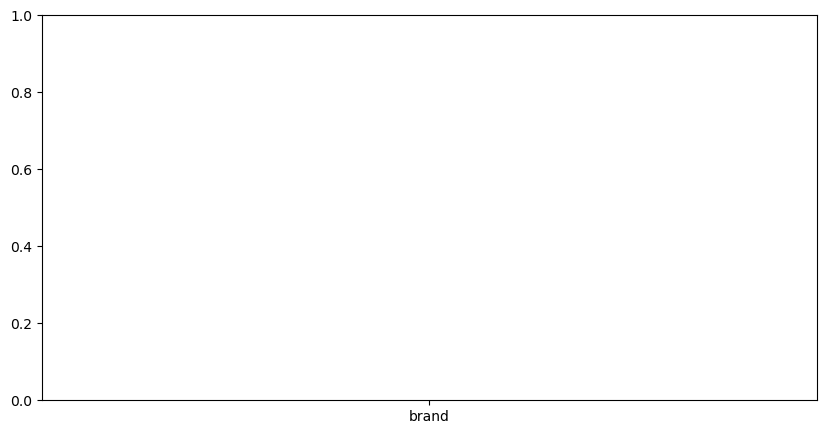

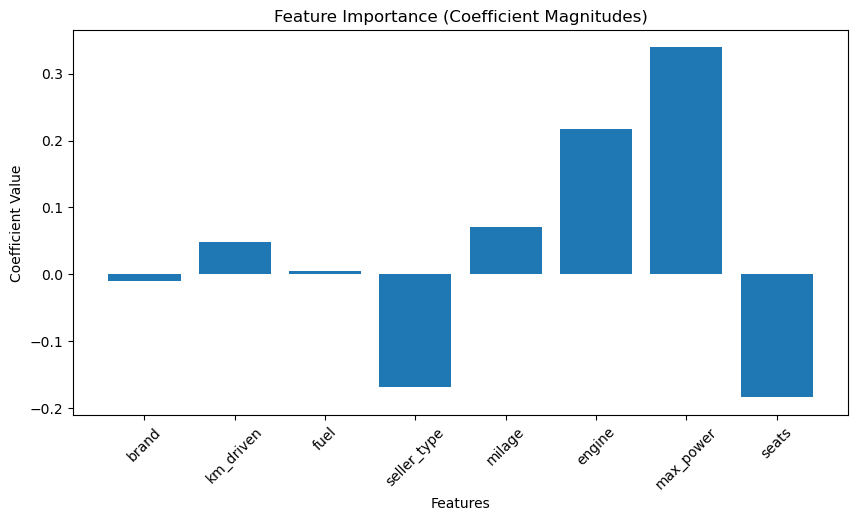

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/b90f79a2d5884b7d9e790ade22084cb2
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=batch | Mom=0.9 | MSE=0.0061 | R2=0.5058
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:39:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:39:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/62987aead69743888c974ced2801151d
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:40:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:40:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


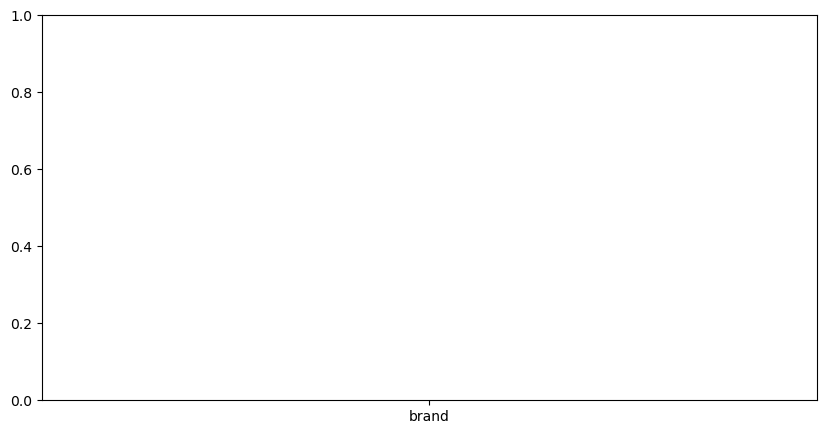

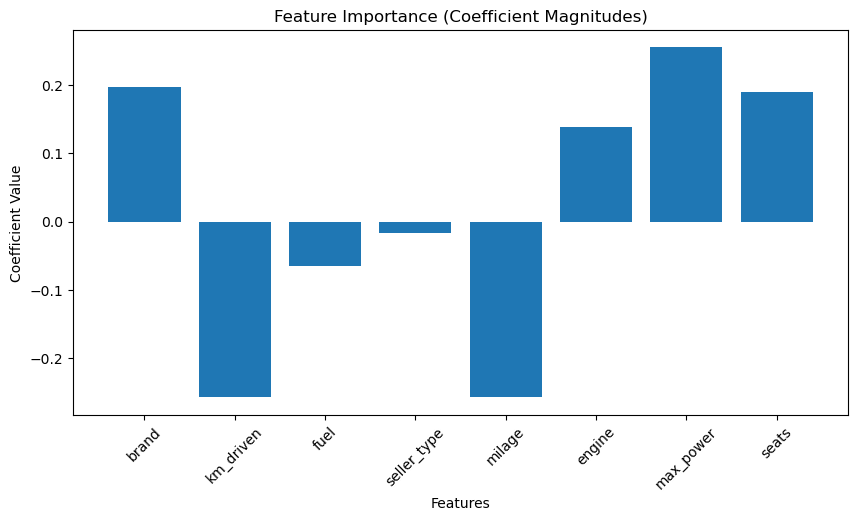

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/276399e8d96f42e0acd2783b7007c0f0
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=mini | Mom=0 | MSE=0.0153 | R2=-0.2400
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:40:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:40:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/d132b6acbc6140b08a2da8e78a6baeb7
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:40:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:40:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


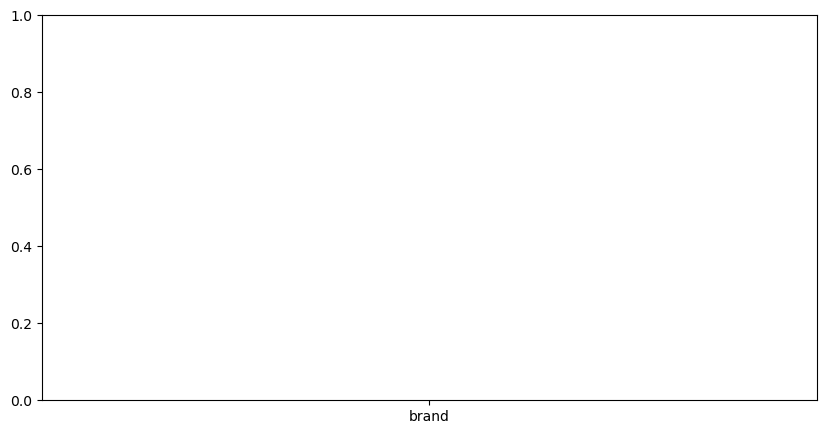

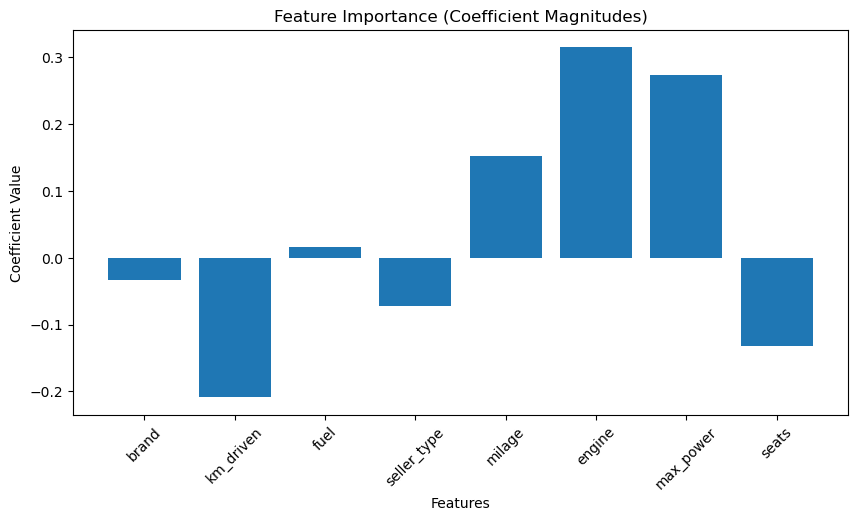

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/9d3edd608cd94f6e9ea58213ca1a069a
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=mini | Mom=0.9 | MSE=0.0068 | R2=0.4505
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:40:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:41:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/9475e8a0233a4c73a5306d2ba84185e2
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:41:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:41:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


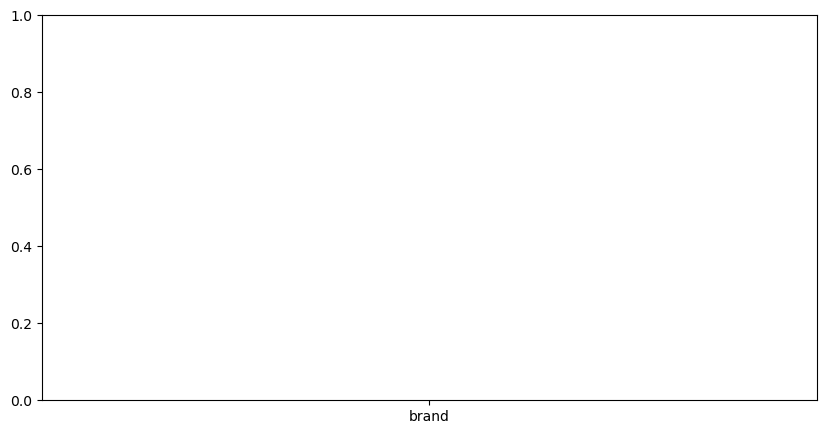

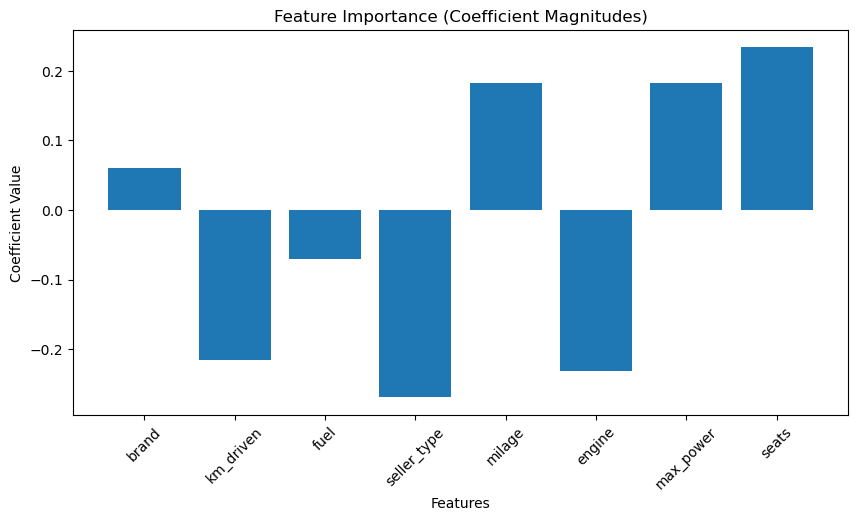

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/7daa9d656a5f4706a68a3c754ea91797
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=stochastic | Mom=0 | MSE=0.0128 | R2=-0.0350
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:41:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:41:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/7435069bb8a34eb48963bd3643b49853
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:41:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:42:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


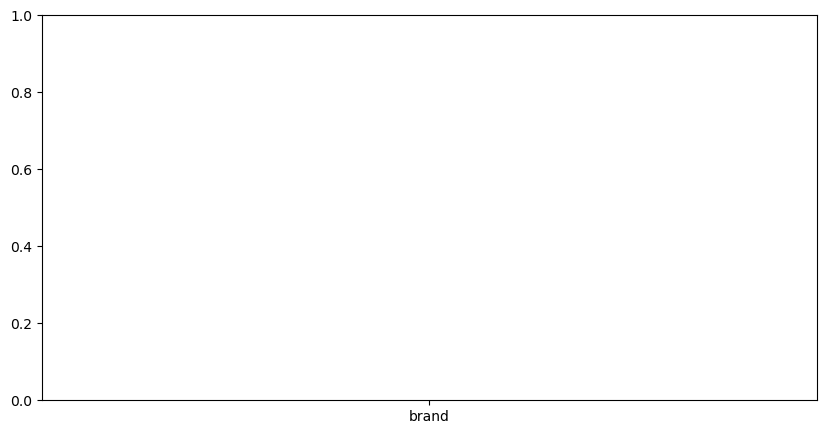

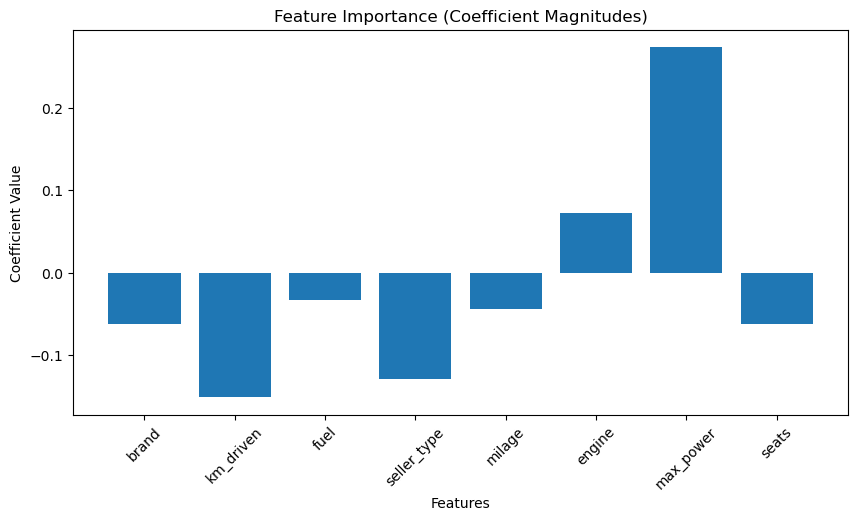

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/8ba0b10685f04835b7246c877c3ff10e
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.01 | Init=xavier | Method=stochastic | Mom=0.9 | MSE=0.0068 | R2=0.4533
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:42:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:42:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/7aba72f65e494534aa5691cbc1d37cc8
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:42:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:42:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


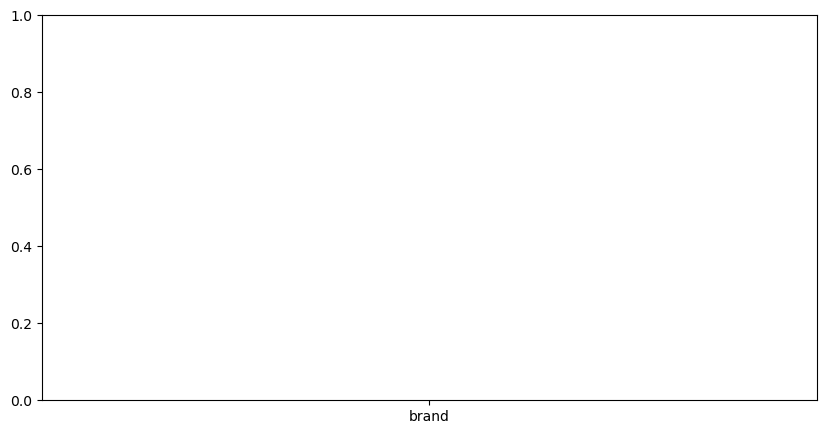

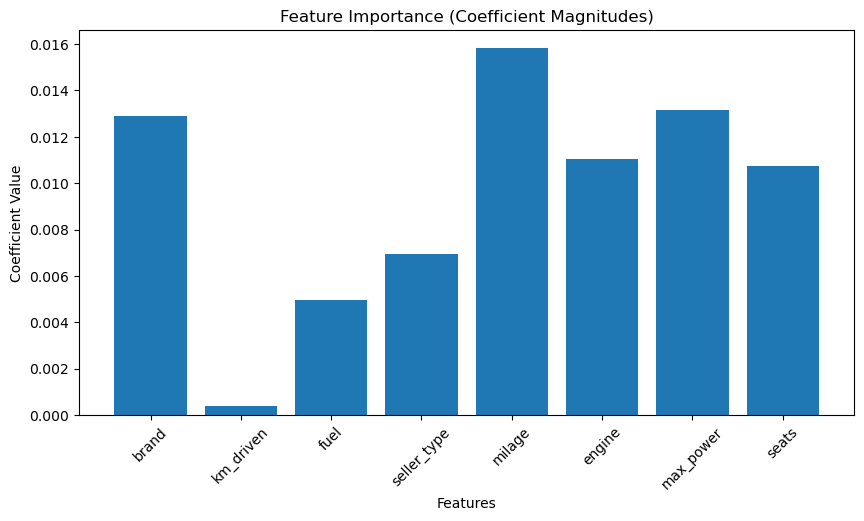

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/8dacc7e7d08949329a03cec1a3ab1516
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=batch | Mom=0 | MSE=0.0128 | R2=-0.0419
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:42:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:42:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/034d142d8a514837b390aea547cf6561
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:42:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:43:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


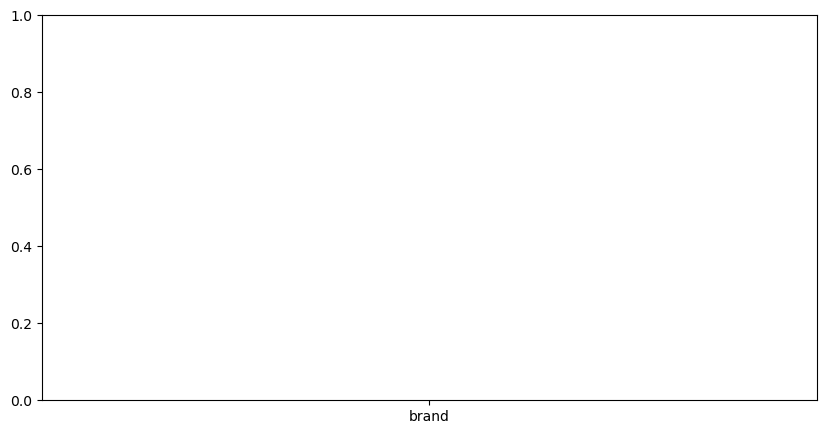

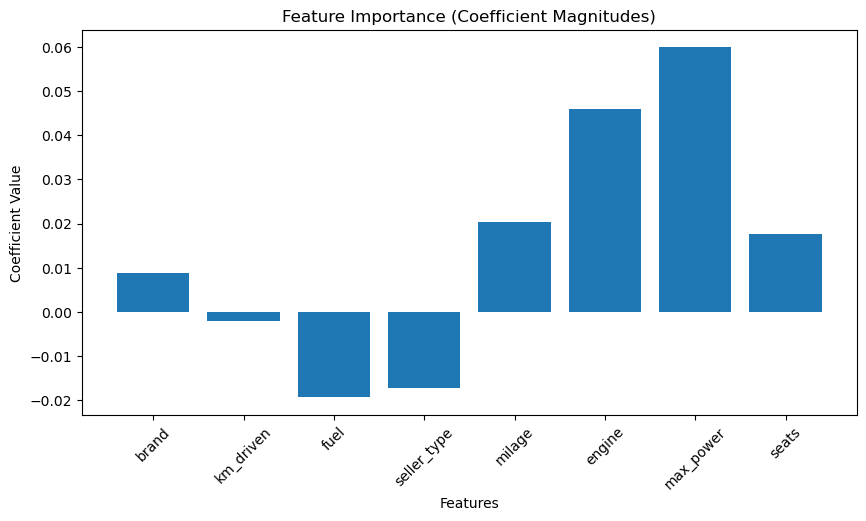

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/7f40cb00a8d6499abad7cecb475de098
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=batch | Mom=0.9 | MSE=0.0102 | R2=0.1764
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:43:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:43:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/57ff97d3778f47dfaba323dfdadb7731
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:43:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


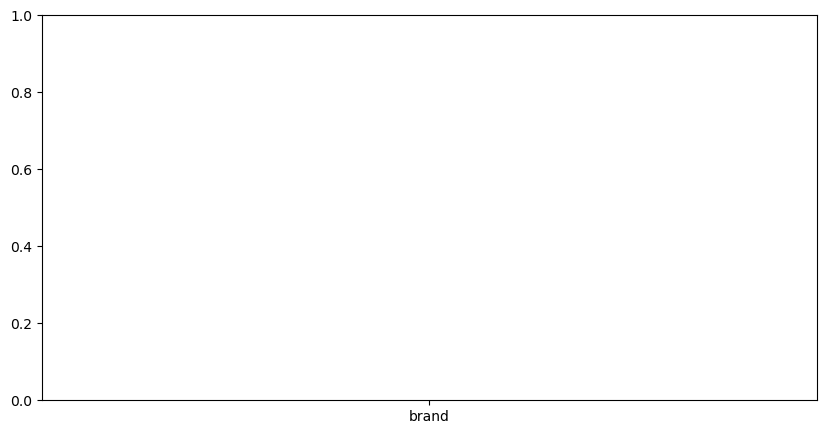

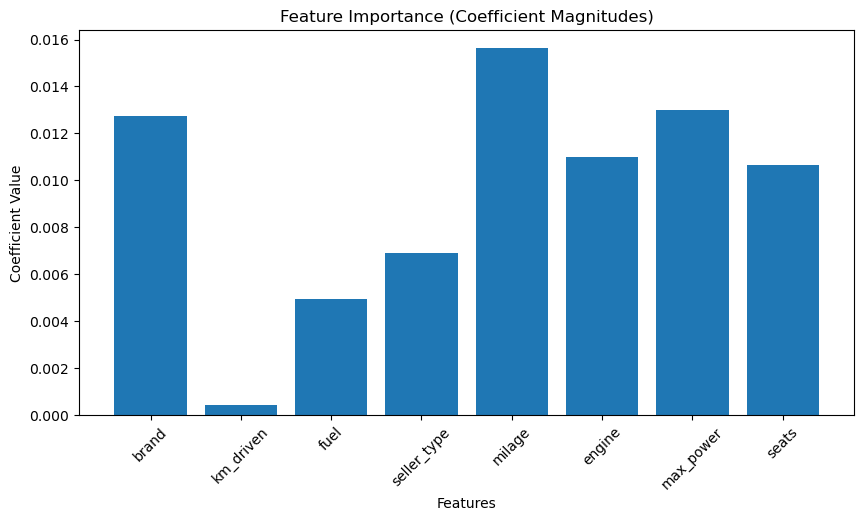

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/892cef3be301450ca61fac791313e22c
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=mini | Mom=0 | MSE=0.0129 | R2=-0.0425
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:43:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:43:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/3f5f4418239e4566bda77b326403a093
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:43:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:44:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


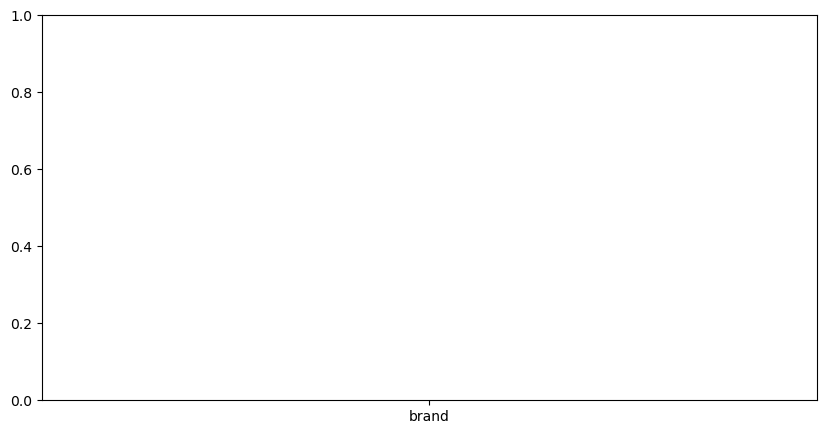

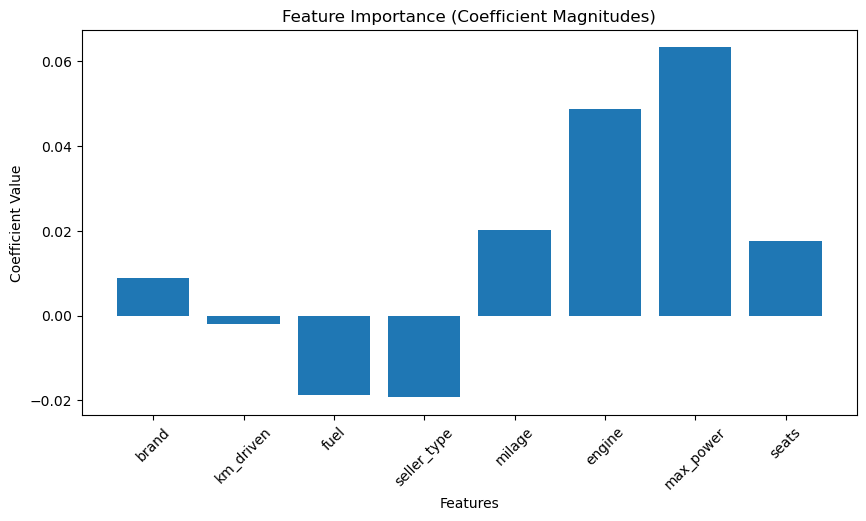

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/d1cad224a99342ce9ab000fbab5848e2
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=mini | Mom=0.9 | MSE=0.0102 | R2=0.1772
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:44:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:44:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/1d2eca06e5c8453e8912e485656c6673
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:44:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:44:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


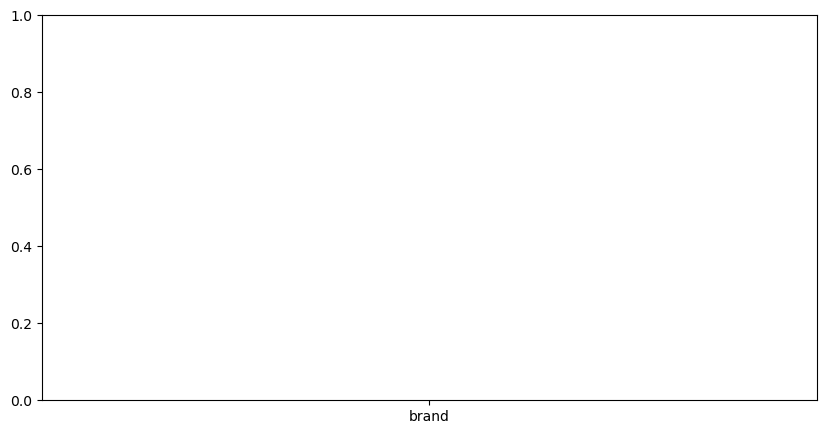

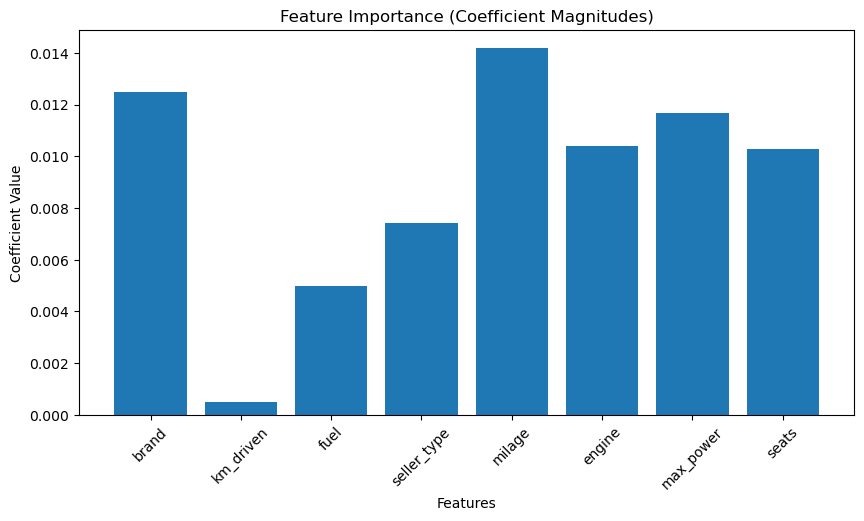

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/9cfdfd2cbc7644a4b962c0b3bc4fd5b0
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=stochastic | Mom=0 | MSE=0.0130 | R2=-0.0517
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:44:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:45:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/7452498da1d546c2a207aa65e032c0ce
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:45:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:45:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


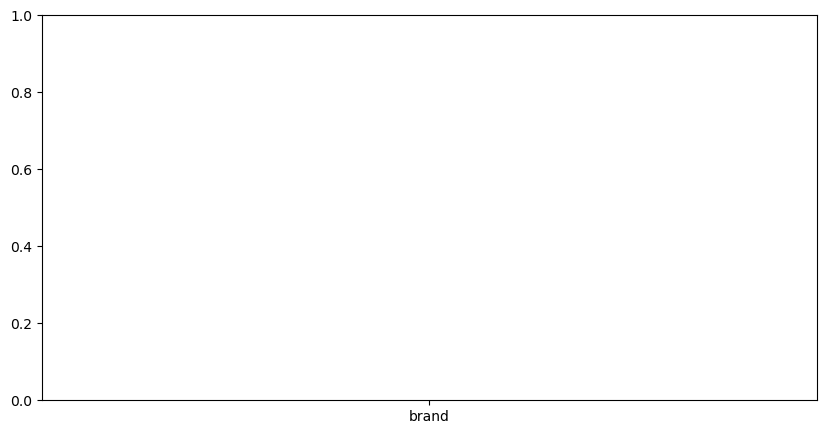

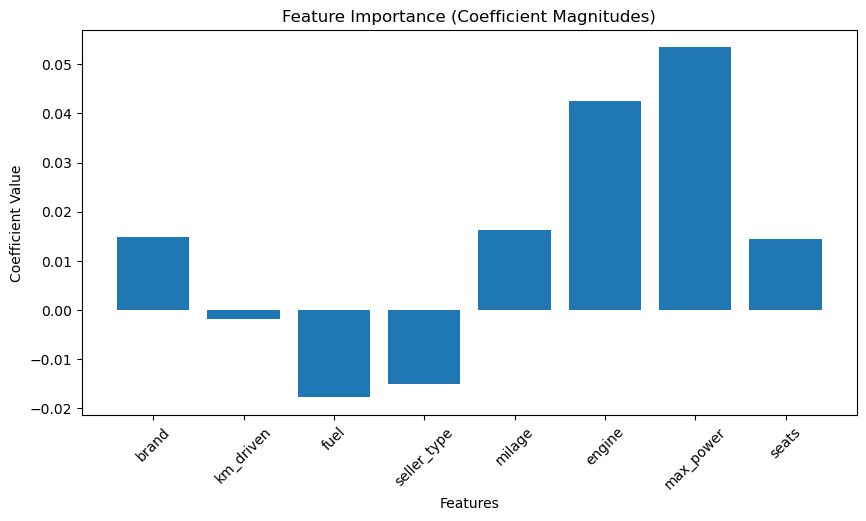

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/a932b61063a046b49f43438106720f8d
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=zero | Method=stochastic | Mom=0.9 | MSE=0.0102 | R2=0.1744
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:45:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:45:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/f05f56ec1fb9490386aa89f476db7d36
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:45:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:45:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


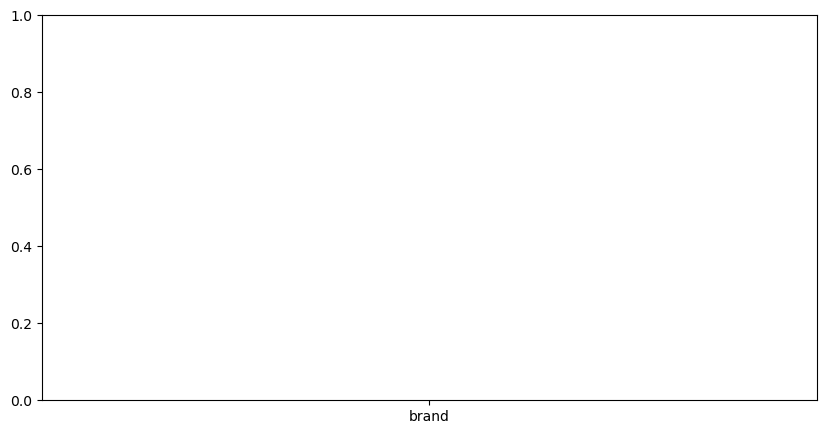

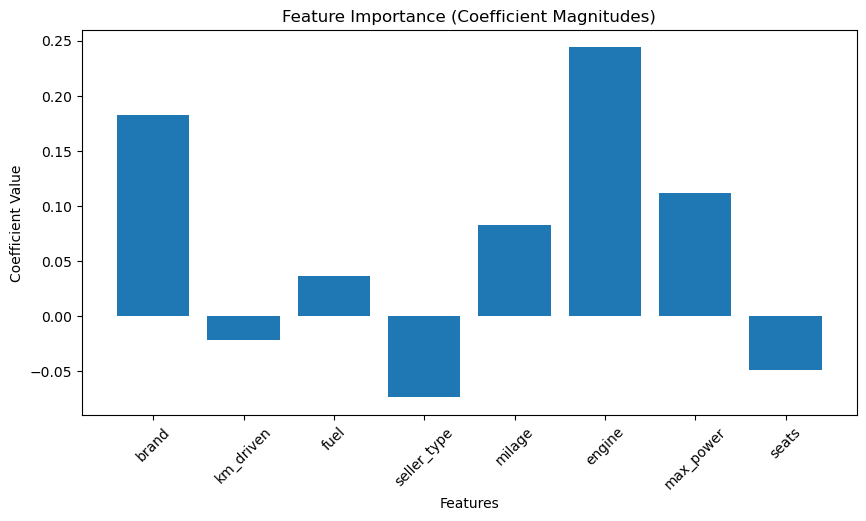

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/f7868ad0752148b6b23613a6189e327a
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=batch | Mom=0 | MSE=0.0334 | R2=-1.7105
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:46:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:46:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/aa4664e1691747eea820e0256a1c9795
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:46:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:46:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


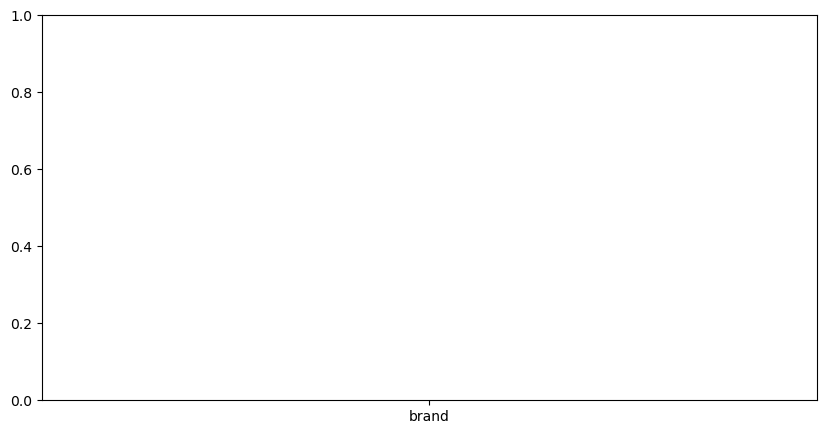

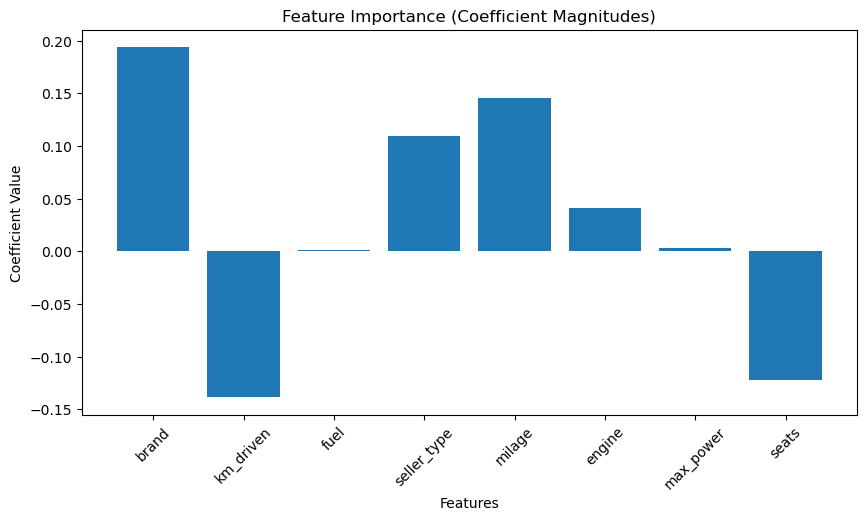

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/4414379e6d944521a7347ba272e37962
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=batch | Mom=0.9 | MSE=0.0149 | R2=-0.2066
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:46:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:46:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/3d594fed33384489970501f1f838f270
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:46:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:47:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


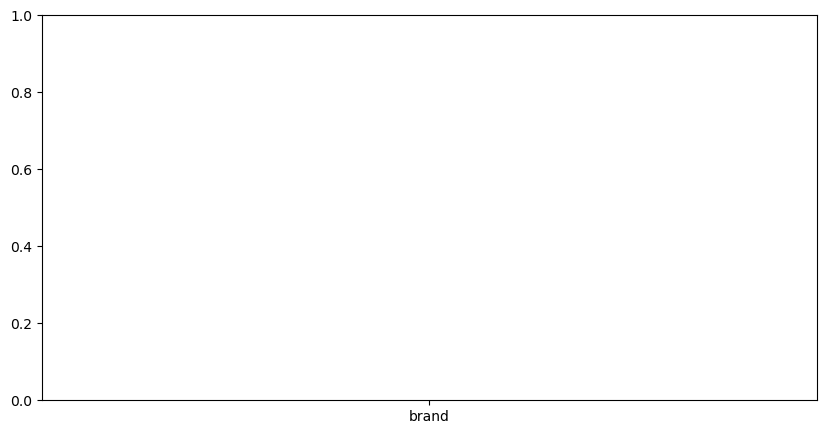

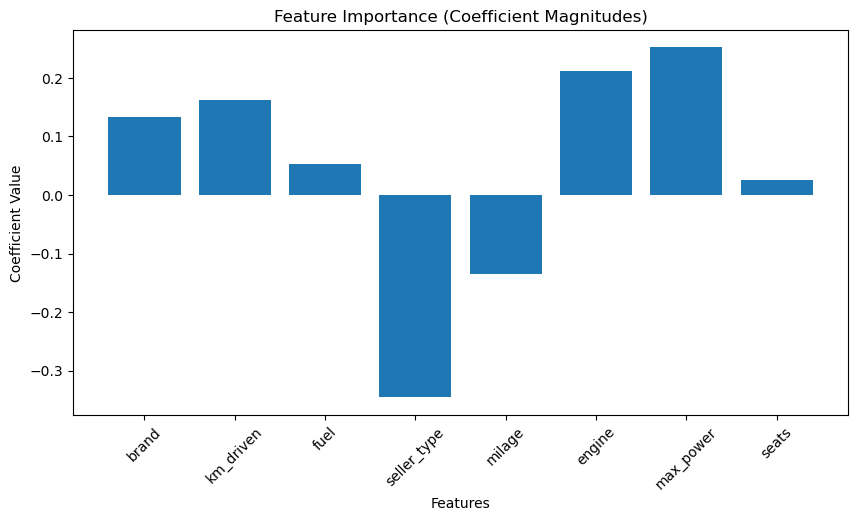

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/a4624fd1d314452188abf1fd1d130173
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=mini | Mom=0 | MSE=0.0303 | R2=-1.4528
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:47:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:47:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/976a2d1c125546e2ba4b14adfbf25a1c
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:47:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


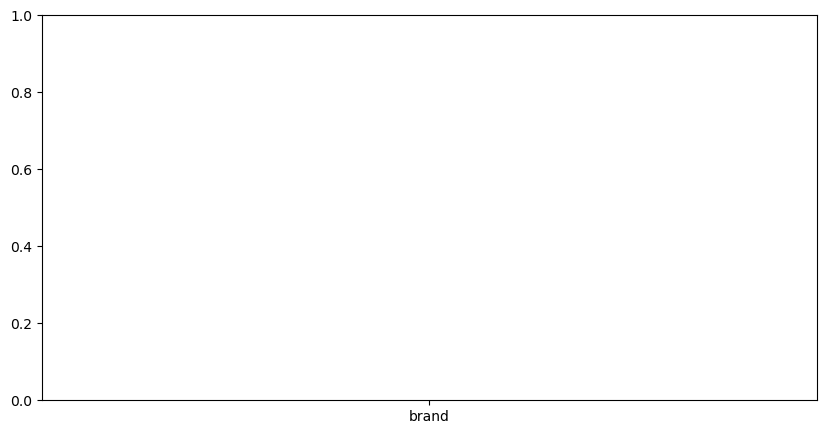

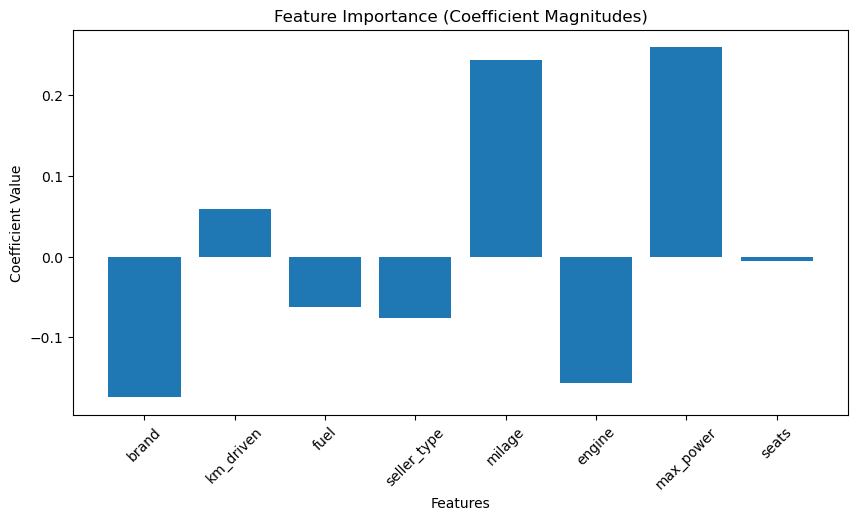

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/af3703b3d53d41288c53f04b3f16e68d
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=mini | Mom=0.9 | MSE=0.0135 | R2=-0.1002
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:47:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:48:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/df593a09caeb4d02ac0a706f8f4bde69
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:48:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:48:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


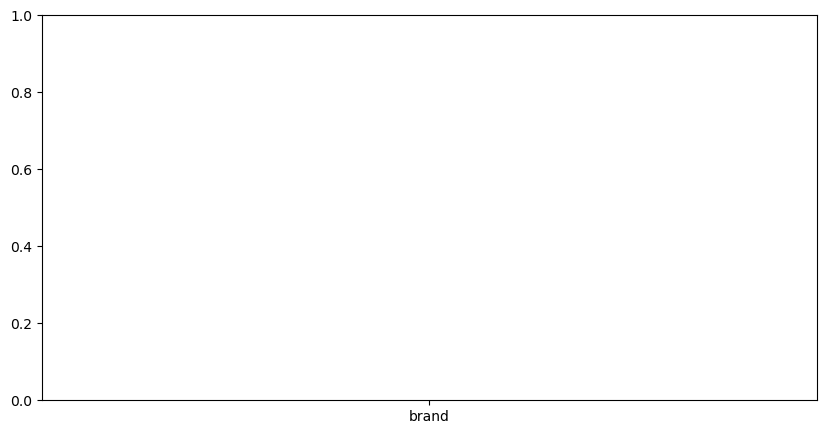

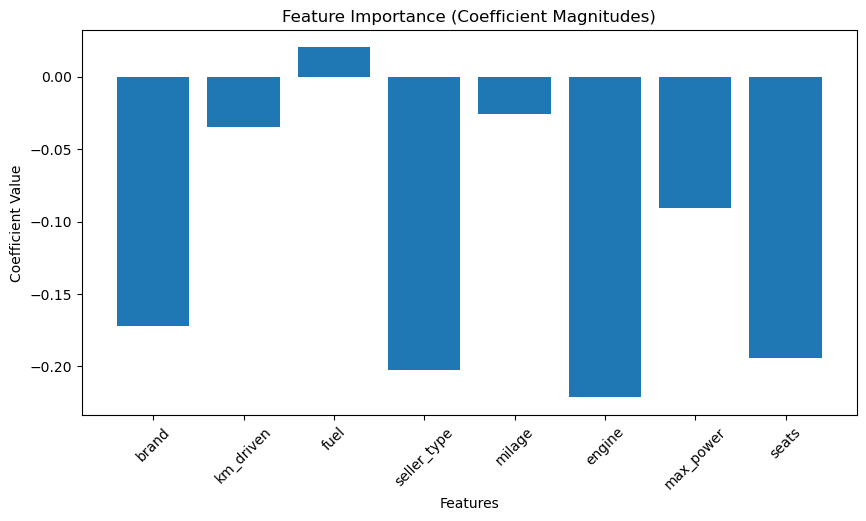

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/6ce5450a25d1418a87ff6d1a0e663374
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=stochastic | Mom=0 | MSE=0.0449 | R2=-2.7111
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:48:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:48:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/9bd359ca8e5a4f64b44cc1c592cec696
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:48:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:48:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


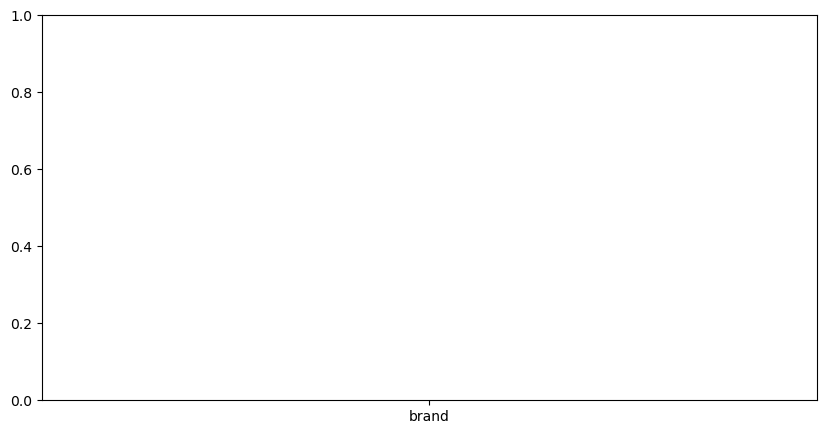

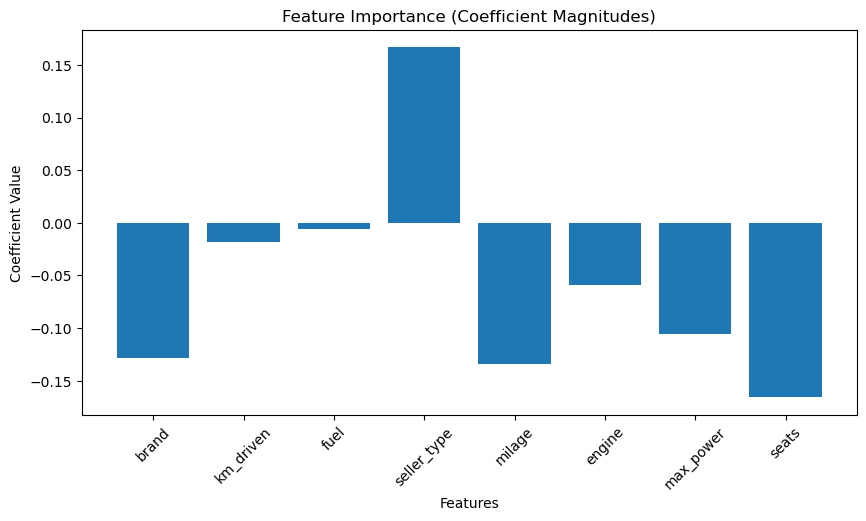

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/6505e363d71f49d69adc23d9b4a741a9
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.001 | Init=xavier | Method=stochastic | Mom=0.9 | MSE=0.0128 | R2=-0.0503
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:49:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:49:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/8433f7525e424480bc1aa04b5840a6f0
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:49:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:49:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


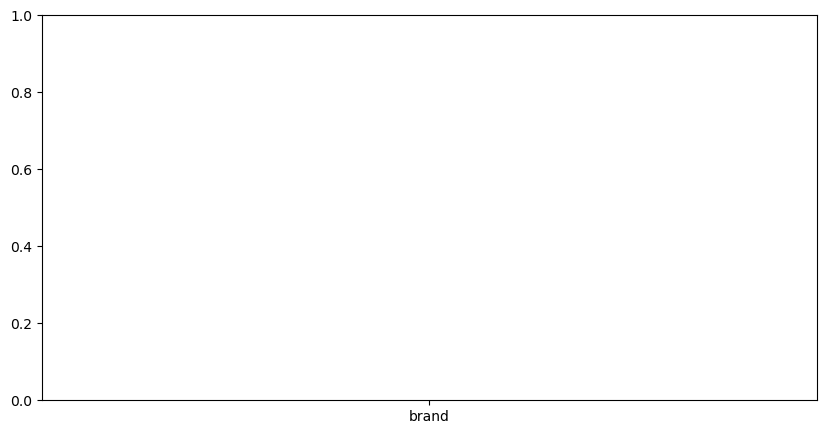

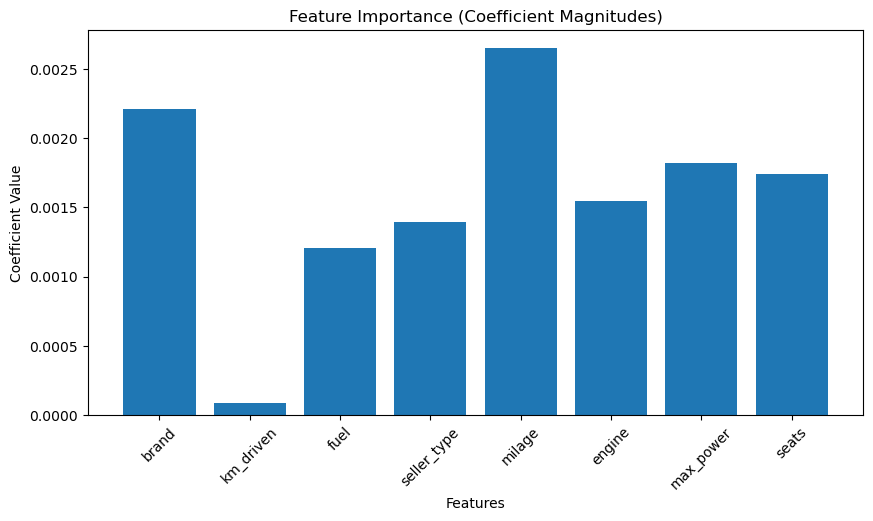

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/b9add2050ec24ed1b41868cb1151fc7b
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=batch | Mom=0 | MSE=0.0180 | R2=-0.4607
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:49:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:49:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/ff101b4578f64fe8aa26bb9cc8430d03
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:49:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:50:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


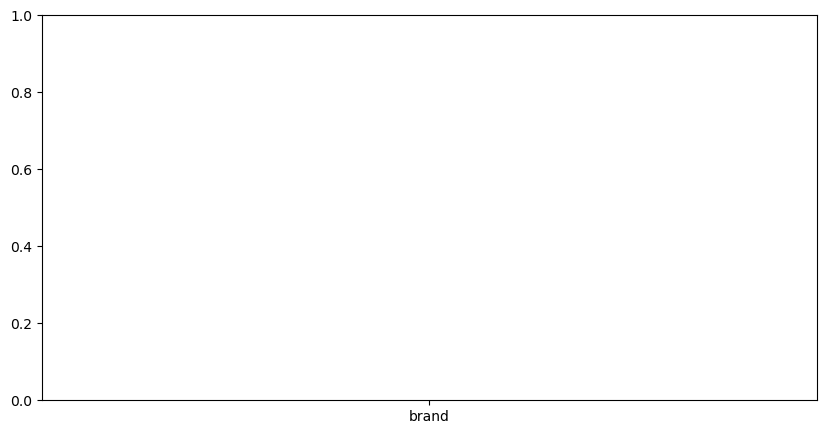

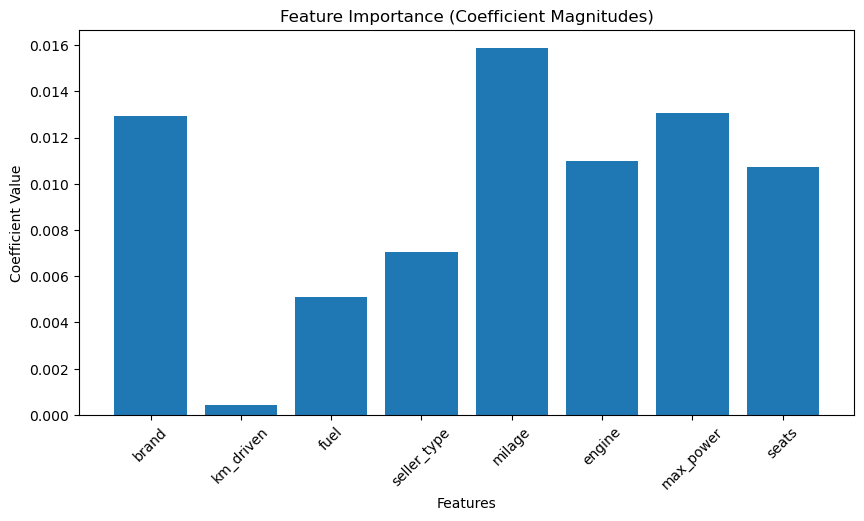

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/ab1c03ef745b421c8afba86f75e86b96
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=batch | Mom=0.9 | MSE=0.0128 | R2=-0.0418
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:50:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:50:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/aa372b1ed9104ee2ae66772fd98206a6
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:50:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:50:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


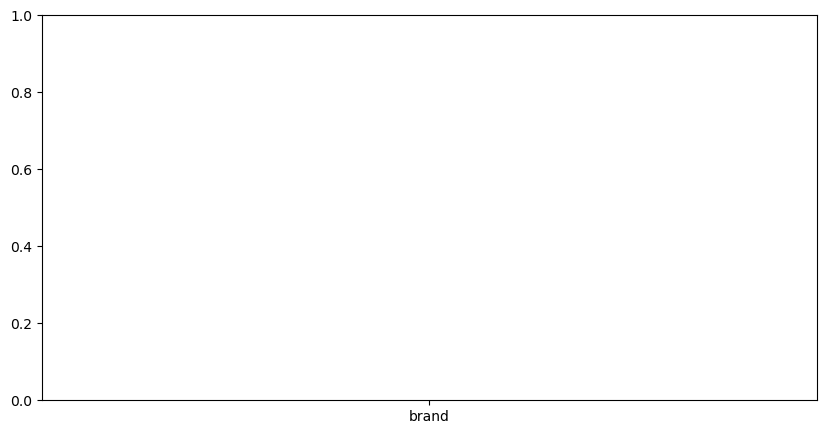

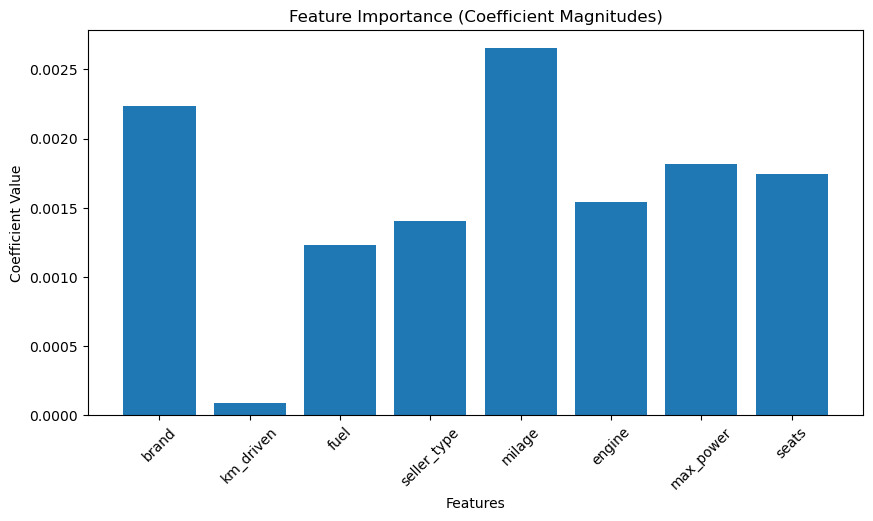

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/56ae64c2367a4657b0f6ec229a1d2389
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=mini | Mom=0 | MSE=0.0180 | R2=-0.4608
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:50:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:50:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/c04de3043d6e41a5b4ba78e1e17a2614
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:51:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:51:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


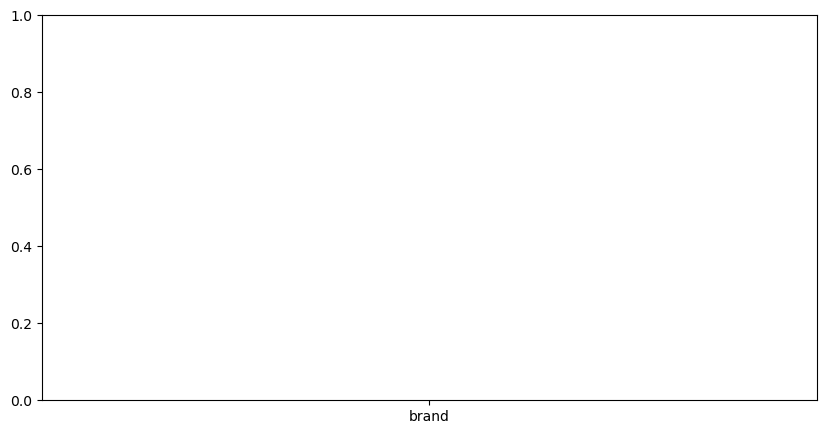

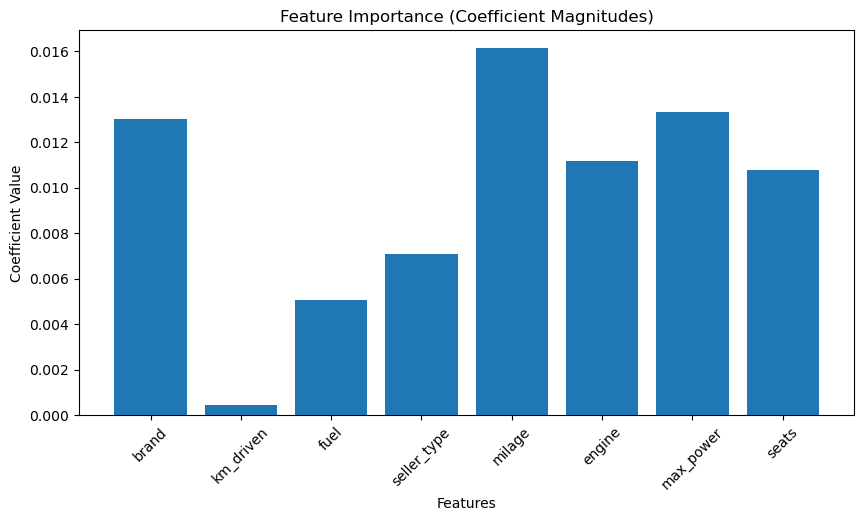

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/fd4c7a5a7b6b4278864d6e10992b4ef4
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=mini | Mom=0.9 | MSE=0.0129 | R2=-0.0429
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:51:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:51:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/ec69f0d30ed743c2b36b1333937b02a7
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:51:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:51:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


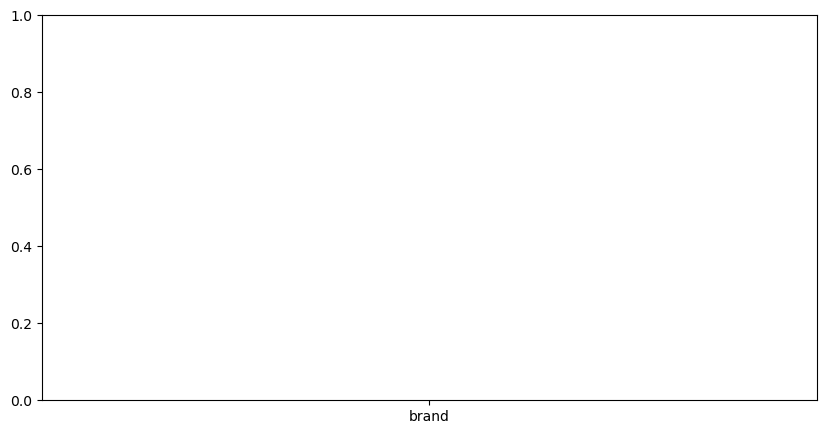

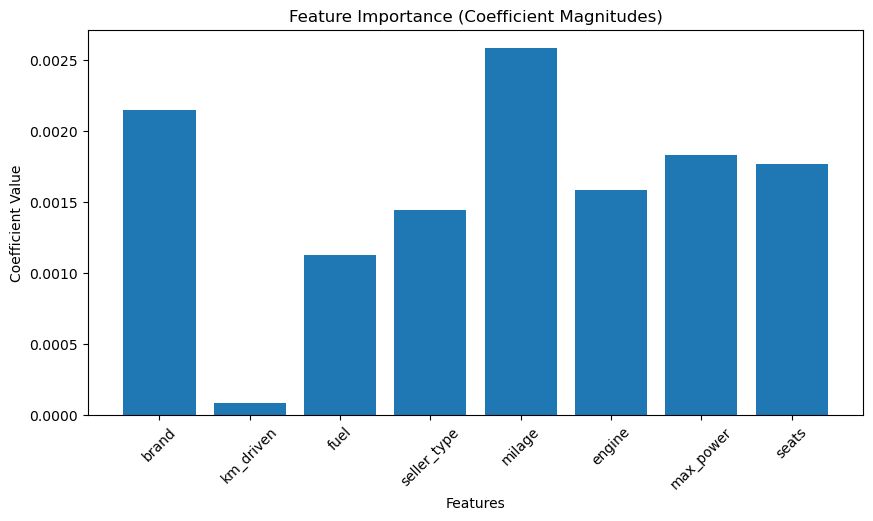

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/1e78d1bb9112400397a2fa12be9311d8
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=stochastic | Mom=0 | MSE=0.0180 | R2=-0.4570
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:51:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:52:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/f831e3a4e8904a31a520cc4925e4d14d
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:52:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:52:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


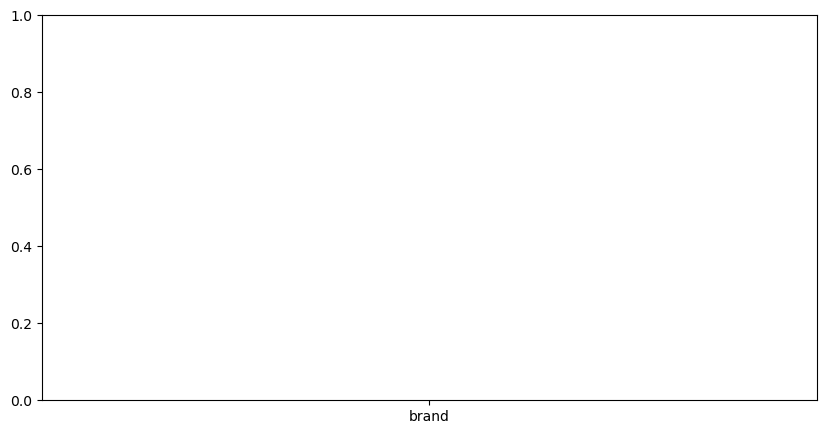

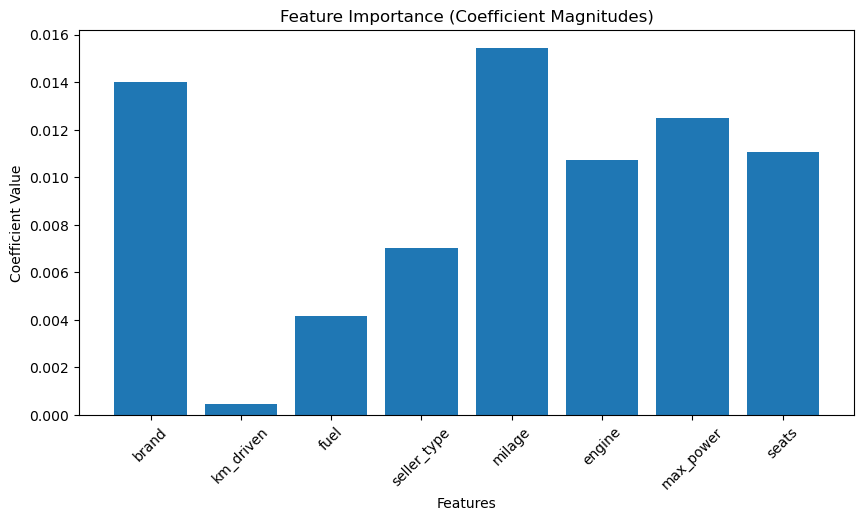

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/393ee4526e1e474ebbe554e7e2fdb8bd
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=zero | Method=stochastic | Mom=0.9 | MSE=0.0130 | R2=-0.0527
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:52:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:52:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/c5aadd17f0844dfb9c4256a791b46479
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:52:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:52:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


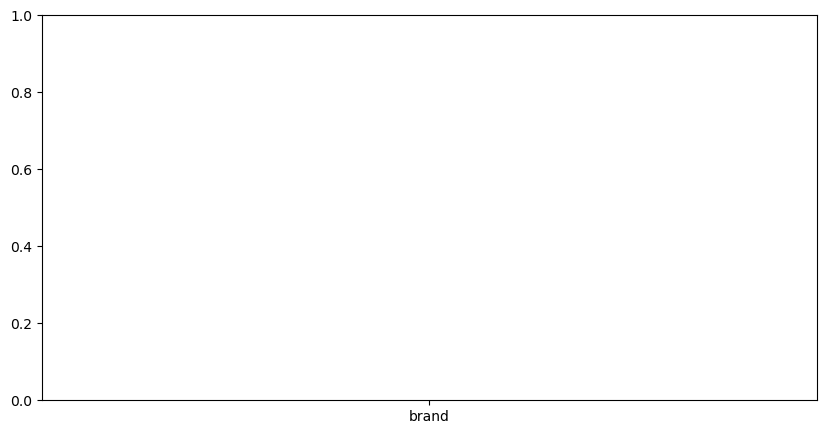

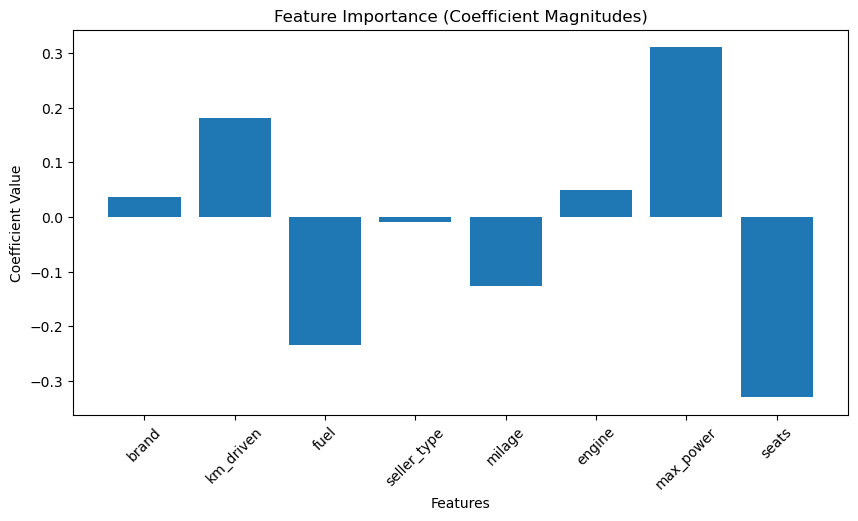

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/2641c39949604bf387857ec29b3e92a7
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=batch | Mom=0 | MSE=0.1534 | R2=-10.8748
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:53:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:53:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/c7cb48791ebb439abff229b515ed207d
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:53:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:53:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


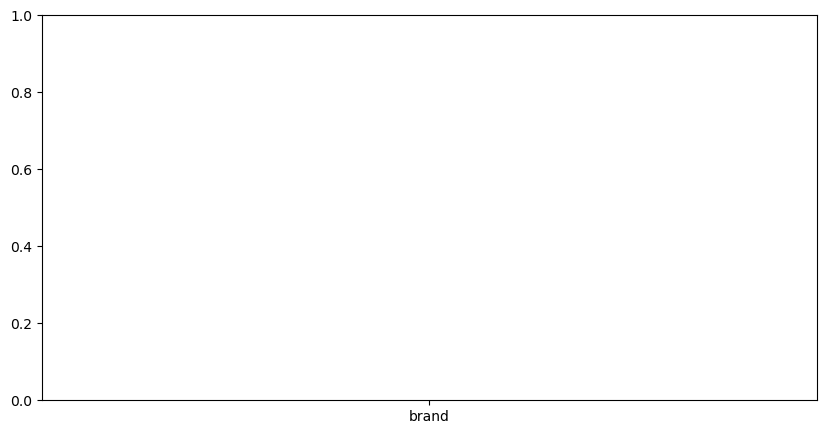

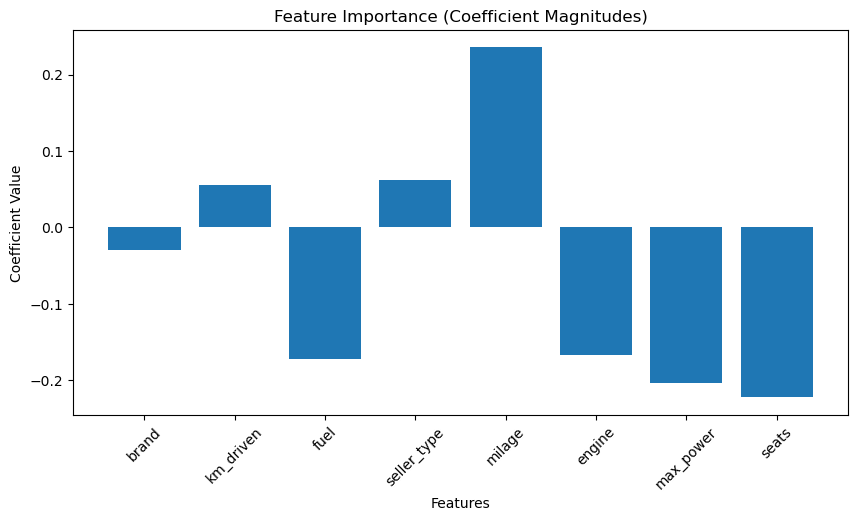

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/51245e24c0bb431da3a2a87d38500e11
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=batch | Mom=0.9 | MSE=0.0352 | R2=-1.8624
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:53:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:53:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/a9afc99229c84768bad317ba3cc17720
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:53:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:53:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


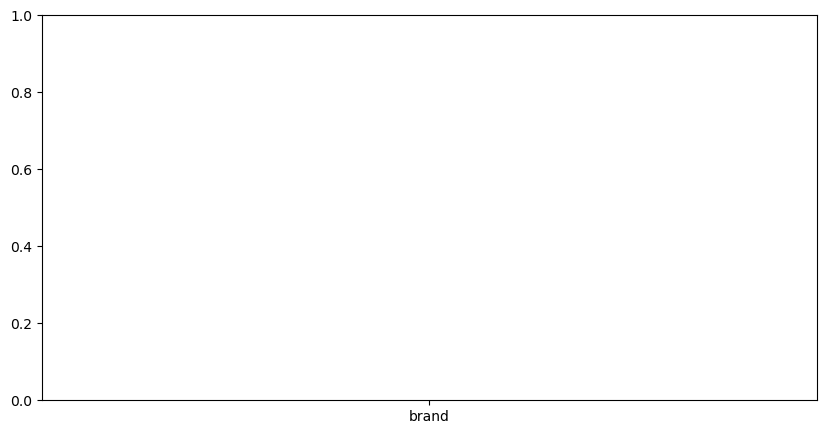

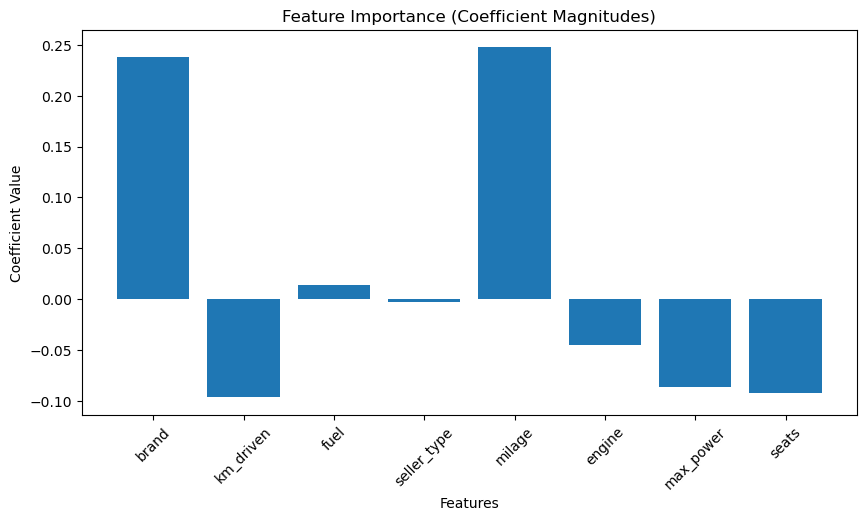

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/e36ae15c0ba24b70a0e7598e231fb63b
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=mini | Mom=0 | MSE=0.0756 | R2=-5.3921
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:53:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/5592909f9ca2497b87b4983c3155cb16
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:54:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


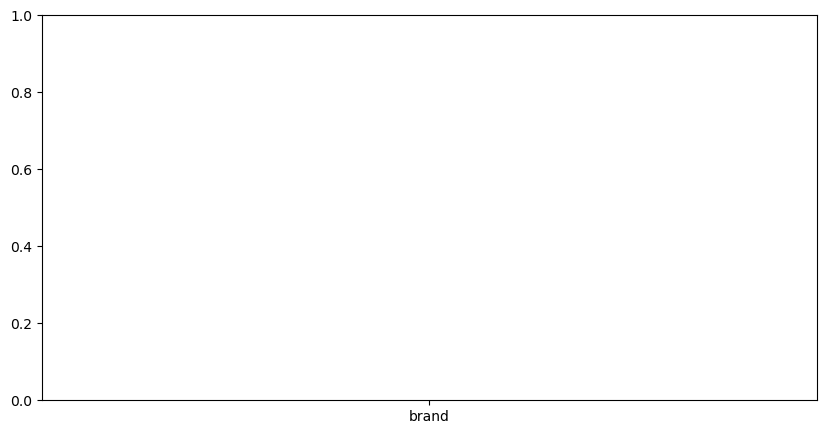

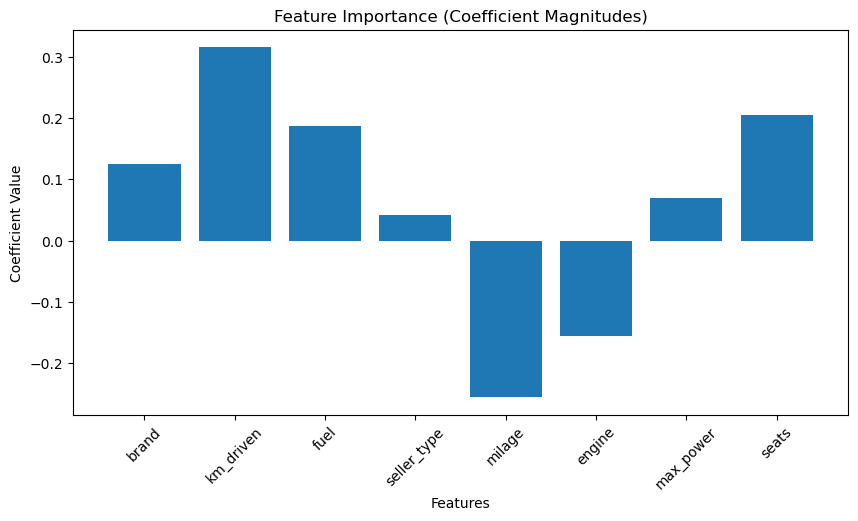

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/ef36883254c24439926aeb7896eee0b9
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=mini | Mom=0.9 | MSE=0.0363 | R2=-1.9169
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:54:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/6f316b4f0c3447c89d4d72d6d2508acc
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:54:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


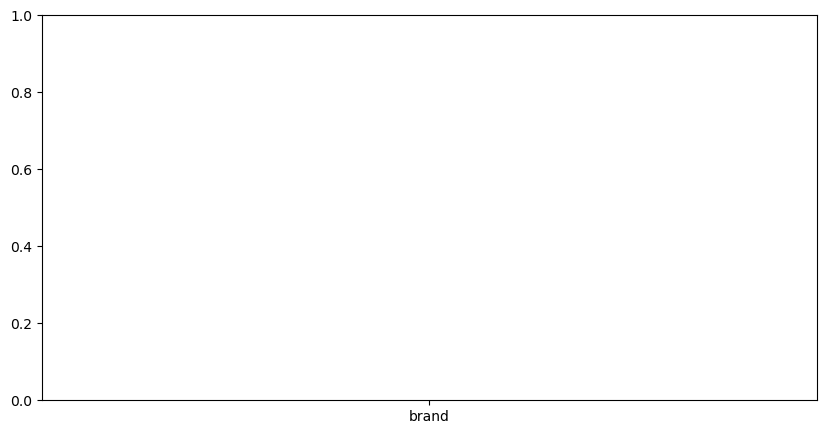

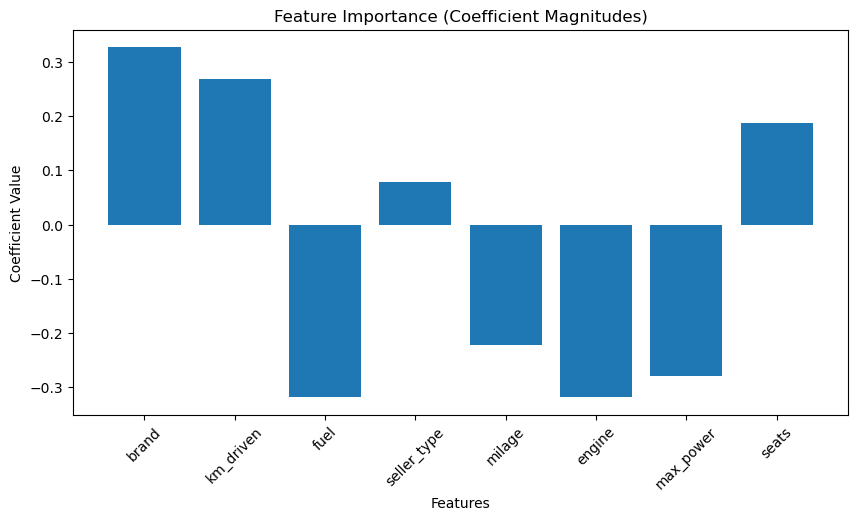

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/977b0d5f99104afc8b8d7f2234afe0ee
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=stochastic | Mom=0 | MSE=0.0862 | R2=-6.1854
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:54:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/d324668a2b2b4ef2b007c8f498ec6267
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:54:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:54:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


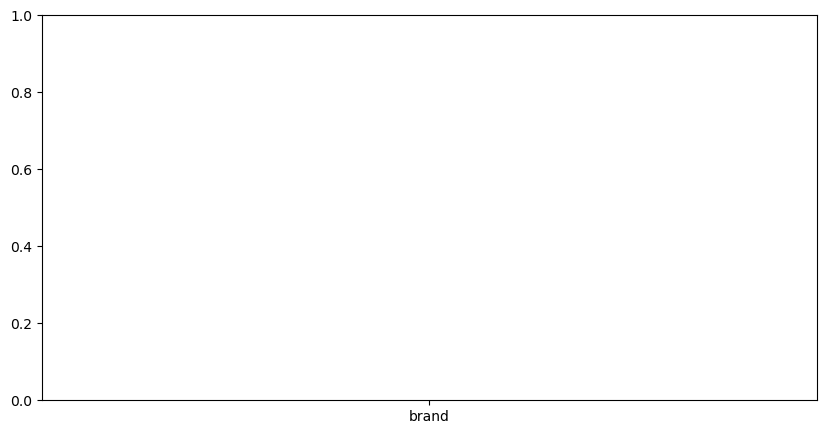

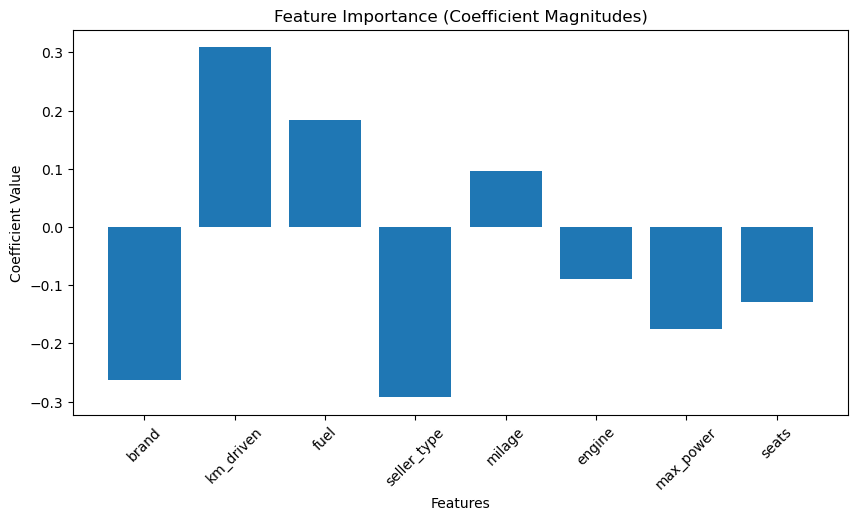

🏃 View run Normal_polyNone at: http://localhost:9000/#/experiments/787377846228956947/runs/9e5e28b2c9914a5ab278a5d3f4c91589
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Normal | Poly=None | LR=0.0001 | Init=xavier | Method=stochastic | Mom=0.9 | MSE=0.0484 | R2=-2.8979
❌ Failed: Lasso | Poly=None | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=None | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=None | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


2025/09/13 18:55:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/13 18:55:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Normal_poly2 at: http://localhost:9000/#/experiments/787377846228956947/runs/06972400c4c24906b85ebc43e5657b30
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
❌ Failed: Normal | Poly=2 | Error: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (44,) and arg 1 with shape (45,).
❌ Failed: Lasso | Poly=2 | Error: LassoRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Ridge | Poly=2 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'num_epochs'
❌ Failed: Elastic | Poly=2 | Error: ElasticRegression.__init__() got an unexpected keyword argument 'num_epochs'


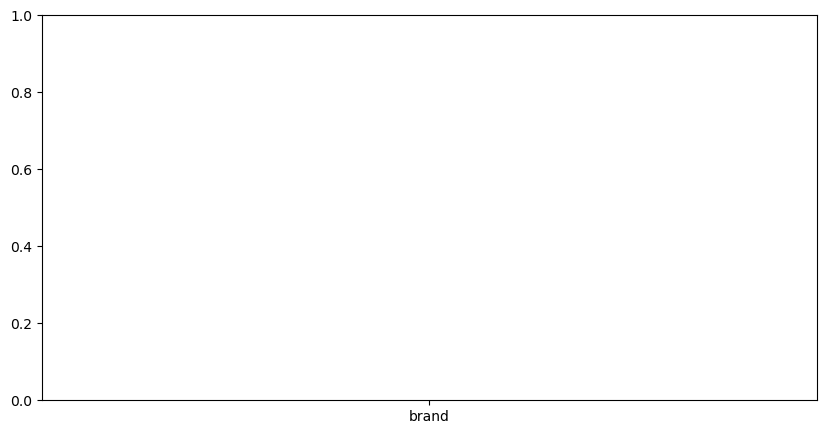

In [284]:
# === EXPERIMENT CONFIGURATION ===
feature_names = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']

learning_rates = [0.01, 0.001, 0.0001]
inits = ["zero", "xavier"]
methods = ["batch", "mini", "stochastic"]
momentums = [0, 0.9]
poly_degrees = [None, 2]

configs = [
    (LinearRegression, "Normal"),
    (LassoRegression, "Lasso"),
    (RidgeRegression, "Ridge"),
    (ElasticRegression, "Elastic")
]

results = []

for lr in learning_rates:
    for init in inits:
        for method in methods:
            for momentum in momentums:
                for poly in poly_degrees:
                    for cls, name in configs:
                        params = {
                            "lr": lr,
                            "method": method,
                            "num_epochs": 500,
                            "bs": 50,
                            "momentum": momentum,
                            "init": init
                        }
                        try:
                            mse, r2 = run_experiment(cls, f"{name}_poly{poly}", X_train, y_train, params, poly_degree=poly, feature_names=feature_names)
                            results.append([name, poly, lr, init, method, momentum, mse, r2])
                            print(f"✅ Logged: {name} | Poly={poly} | LR={lr} | Init={init} | Method={method} | Mom={momentum} | MSE={mse:.4f} | R2={r2:.4f}")
                        except Exception as e:
                            print(f"❌ Failed: {name} | Poly={poly} | Error: {e}")


In [285]:
# Collect into dataframe
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model","Poly","LR","Init","Method","Momentum","MSE","R2"])
results_df.sort_values("R2", ascending=False).head()

,Model,Poly,LR,Init,Method,Momentum,MSE,R2
7,Normal,None,0.01,xavier,batch,0.9,0.006085,0.505787
1,Normal,None,0.01,zero,batch,0.9,0.006092,0.505612
3,Normal,None,0.01,zero,mini,0.9,0.006124,0.502966
11,Normal,None,0.01,xavier,stochastic,0.9,0.006768,0.453301
9,Normal,None,0.01,xavier,mini,0.9,0.006810,0.450512


In [286]:
best_run = results_df.loc[results_df['R2'].idxmax()]
best_model_name = best_run['Model']

print(f"\n🏆 BEST MODEL: {best_model_name} with momentum={best_run['Momentum']}")

# Optional: Log best config to MLflow as a final artifact
with mlflow.start_run(run_name="BEST_MODEL_FINAL"):
    mlflow.log_params({
        "model": best_model_name,
        "lr": best_run['LR'],
        "init": best_run['Init'],
        "method": best_run['Method'],
        "momentum": best_run['Momentum'],
        "poly": best_run['Poly'],
        "best_r2": best_run['R2']
    })
    mlflow.log_metric("final_r2", best_run['R2'])
    print("💾 Best model configuration logged to MLflow as 'BEST_MODEL_FINAL'")


🏆 BEST MODEL: Normal with momentum=0.9
💾 Best model configuration logged to MLflow as 'BEST_MODEL_FINAL'
🏃 View run BEST_MODEL_FINAL at: http://localhost:9000/#/experiments/787377846228956947/runs/1261c26b1a0a47008f8e022344299aad
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947


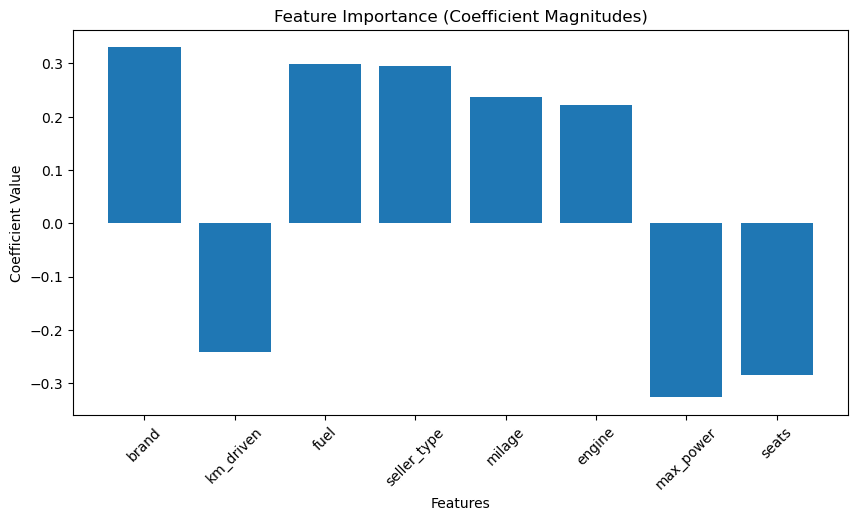

🏃 View run LinearRegression_momentum_0 at: http://localhost:9000/#/experiments/787377846228956947/runs/2b79be339746472faea18cdcded3822b
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Momentum=0 | MSE=0.2706 | R²=-21.5211


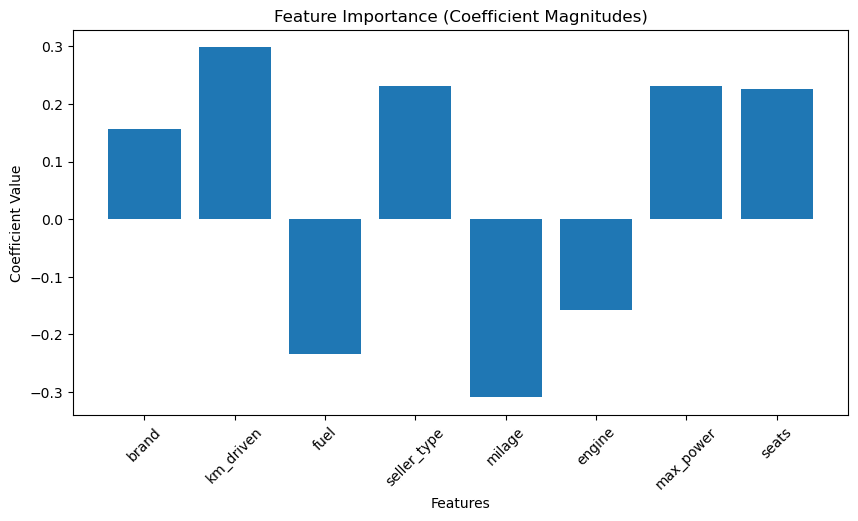

🏃 View run LinearRegression_momentum_0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/50ca549f3d5941289671d43bca5a6c77
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Momentum=0.9 | MSE=0.1204 | R²=-8.7721


In [291]:
# === RUN EXPERIMENTS: MOMENTUM ONLY ===
results = []

for momentum in momentums:
    model_name = f"LinearRegression_momentum_{momentum}"
    
    params = {
        "lr": lr,  # use the defined variable lr
        "method": method,  # use the defined variable method
        "num_epochs": 10,  # set your desired number of epochs
        "bs": 50,           # set your desired batch size
        "init": init,       # use the defined variable init
        "momentum": momentum,
        "feature_names": feature_names  # use the defined list
    }

    try:
        model = LinearRegression(**params)
        model.fit(X_train, y_train)

        mse_scores = model.kfold_scores
        r2_scores = model.kfold_r2_scores

        with mlflow.start_run(run_name=model_name):
            mlflow.log_params(params)
            mlflow.log_metric("mean_mse", np.mean(mse_scores))
            mlflow.log_metric("mean_r2", np.mean(r2_scores))
            
            for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                mlflow.log_metric(f"fold{i+1}_mse", mse)
                mlflow.log_metric(f"fold{i+1}_r2", r2)

            # Optional: log feature importance plot
            model.plot_feature_importance()
            plt.title(f"Feature Importance: {model_name}")
            plt.tight_layout()
            plt.savefig(f"{model_name}_importance.png")
            mlflow.log_artifact(f"{model_name}_importance.png")
            plt.close()

        results.append({
            "Model": "LinearRegression",
            "Momentum": momentum,
            "Mean_MSE": np.mean(mse_scores),
            "Mean_R2": np.mean(r2_scores)
        })

        print(f"✅ Logged: Momentum={momentum} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

    except Exception as e:
        print(f"❌ Failed for momentum={momentum}: {e}")

In [292]:
# === SUMMARY ===
if results:
    results_df = pd.DataFrame(results)
    print("\n🏆 MOMENTUM TEST RESULTS:")
    print(results_df.to_string(index=False))


🏆 MOMENTUM TEST RESULTS:
           Model  Momentum  Mean_MSE    Mean_R2
LinearRegression       0.0  0.270568 -21.521088
LinearRegression       0.9  0.120393  -8.772119


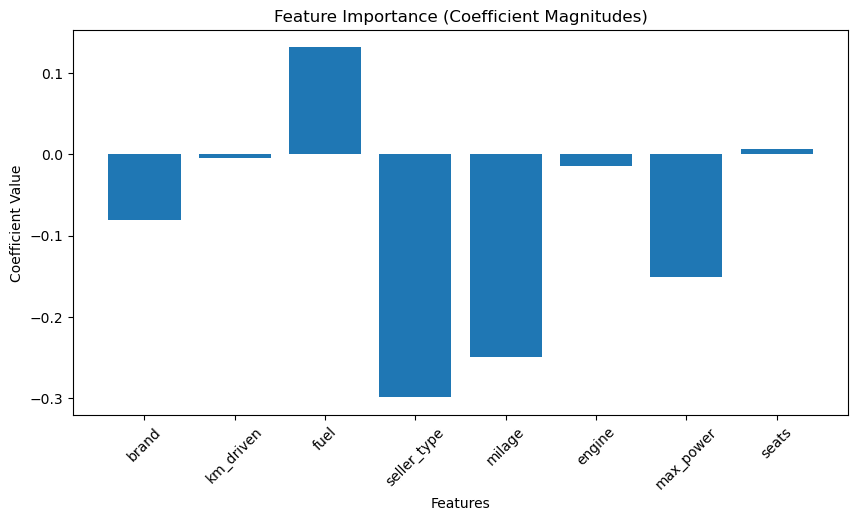

🏃 View run LinearRegression_method_stochastic at: http://localhost:9000/#/experiments/787377846228956947/runs/12ecc2aa370445e6911ecc154dc1ed2c
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Method=stochastic | BatchSize=  1 | MSE=0.1430 | R²=-11.0380


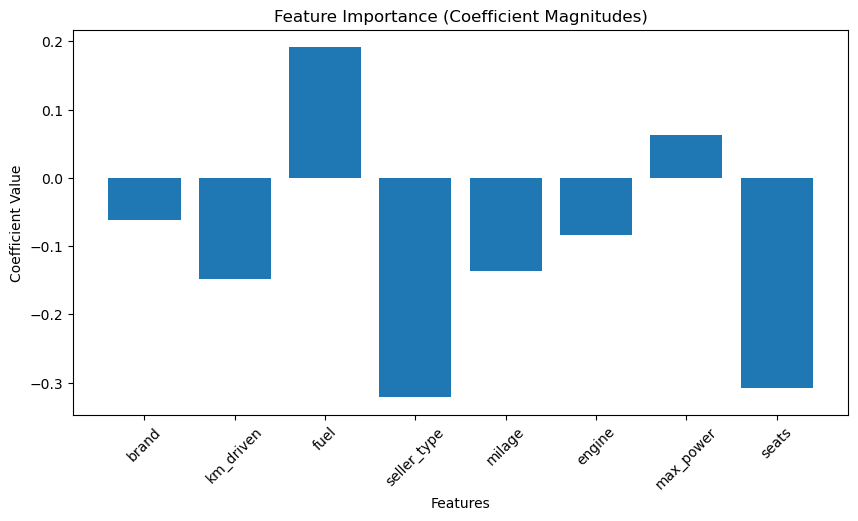

🏃 View run LinearRegression_method_mini at: http://localhost:9000/#/experiments/787377846228956947/runs/ff3bfe61fec844e49fd09de845fe4d35
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Method=mini       | BatchSize= 50 | MSE=0.2111 | R²=-16.2290


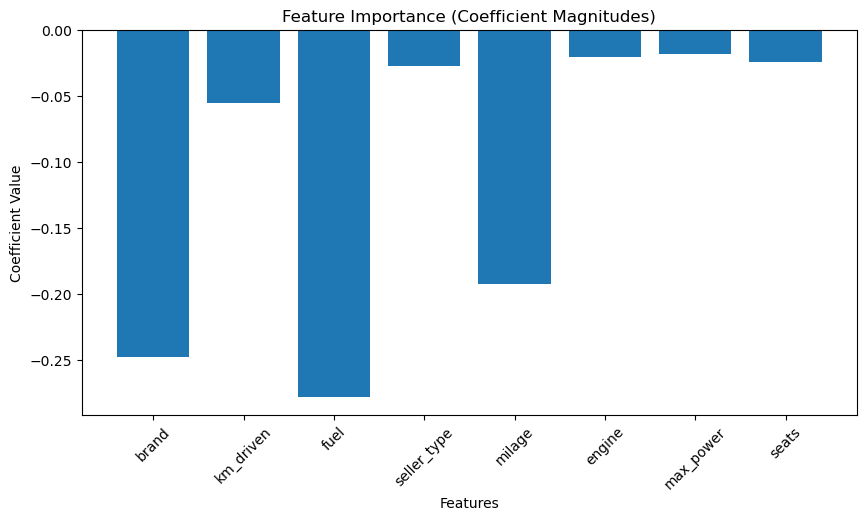

🏃 View run LinearRegression_method_batch at: http://localhost:9000/#/experiments/787377846228956947/runs/554f006c9105413695c521e4f40f0f39
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Method=batch      | BatchSize=5619 | MSE=0.0974 | R²=-6.8959

💾 Results saved to 'gd_method_test_results.csv'


In [293]:
METHODS = ["stochastic", "mini", "batch"]
LR = 0.001
NUM_EPOCHS = 10
BS = 50
INIT = "xavier"
MOMENTUM = 0.0
FEATURE_NAMES = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']

results = []

for method in METHODS:
    model_name = f"LinearRegression_method_{method}"
    
    if method == "batch":
        bs = len(X_train)
    elif method == "stochastic":
        bs = 1
    else:  # mini
        bs = BS

    params = {
        "lr": LR,
        "method": method,
        "num_epochs": NUM_EPOCHS,
        "bs": bs,
        "init": INIT,
        "momentum": MOMENTUM,
        "feature_names": FEATURE_NAMES
    }

    try:
        model = LinearRegression(**params)
        model.fit(X_train, y_train)

        mse_scores = model.kfold_scores
        r2_scores = model.kfold_r2_scores

        with mlflow.start_run(run_name=model_name):
            mlflow.log_params(params)
            mlflow.log_metric("mean_mse", np.mean(mse_scores))
            mlflow.log_metric("mean_r2", np.mean(r2_scores))
            
            for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                mlflow.log_metric(f"fold{i+1}_mse", mse)
                mlflow.log_metric(f"fold{i+1}_r2", r2)

            model.plot_feature_importance()
            plt.title(f"Feature Importance: {model_name}")
            plt.tight_layout()
            plt.savefig(f"{model_name}_importance.png")
            mlflow.log_artifact(f"{model_name}_importance.png")
            plt.close()

        results.append({
            "Method": method,
            "BatchSize": bs,
            "Mean_MSE": np.mean(mse_scores),
            "Mean_R2": np.mean(r2_scores)
        })

        print(f"✅ Logged: Method={method:10} | BatchSize={bs:3} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

    except Exception as e:
        print(f"❌ Failed for method={method}: {e}")

# Save results
if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv("gd_method_test_results.csv", index=False)
    print("\n💾 Results saved to 'gd_method_test_results.csv'")

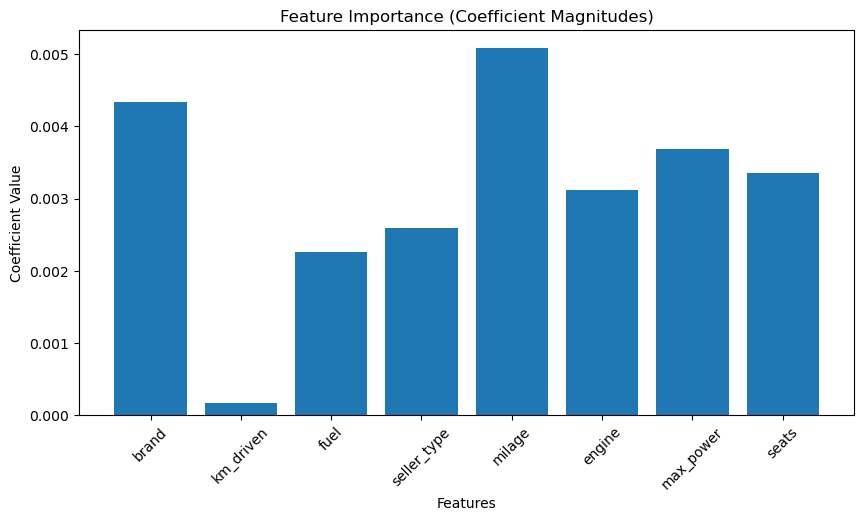

🏃 View run LinearRegression_init_zero at: http://localhost:9000/#/experiments/787377846228956947/runs/21de9ec81fdd4fe7951eb91468170e84
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Init=zero   | MSE=0.0167 | R²=-0.3581


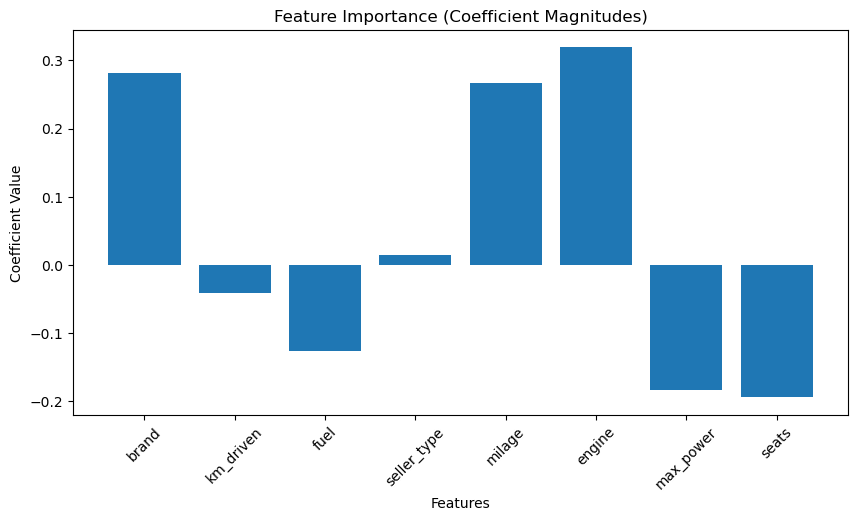

🏃 View run LinearRegression_init_xavier at: http://localhost:9000/#/experiments/787377846228956947/runs/8b2cc74284f840dcb41efae544ae0c11
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: Init=xavier | MSE=0.0588 | R²=-3.6641


In [294]:
INIT_VALUES = ["zero", "xavier"]
METHOD = "mini"
LR = 0.001
NUM_EPOCHS = 100
BS = 50
MOMENTUM = 0.0
FEATURE_NAMES = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']

results = []

for init in INIT_VALUES:
    model_name = f"LinearRegression_init_{init}"
    
    params = {
        "lr": LR,
        "method": METHOD,
        "num_epochs": NUM_EPOCHS,
        "bs": BS,
        "init": init,
        "momentum": MOMENTUM,
        "feature_names": FEATURE_NAMES
    }

    try:
        model = LinearRegression(**params)
        model.fit(X_train, y_train)

        mse_scores = model.kfold_scores
        r2_scores = model.kfold_r2_scores

        with mlflow.start_run(run_name=model_name):
            mlflow.log_params(params)
            mlflow.log_metric("mean_mse", np.mean(mse_scores))
            mlflow.log_metric("mean_r2", np.mean(r2_scores))
            
            for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                mlflow.log_metric(f"fold{i+1}_mse", mse)
                mlflow.log_metric(f"fold{i+1}_r2", r2)

            model.plot_feature_importance()
            plt.title(f"Feature Importance: {model_name}")
            plt.tight_layout()
            plt.savefig(f"{model_name}_importance.png")
            mlflow.log_artifact(f"{model_name}_importance.png")
            plt.close()

        results.append({
            "Init": init,
            "Mean_MSE": np.mean(mse_scores),
            "Mean_R2": np.mean(r2_scores)
        })

        print(f"✅ Logged: Init={init:6} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

    except Exception as e:
        print(f"❌ Failed for init={init}: {e}")




In [295]:
print("\n🏆 INITIALIZATION TEST RESULTS:")
print(results_df.to_string(index=False))



🏆 INITIALIZATION TEST RESULTS:
    Method  BatchSize  Mean_MSE    Mean_R2
stochastic          1  0.143001 -11.037979
      mini         50  0.211131 -16.229003
     batch       5619  0.097355  -6.895889


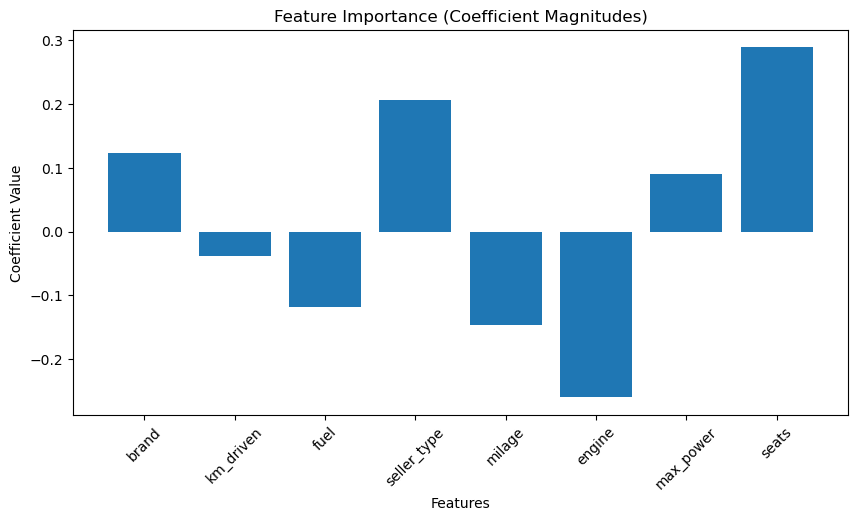

🏃 View run LinearRegression_lr_0.01 at: http://localhost:9000/#/experiments/787377846228956947/runs/c8b1d2d92e86408cb79835fe299c1ad6
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: LR=0.010000 | MSE=0.0230 | R²=-0.8484


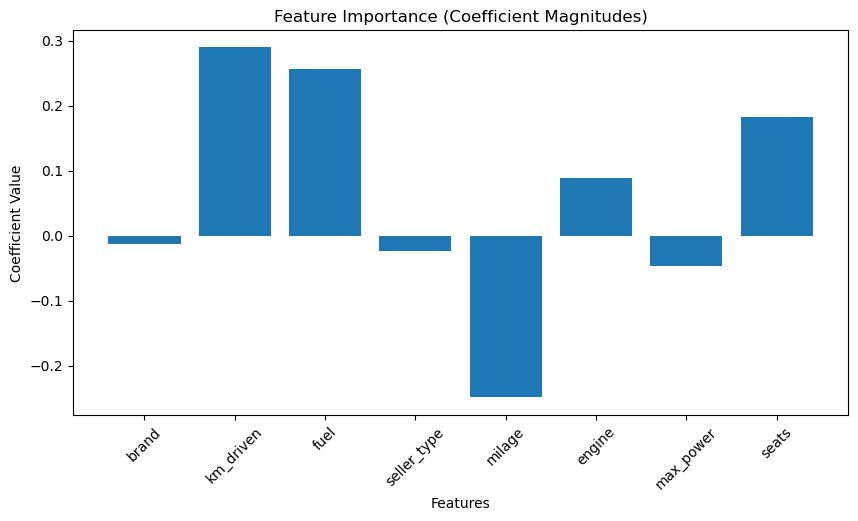

🏃 View run LinearRegression_lr_0.001 at: http://localhost:9000/#/experiments/787377846228956947/runs/d848f79a1b4747ec9329efc144bd5d24
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: LR=0.001000 | MSE=0.0538 | R²=-3.4652


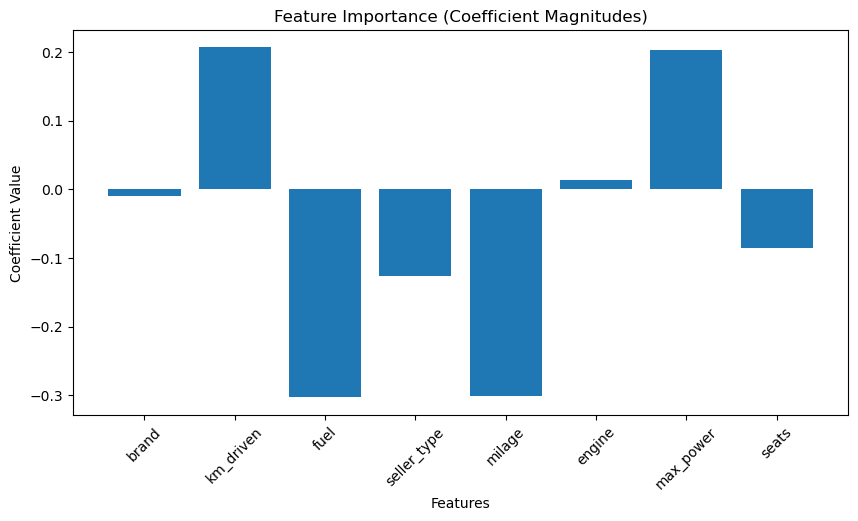

🏃 View run LinearRegression_lr_0.0001 at: http://localhost:9000/#/experiments/787377846228956947/runs/7a9f78e568a24fc5b81114a024e5b06e
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: LR=0.000100 | MSE=0.0808 | R²=-5.7940


In [296]:
LEARNING_RATES = [0.01, 0.001, 0.0001]
METHOD = "mini"
NUM_EPOCHS = 100
BS = 50
INIT = "xavier"
MOMENTUM = 0.0
FEATURE_NAMES = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']

results = []

for lr in LEARNING_RATES:
    model_name = f"LinearRegression_lr_{lr:.6f}".rstrip('0').rstrip('.')
    
    params = {
        "lr": lr,
        "method": METHOD,
        "num_epochs": NUM_EPOCHS,
        "bs": BS,
        "init": INIT,
        "momentum": MOMENTUM,
        "feature_names": FEATURE_NAMES
    }

    try:
        model = LinearRegression(**params)
        model.fit(X_train, y_train)

        mse_scores = model.kfold_scores
        r2_scores = model.kfold_r2_scores

        with mlflow.start_run(run_name=model_name):
            mlflow.log_params(params)
            mlflow.log_metric("mean_mse", np.mean(mse_scores))
            mlflow.log_metric("mean_r2", np.mean(r2_scores))
            
            for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                mlflow.log_metric(f"fold{i+1}_mse", mse)
                mlflow.log_metric(f"fold{i+1}_r2", r2)

            model.plot_feature_importance()
            plt.title(f"Feature Importance: {model_name}")
            plt.tight_layout()
            plt.savefig(f"{model_name}_importance.png")
            mlflow.log_artifact(f"{model_name}_importance.png")
            plt.close()

        results.append({
            "LR": lr,
            "Mean_MSE": np.mean(mse_scores),
            "Mean_R2": np.mean(r2_scores)
        })

        print(f"✅ Logged: LR={lr:.6f} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

    except Exception as e:
        print(f"❌ Failed for LR={lr}: {e}")

In [298]:
# Save results

print("\n🏆 LEARNING RATE TEST RESULTS:")
print(results_df.to_string(index=False))
print("💾 Results saved to 'lr_test_results.csv'")


🏆 LEARNING RATE TEST RESULTS:
    Method  BatchSize  Mean_MSE    Mean_R2
stochastic          1  0.143001 -11.037979
      mini         50  0.211131 -16.229003
     batch       5619  0.097355  -6.895889
💾 Results saved to 'lr_test_results.csv'


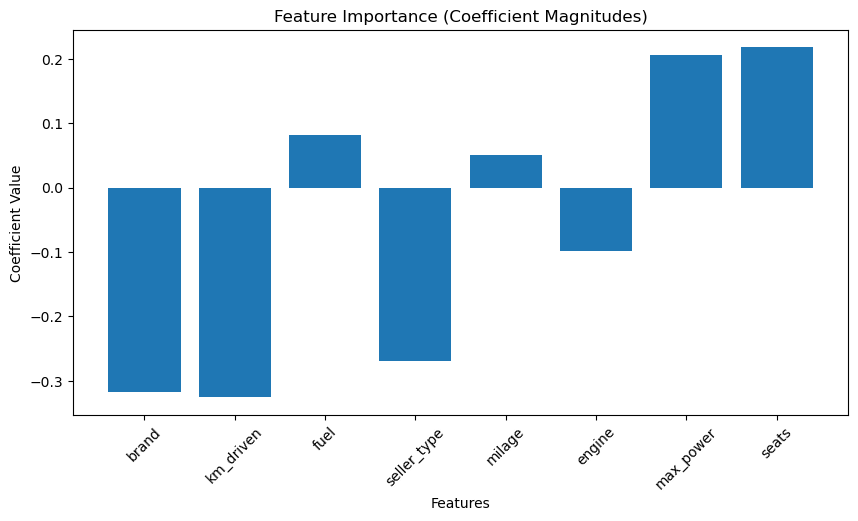

🏃 View run Normal_momentum_0 at: http://localhost:9000/#/experiments/787377846228956947/runs/4f6a227062df4bd191fbe3cbb0422080
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0 | MSE=0.0362 | R²=-1.8957


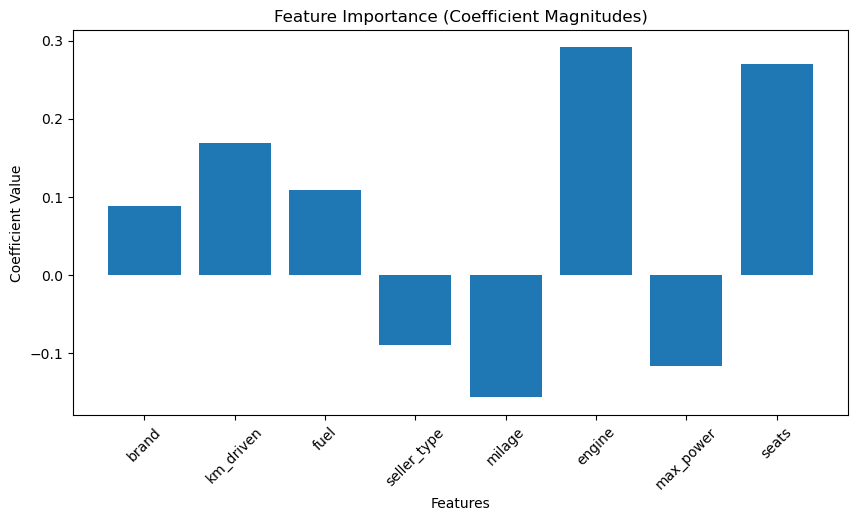

🏃 View run Normal_momentum_0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/27252ca50e5846b0bea1149d8f33a7df
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0.9 | MSE=0.0156 | R²=-0.2610

🏆 POLYNOMIAL, REGULARIZATION & MOMENTUM TEST RESULTS:
    Method  BatchSize  Mean_MSE    Mean_R2
     batch       5619  0.097355  -6.895889
stochastic          1  0.143001 -11.037979
      mini         50  0.211131 -16.229003
💾 Results saved to 'poly_reg_momentum_test_results.csv'
❌ Failed: ridge | Mom=0 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0.9 | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'

🏆 POLYNOMIAL, REGULARIZATION & MOMENTUM TEST RESULTS:
    Method  BatchSize  Mean_MSE    Mean_R2
     batch       5619  0.097355  -6.895889
stochastic          1  0.143001 -11.037979
      mini         50  0.211131 -16.229003
💾 Results saved to

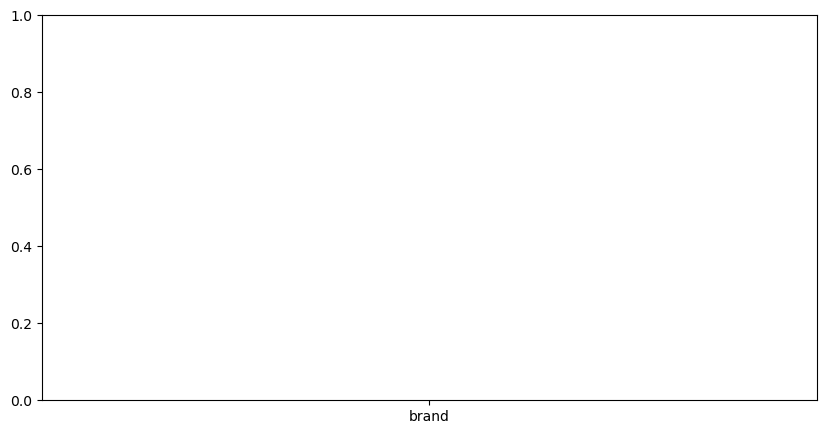

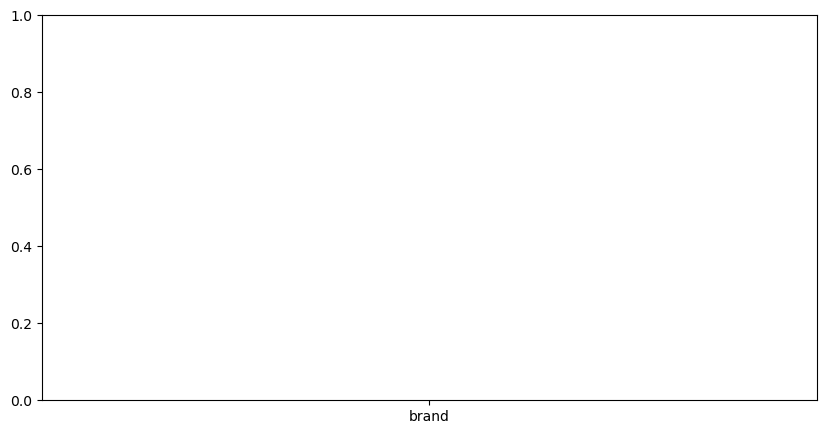

In [299]:
# === CONFIGURATION ===
MODEL_TYPES = ["normal", "ridge", "lasso", "poly"]     # Normal = no reg, poly = +degree=2
MOMENTUM_VALUES = [0, 0.9]
LR = 0.001
NUM_EPOCHS = 500
BS = 50
INIT = "xavier"
FEATURE_NAMES = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']
POLY_DEGREE = 2  # Fixed for polynomial

# === RUN EXPERIMENTS ===
results = []

for model_type in MODEL_TYPES:
    for momentum in MOMENTUM_VALUES:
        if model_type == "normal":
            model_class = LinearRegression
            params = {
                "lr": LR,
                "method": "mini",
                "num_epochs": NUM_EPOCHS,
                "bs": BS,
                "init": INIT,
                "momentum": momentum,
                "feature_names": FEATURE_NAMES
            }
            run_name = f"Normal_momentum_{momentum}"

        elif model_type == "ridge":
            model_class = RidgeRegression
            params = {
                "method": "mini",
                "lr": LR,
                "l": 0.1,  # Regularization strength
                "momentum": momentum
            }
            run_name = f"Ridge_momentum_{momentum}"

        elif model_type == "lasso":
            model_class = LassoRegression
            params = {
                "method": "mini",
                "lr": LR,
                "l": 0.1,  # Regularization strength
                "momentum": momentum
            }
            run_name = f"Lasso_momentum_{momentum}"

        elif model_type == "poly":
            model_class = LinearRegression
            params = {
                "lr": LR,
                "method": "mini",
                "num_epochs": NUM_EPOCHS,
                "bs": BS,
                "init": INIT,
                "momentum": momentum,
                "feature_names": FEATURE_NAMES
            }
            run_name = f"Poly_momentum_{momentum}"

        try:
            # Apply polynomial features only for "poly"
            X_use = X_train
            feature_names_use = FEATURE_NAMES
            if model_type == "poly":
                poly = PolynomialFeatures(degree=POLY_DEGREE)
                X_use = poly.fit_transform(X_train)
                # Generate polynomial feature names
                from itertools import combinations_with_replacement
                names = list(FEATURE_NAMES)
                new_names = names.copy()
                for i in range(2, POLY_DEGREE + 1):
                    for combo in combinations_with_replacement(names, i):
                        new_names.append("*".join(combo))
                feature_names_use = new_names
                params["feature_names"] = feature_names_use

            model = model_class(**params)
            model.fit(X_use, y_train)

            mse_scores = model.kfold_scores
            r2_scores = model.kfold_r2_scores

            with mlflow.start_run(run_name=run_name):
                mlflow.log_param("model_type", model_type)
                mlflow.log_param("momentum", momentum)
                mlflow.log_params(params)
                mlflow.log_metric("mean_mse", np.mean(mse_scores))
                mlflow.log_metric("mean_r2", np.mean(r2_scores))

                for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                    mlflow.log_metric(f"fold{i+1}_mse", mse)
                    mlflow.log_metric(f"fold{i+1}_r2", r2)

                # Log feature importance if available
                if hasattr(model, 'plot_feature_importance'):
                    model.plot_feature_importance()
                    plt.title(f"Feature Importance: {run_name}")
                    plt.tight_layout()
                    plt.savefig(f"{run_name}_importance.png")
                    mlflow.log_artifact(f"{run_name}_importance.png")
                    plt.close()

            results.append({
                "Model": model_type,
                "Momentum": momentum,
                "Mean_MSE": np.mean(mse_scores),
                "Mean_R2": np.mean(r2_scores)
            })

            print(f"✅ Logged: {model_type:6} | Mom={momentum} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

        except Exception as e:
            print(f"❌ Failed: {model_type} | Mom={momentum} | Error: {e}")

# # === SAVE RESULTS ===
# if results:
#     results_df = pd.DataFrame(results)
#     results_df.to_csv("poly_reg_momentum_test_results.csv", index=False)
    print("\n🏆 POLYNOMIAL, REGULARIZATION & MOMENTUM TEST RESULTS:")
    print(results_df.sort_values("Mean_R2", ascending=False).to_string(index=False))
    print("💾 Results saved to 'poly_reg_momentum_test_results.csv'")

In [300]:
print("\n🏆 POLYNOMIAL, REGULARIZATION & MOMENTUM TEST RESULTS:")
print(results_df.sort_values("Mean_R2", ascending=False).to_string(index=False))


🏆 POLYNOMIAL, REGULARIZATION & MOMENTUM TEST RESULTS:
    Method  BatchSize  Mean_MSE    Mean_R2
     batch       5619  0.097355  -6.895889
stochastic          1  0.143001 -11.037979
      mini         50  0.211131 -16.229003


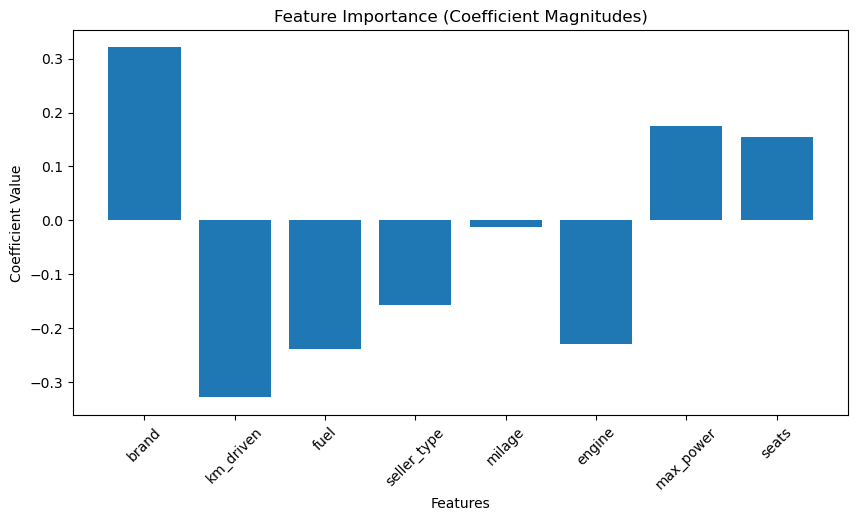

🏃 View run Normal_stochastic_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/ba26723edcb54af5aef37e9ca8aa7bc9
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0 | Method=stochastic | BS=  1 | MSE=0.0473 | R²=-2.7473


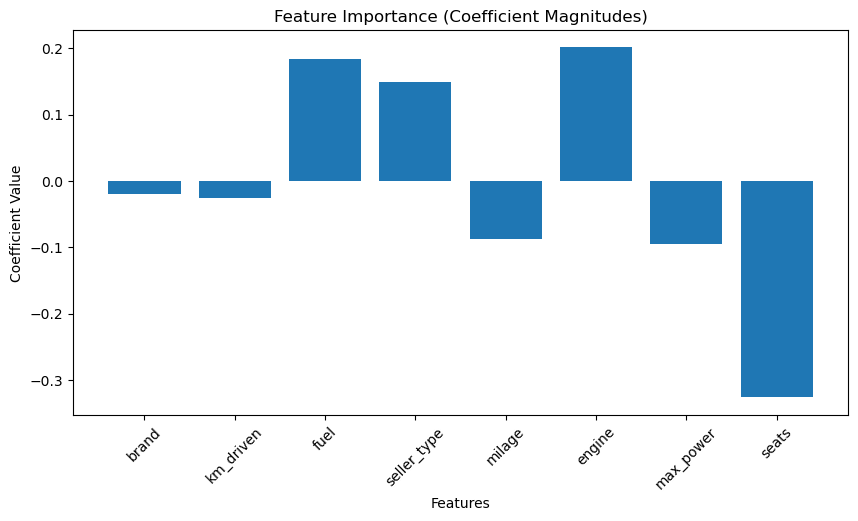

🏃 View run Normal_mini_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/d73d04afd50842ef8e8793a44dddaf04
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0 | Method=mini     | BS= 50 | MSE=0.0581 | R²=-3.5076


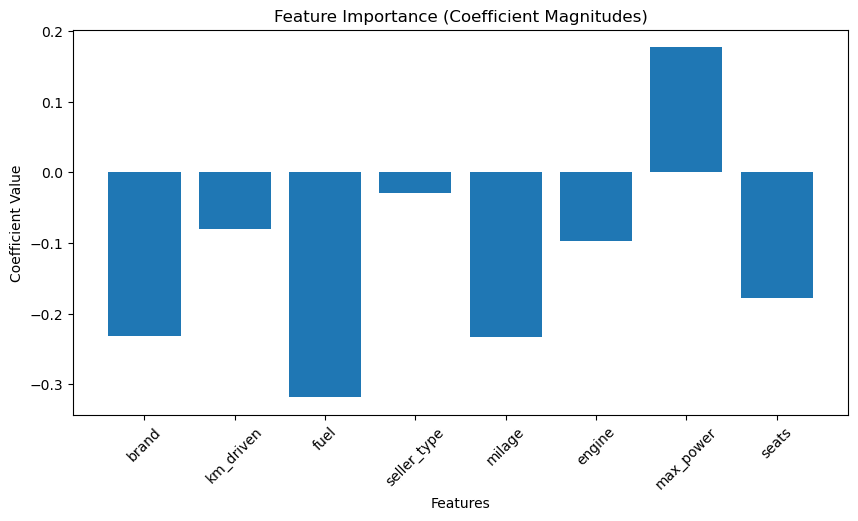

🏃 View run Normal_batch_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/b0a3cf1fcad9442d88d5f9e4cc74c0cd
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0 | Method=batch    | BS=5619 | MSE=0.1058 | R²=-7.8247


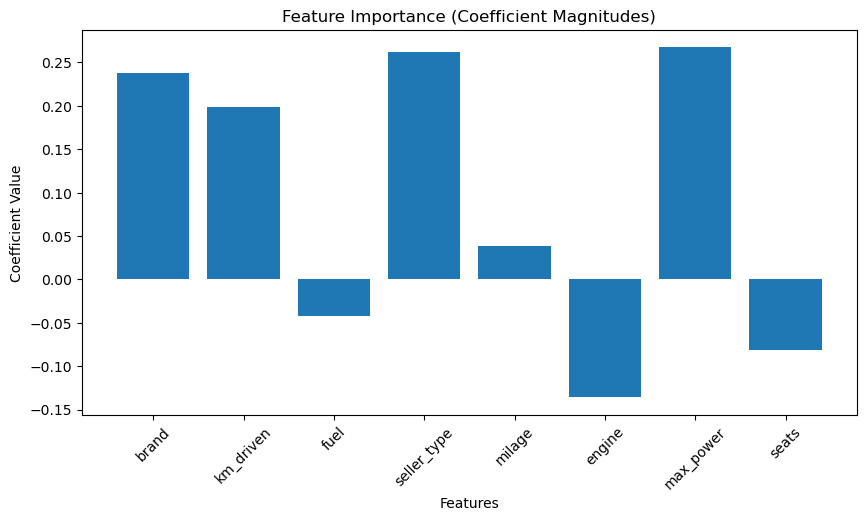

🏃 View run Normal_stochastic_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/6ba5f804145d44ef97f3cbba33318471
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0.9 | Method=stochastic | BS=  1 | MSE=0.0335 | R²=-1.7153


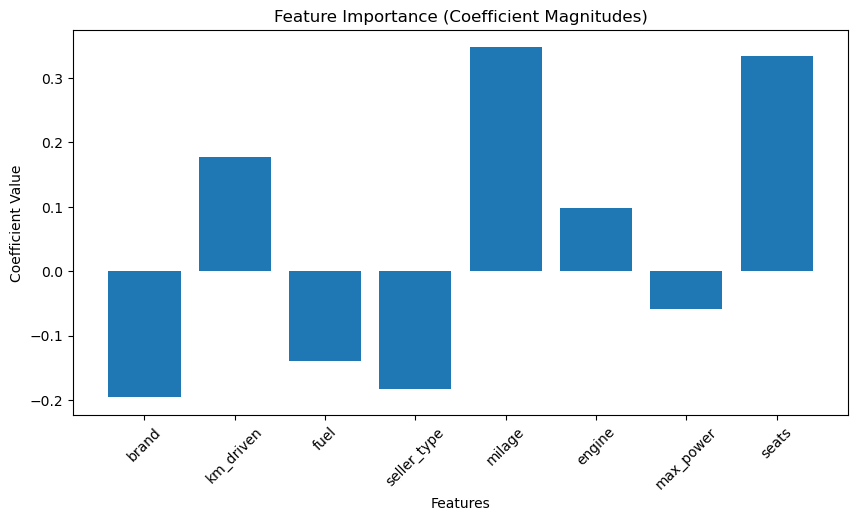

🏃 View run Normal_mini_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/493eb5dbf20f441eada263707346aabf
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0.9 | Method=mini     | BS= 50 | MSE=0.0250 | R²=-1.0462


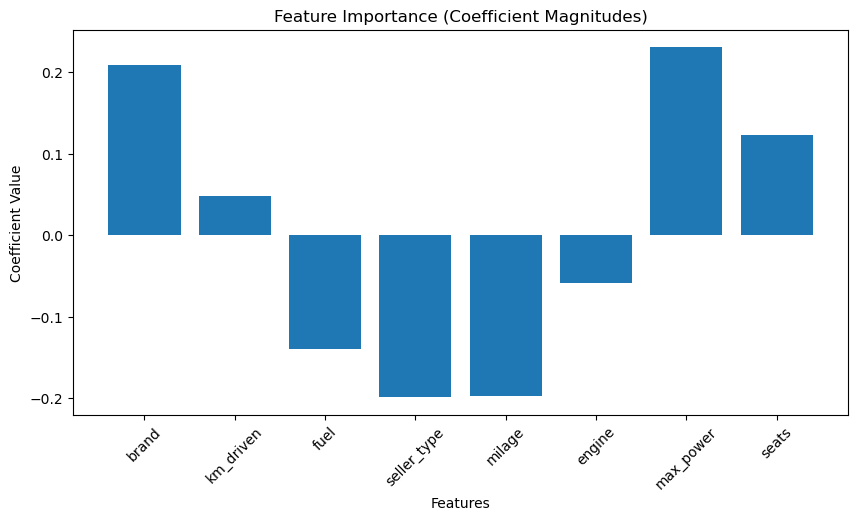

🏃 View run Normal_batch_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/b8eb7dbd7cd746e3bc29c170f5832fb7
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: normal | Mom=0.9 | Method=batch    | BS=5619 | MSE=0.0381 | R²=-2.1196
❌ Failed: ridge | Mom=0 | Method=stochastic | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0 | Method=mini | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0 | Method=batch | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0.9 | Method=stochastic | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0.9 | Method=mini | Error: RidgeRegression.__init__() got an unexpected keyword argument 'momentum'
❌ Failed: ridge | Mom=0.9 | Method=batch | Error: RidgeRegression.__init__() got an unexpected ke

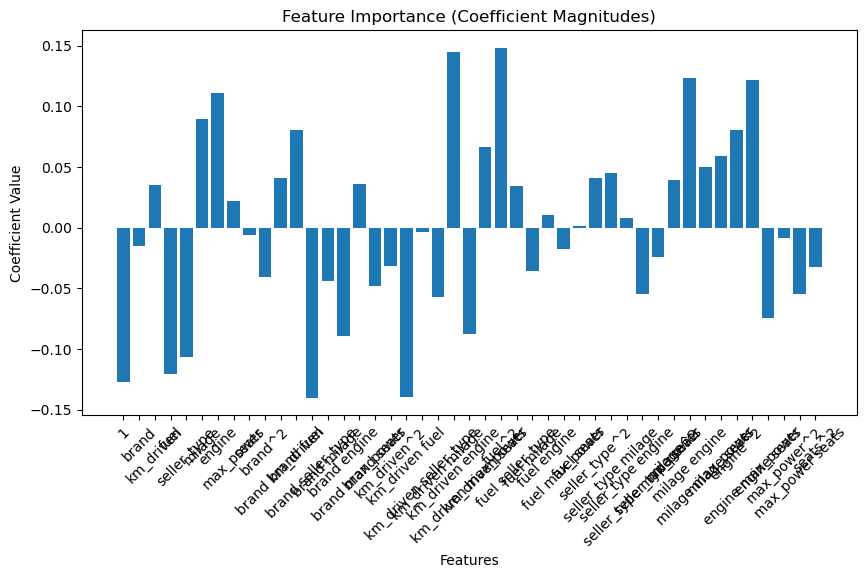

🏃 View run Poly_stochastic_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/b6eaa07c0f8649079436056133040931
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0 | Method=stochastic | BS=  1 | MSE=0.0532 | R²=-3.4245


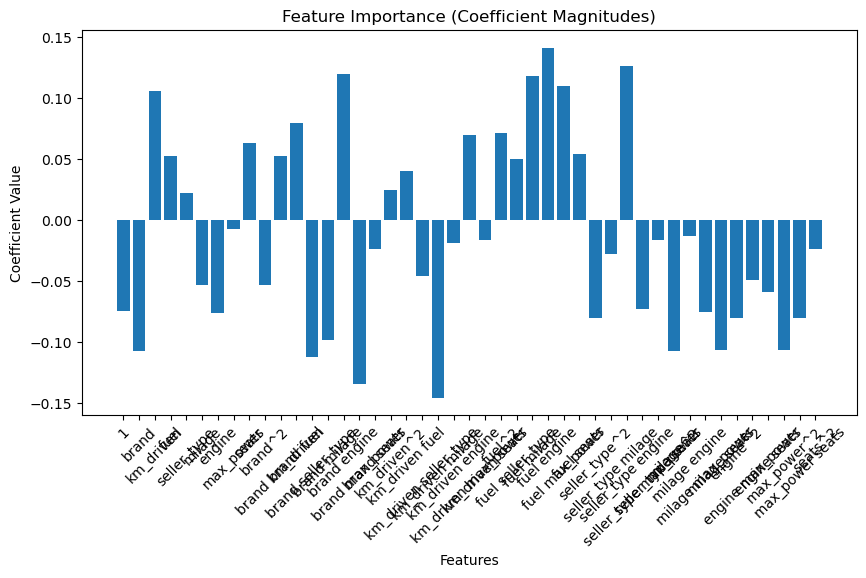

🏃 View run Poly_mini_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/2631b4481de54339bdd774c37eb85e95
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0 | Method=mini     | BS= 50 | MSE=0.0831 | R²=-5.9758


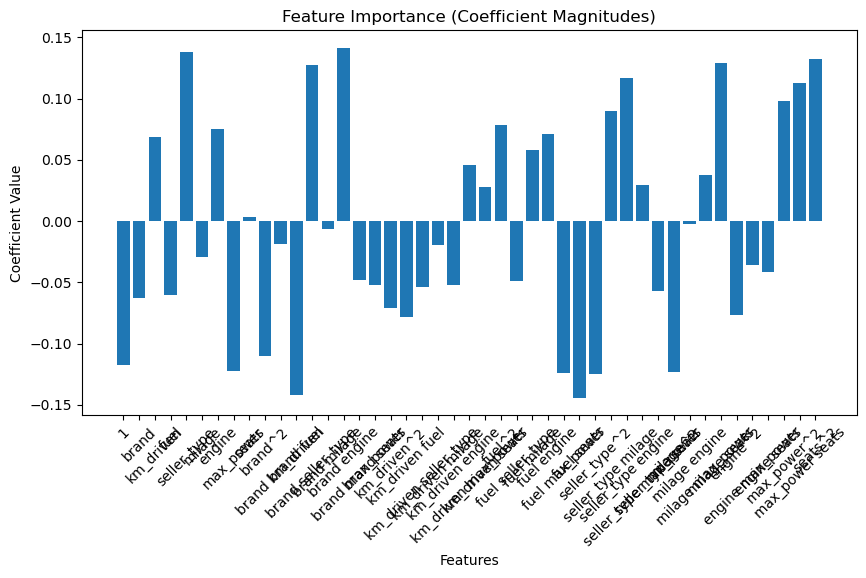

🏃 View run Poly_batch_mom0 at: http://localhost:9000/#/experiments/787377846228956947/runs/7aa3decd919c496db8db1a796614771e
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0 | Method=batch    | BS=5619 | MSE=0.0384 | R²=-2.1440


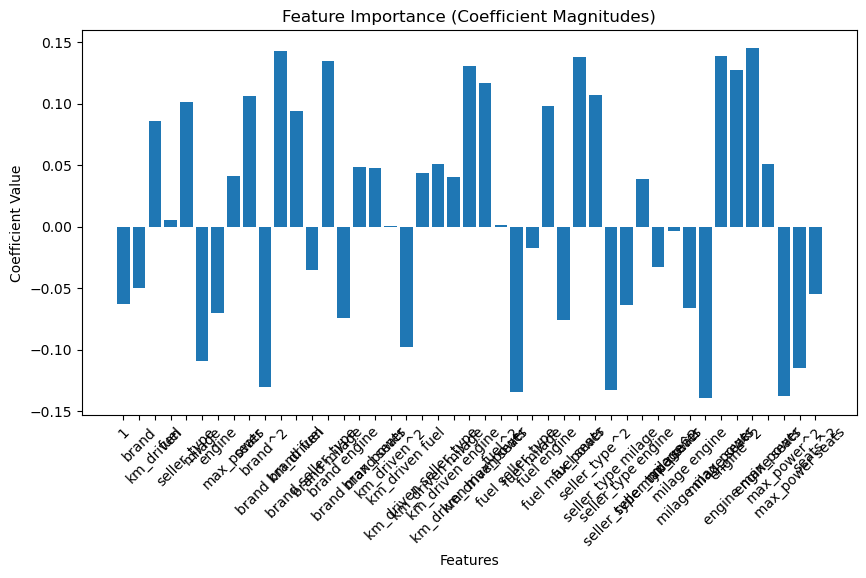

🏃 View run Poly_stochastic_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/d64fe78771f0484b81b57b9e36ce1272
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0.9 | Method=stochastic | BS=  1 | MSE=0.0188 | R²=-0.5348


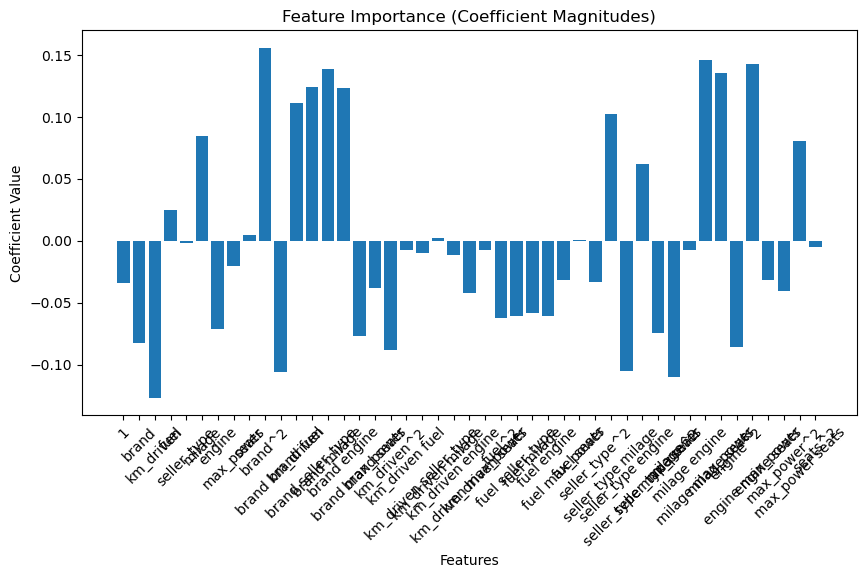

🏃 View run Poly_mini_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/d182e3251684440886de6e673f02c184
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0.9 | Method=mini     | BS= 50 | MSE=0.0240 | R²=-0.9924


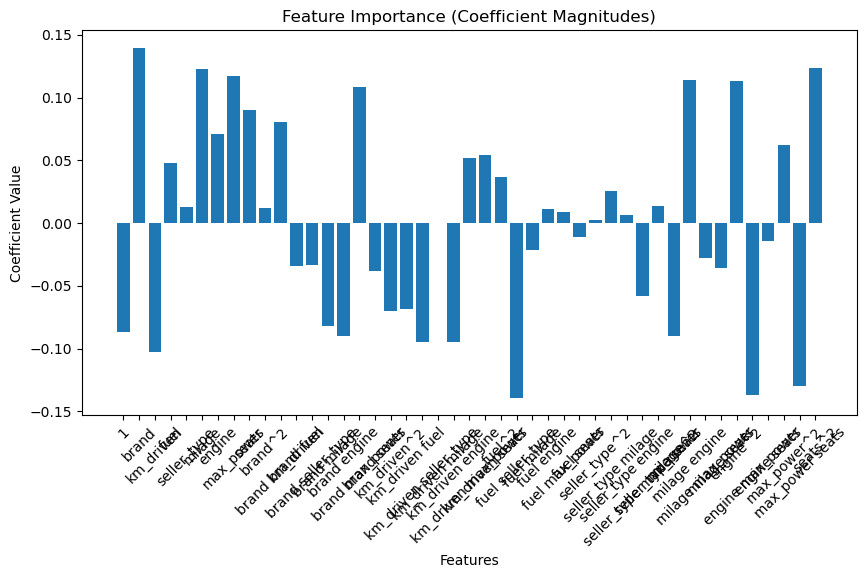

🏃 View run Poly_batch_mom0.9 at: http://localhost:9000/#/experiments/787377846228956947/runs/656c7738288e4691b4522da74c81a86b
🧪 View experiment at: http://localhost:9000/#/experiments/787377846228956947
✅ Logged: poly   | Mom=0.9 | Method=batch    | BS=5619 | MSE=0.0156 | R²=-0.2679


In [ ]:
# === CONFIGURATION ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import mlflow

# Make sure your custom model classes are imported or defined above this cell:
# from your_module import LinearRegression, RidgeRegression, LassoRegression

MODEL_TYPES = ["normal", "ridge", "lasso", "poly"]
MOMENTUM_VALUES = [0, 0.9]
METHODS = ["stochastic", "mini", "batch"]
LR = 0.001
NUM_EPOCHS = 500
BASE_BS = 50  # used for mini-batch
INIT = "xavier"
FEATURE_NAMES = ['brand', 'km_driven', 'fuel', 'seller_type', 'milage', 'engine', 'max_power', 'seats']
POLY_DEGREE = 2

# Ensure y_train is aligned with X_train after preprocessing
# IMPORTANT: If you scaled y_train earlier, make sure it's still the same length as X_train
assert len(X_train) == len(y_train), f"Shape mismatch: X_train={len(X_train)}, y_train={len(y_train)}"

results = []

for model_type in MODEL_TYPES:
    for momentum in MOMENTUM_VALUES:
        for method in METHODS:
            # Determine batch size based on method
            if method == "batch":
                bs = len(X_train)
            elif method == "stochastic":
                bs = 1
            else:  # mini
                bs = BASE_BS

            # Set up model class and parameters
            if model_type == "normal":
                model_class = LinearRegression
                params = {
                    "lr": LR,
                    "method": method,
                    "num_epochs": NUM_EPOCHS,
                    "bs": bs,
                    "init": INIT,
                    "momentum": momentum,
                    "feature_names": FEATURE_NAMES
                }
                run_name = f"Normal_{method}_mom{momentum}"

            elif model_type == "ridge":
                model_class = RidgeRegression
                params = {
                    "method": method,
                    "lr": LR,
                    "l": 0.1  # Use 'l' as per your class definition
                }
                run_name = f"Ridge_{method}_mom{momentum}"

            elif model_type == "lasso":
                model_class = LassoRegression
                params = {
                    "method": method,
                    "lr": LR,
                    "l": 0.1  # Use 'l' as per your class definition
                }
                run_name = f"Lasso_{method}_mom{momentum}"

            elif model_type == "poly":
                model_class = LinearRegression
                params = {
                    "lr": LR,
                    "method": method,
                    "num_epochs": NUM_EPOCHS,
                    "bs": bs,
                    "init": INIT,
                    "momentum": momentum,
                    "feature_names": FEATURE_NAMES
                }
                run_name = f"Poly_{method}_mom{momentum}"

            try:
                X_use = X_train
                feature_names_use = FEATURE_NAMES

                # Apply polynomial features if needed
                if model_type == "poly":
                    poly = PolynomialFeatures(degree=POLY_DEGREE)
                    X_use = poly.fit_transform(X_train)
                    feature_names_use = poly.get_feature_names_out(FEATURE_NAMES)
                    params["feature_names"] = feature_names_use

                model = model_class(**params)
                # For Ridge/Lasso, set momentum after initialization if needed
                if model_type in ["ridge", "lasso"]:
                    if hasattr(model, 'momentum'):
                        model.momentum = momentum
                model.fit(X_use, y_train)

                mse_scores = getattr(model, "kfold_scores", None)
                r2_scores = getattr(model, "kfold_r2_scores", None)

                if mse_scores is None or r2_scores is None:
                    raise AttributeError("Model must have 'kfold_scores' and 'kfold_r2_scores' attributes after fitting.")

                with mlflow.start_run(run_name=run_name):
                    mlflow.log_param("model_type", model_type)
                    mlflow.log_param("momentum", momentum)
                    mlflow.log_param("method", method)
                    mlflow.log_param("batch_size", bs)
                    mlflow.log_params(params)
                    mlflow.log_metric("mean_mse", np.mean(mse_scores))
                    mlflow.log_metric("mean_r2", np.mean(r2_scores))

                    for i, (mse, r2) in enumerate(zip(mse_scores, r2_scores)):
                        mlflow.log_metric(f"fold{i+1}_mse", mse)
                        mlflow.log_metric(f"fold{i+1}_r2", r2)

                    # Log feature importance if available
                    if hasattr(model, 'plot_feature_importance'):
                        model.plot_feature_importance()
                        plt.title(f"Feature Importance: {run_name}")
                        plt.tight_layout()
                        plt.savefig(f"{run_name}_importance.png")
                        mlflow.log_artifact(f"{run_name}_importance.png")
                        plt.close()

                results.append({
                    "Model": model_type,
                    "Momentum": momentum,
                    "Method": method,
                    "BatchSize": bs,
                    "Mean_MSE": np.mean(mse_scores),
                    "Mean_R2": np.mean(r2_scores)
                })

                print(f"✅ Logged: {model_type:6} | Mom={momentum} | Method={method:8} | BS={bs:3} | MSE={np.mean(mse_scores):.4f} | R²={np.mean(r2_scores):.4f}")

            except Exception as e:
                print(f"❌ Failed: {model_type} | Mom={momentum} | Method={method} | Error: {e}")

# === SAVE AND DISPLAY RESULTS ===
if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv("full_experiment_results.csv", index=False)
    print("\n🏆 FULL EXPERIMENT RESULTS (Top 10 by R²):")
    print(results_df.sort_values("Mean_R2", ascending=False).head(10).to_string(index=False))
    print("\n💾 Results saved to 'full_experiment_results.csv'")
else:
    print("⚠️ No experiments completed. Check for errors above.")


In [306]:
print("\n🏆 FULL EXPERIMENT RESULTS (Top 10 by R²):")
print(results_df.sort_values("Mean_R2", ascending=False).head(10).to_string(index=False))


🏆 FULL EXPERIMENT RESULTS (Top 10 by R²):
 Model  Momentum     Method  BatchSize  Mean_MSE   Mean_R2
 ridge       0.9      batch       5619  0.010912  0.115485
 ridge       0.9       mini         50  0.010916  0.114954
 ridge       0.9 stochastic          1  0.010997  0.108185
normal       0.9      batch       5619  0.011468  0.068059
 ridge       0.0 stochastic          1  0.012776 -0.035636
 ridge       0.0      batch       5619  0.012979 -0.052348
 ridge       0.0       mini         50  0.012991 -0.053348
normal       0.9 stochastic          1  0.013058 -0.057051
normal       0.9       mini         50  0.014899 -0.215921
 lasso       0.9 stochastic          1  0.019074 -0.550204
